# Online EV-Only MPC 1 – Access Power, Simulation & Comparison

This notebook matches **Chapter 3** of the thesis (methodology): **§3.7.1** (monthly access before online operation), **§3.7.2** (EV-only online MPC), plus links to **§3.5** (offline deterministic exports from notebook 02), **§3.6** (rolling forecasts from notebooks 05–07), and **§3.3** (billing).

It is structured in **five parts**:

1. **Monthly access power (§1.1–§1.3)**
   - **§1.2 (grid-based):** **conservative** access = cum-max `grid_consumption` (M−1) + 20 kW — same rule as notebook 02 baseline; **flex-aware** access = cum-max `grid_consumption_excl_ev` (M−1) + 20 kW — used for online MPC and online billing.
   - **§1.3 (no-PV):** same cum-max rules on `grid + pv − injection` counterfactual peaks (validation plots; not wired into Part 2 by default).
   - Headroom checks (§1.2 / §1.3): daily playroom = chosen access minus baseline load in the EV window (weekdays 07:00–17:00); §1.2 uses `grid_consumption_excl_ev`.

2. **Rolling-horizon online MPC (Part 2, §3.7.2)** — `run_ev_online_mpc_1` with `ACCESS_POWER_ONLINE_MONTHLY` = §1.2 **flex-aware** access.

3. **Visualisation and comparison (Part 3)** — EV/grid profiles and **shadow billing**: baseline access labels from §1.2 **conservative**; online access labels from §1.2 **flex-aware** (online energy costs from Part 2 bills).

4. **Slack sensitivity (Part 4)** — deadline slack sweep; online runs use flex-aware access; Part 4.4 baseline re-billing uses §1.2 conservative access.

5. **Planner-only online MPC (Part 5, §3.7.2 steps 0–2 & 6)** — same forecasts and `mpc_ev_24h` as Part 2, but **no** clipping, catch-up, deadline slack, or daily enforce; shadow billing vs baseline and offline deterministic.

## 1. Monthly access power (thesis §3.7.1)


### 1.1 Grid consumption profiles and headroom intuition

We inspect **Plant 1** grid consumption with and without EV for **figures and intuition only** (this section does not set the Part 2 access contract).

- Time-series plots of `grid_consumption` and `grid_consumption_excl_ev` (kW)
- Their **maximum values** over 2025
- **Load duration curves** (sorted descending power) for both series
- Overlay of **benchmark reference** access powers from notebook 01 (no EV vs with EV) — illustrative only

**§1.2** defines the access series used downstream: conservative (grid peaks) and flex-aware (grid excl. EV peaks). Headroom validation in §1.2 uses `grid_consumption_excl_ev` as the baseline load in the EV window (weekdays 07:00–17:00), not `inflex_load`.


In [8]:
# Load Plant 1 data (2025) and compute grid consumption with/without EV
# Define imports and paths locally so this cell runs independently.
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
plant_path = DATA_DIR / "plant1.csv"

plant = pd.read_csv(plant_path)

# Parse timestamps as naive local (same convention as forecasting notebooks)
plant["timestamp"] = pd.to_datetime(plant["timestamp"], utc=True, errors="coerce")
plant["timestamp"] = plant["timestamp"].dt.tz_convert("Europe/Brussels").dt.tz_localize(None)

# Ensure numeric
for col in ["grid_consumption", "grid_consumption_excl_ev"]:
    plant[col] = pd.to_numeric(plant[col], errors="coerce")

plant = plant.sort_values("timestamp").reset_index(drop=True)

# kWh per 15-min → kW
plant["grid_consumption_kw"] = plant["grid_consumption"] * 4.0
plant["grid_consumption_excl_ev_kw"] = plant["grid_consumption_excl_ev"] * 4.0

max_gc_kw = plant["grid_consumption_kw"].max()
max_gc_excl_kw = plant["grid_consumption_excl_ev_kw"].max()

print(f"Max grid_consumption (with EV)      : {max_gc_kw:.3f} kW")
print(f"Max grid_consumption_excl_ev (no EV): {max_gc_excl_kw:.3f} kW")

Max grid_consumption (with EV)      : 2821.000 kW
Max grid_consumption_excl_ev (no EV): 2629.500 kW


In [2]:
# Load deterministic EV MPC exports from notebook 02

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
NOTEBOOKS_OUTPUT_DIR = PROJECT_ROOT / "output" / "notebooks"

DET_EV_MONTHLY = pd.read_csv(
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_monthly_notebook_02.csv"
)
# Ensure month is a PeriodIndex so .to_timestamp() works
if "month" in DET_EV_MONTHLY.columns:
    DET_EV_MONTHLY["month"] = pd.PeriodIndex(DET_EV_MONTHLY["month"], freq="M")

DET_EV_15MIN = pd.read_csv(
    NOTEBOOKS_OUTPUT_DIR / "deterministic_ev_15min_notebook_02.csv"
)

# Parse timestamp column in 15-min export if present
if "timestamp" in DET_EV_15MIN.columns:
    DET_EV_15MIN["timestamp"] = pd.to_datetime(DET_EV_15MIN["timestamp"])


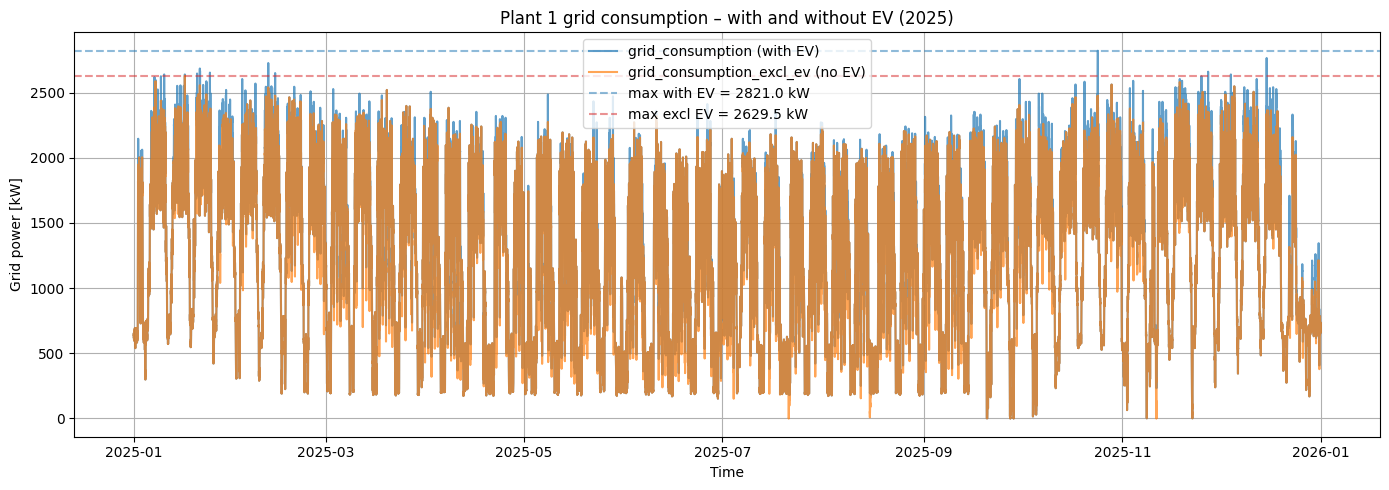

In [3]:
# Time-series plot of grid consumption (with and without EV)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plant["timestamp"], plant["grid_consumption_kw"], label="grid_consumption (with EV)", alpha=0.7)
ax.plot(plant["timestamp"], plant["grid_consumption_excl_ev_kw"], label="grid_consumption_excl_ev (no EV)", alpha=0.7)

# Highlight maxima
ax.axhline(max_gc_kw, color="tab:blue", linestyle="--", alpha=0.5,
           label=f"max with EV = {max_gc_kw:.1f} kW")
ax.axhline(max_gc_excl_kw, color="tab:red", linestyle="--", alpha=0.5,
           label=f"max excl EV = {max_gc_excl_kw:.1f} kW")

ax.set_title("Plant 1 grid consumption – with and without EV (2025)")
ax.set_xlabel("Time")
ax.set_ylabel("Grid power [kW]")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

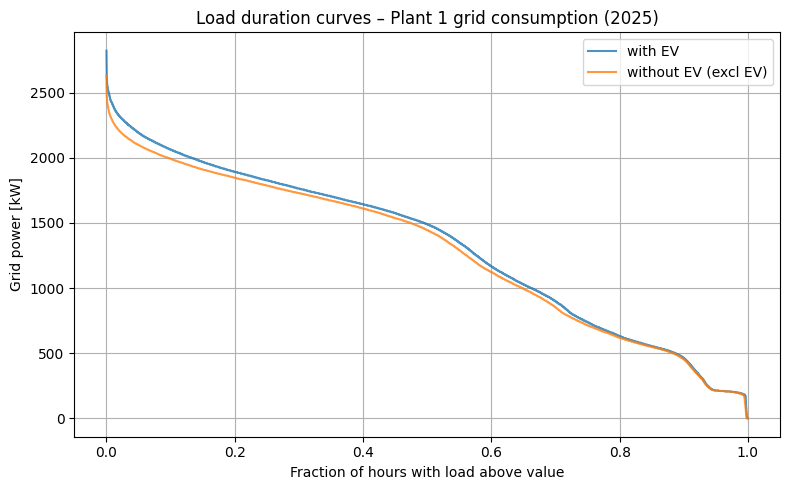

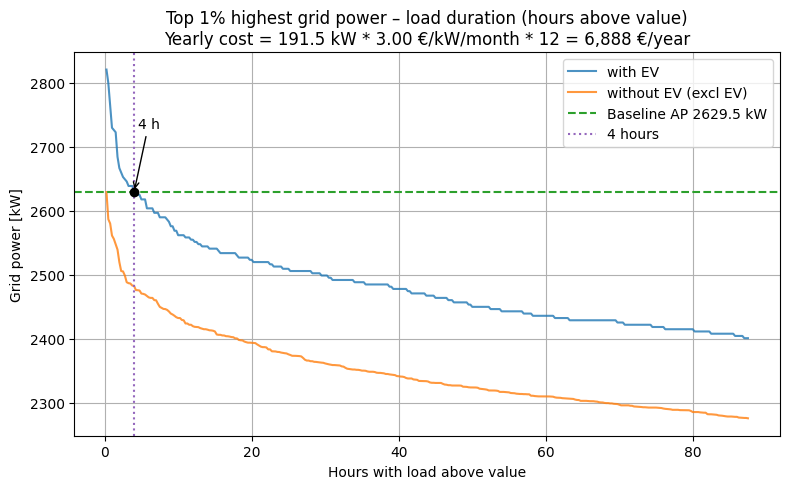

In [4]:
# Load duration curves for grid consumption (with and without EV)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

# Sort descending kW (ignoring NaNs)
ldc_with = np.sort(plant["grid_consumption_kw"].dropna().values)[::-1]
ldc_excl = np.sort(plant["grid_consumption_excl_ev_kw"].dropna().values)[::-1]

n = len(ldc_with)
x = np.arange(1, n + 1) / n  # exceedance probability / fraction of year

ax.plot(x, ldc_with, label="with EV", alpha=0.8)
ax.plot(x, ldc_excl, label="without EV (excl EV)", alpha=0.8)

ax.set_title("Load duration curves – Plant 1 grid consumption (2025)")
ax.set_xlabel("Fraction of hours with load above value")
ax.set_ylabel("Grid power [kW]")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Zoom on top 1% highest peaks with hours on x-axis
m = max(1, int(0.01 * n))  # number of 15-min intervals (top 1%)
hours = np.arange(1, m + 1) / 4.0  # convert 15-min intervals to hours

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(hours, ldc_with[:m], label="with EV", alpha=0.8)
ax2.plot(hours, ldc_excl[:m], label="without EV (excl EV)", alpha=0.8)

# Baseline access power and intersection at 4 hours
AP_BASELINE_KW = 2629.5
HOURS_INTERSECT = 4.0
ax2.axhline(AP_BASELINE_KW, color="tab:green", linestyle="--", label="Baseline AP 2629.5 kW")
ax2.axvline(HOURS_INTERSECT, color="tab:purple", linestyle=":", label="4 hours")
ax2.scatter([HOURS_INTERSECT], [AP_BASELINE_KW], color="black", zorder=5)
ax2.annotate("4 h",
             xy=(HOURS_INTERSECT, AP_BASELINE_KW),
             xytext=(HOURS_INTERSECT + 0.5, AP_BASELINE_KW + 100),
             arrowprops=dict(arrowstyle="->", color="black"))

# Compute and show annual cost: 4h * AP * price_per_kW * 12 months
import yaml
from pathlib import Path

billing_cfg = yaml.safe_load((Path("../config") / "billing.yaml").read_text(encoding="utf-8"))
peak_costs = billing_cfg.get("Peak_based_costs", {})
access_power_price = float(peak_costs.get("access_power_price_eur_per_kw", 0.0))

# Annual cost of extra access power capacity: (max_with_EV - max_without_EV) * price * 12
extra_access_kw = max_gc_kw - max_gc_excl_kw
annual_cost_eur = extra_access_kw * access_power_price * 12.0

subtitle = (
    f"Yearly cost = {extra_access_kw:.1f} kW * {access_power_price:.2f} €/kW/month * 12 = {annual_cost_eur:,.0f} €/year"
)

ax2.set_title("Top 1% highest grid power – load duration (hours above value)\n" + subtitle)
ax2.set_xlabel("Hours with load above value")
ax2.set_ylabel("Grid power [kW]")
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

### 1.2 Access power selection (grid-based)

Two **cum-max + 20 kW** rules on **metered grid** data (`plant1.csv` 2025 + `plant1_2024_training.csv`). January 2025 is seeded from the **2024** peak of the same series (no 2025 history yet at contract time).

**Conservative** (baseline / notebook 02 — matches `baseline_access_power_kw` in the deterministic export):

\[
P_{\mathrm{access},M}^{\mathrm{conservative}} = \max_{m < M}\bigl(\max_t 4 \cdot \texttt{grid\_consumption}_t^{(m)}\bigr) + 20\ \mathrm{kW}
\]

**Flex-aware** (online MPC contract in Part 2):

\[
P_{\mathrm{access},M}^{\mathrm{flex}} = \max_{m < M}\bigl(\max_t 4 \cdot \texttt{grid\_consumption\_excl\_ev}_t^{(m)}\bigr) + 20\ \mathrm{kW}
\]

**Deterministic (plot only):** `optimized_access_kw` from `output/notebooks/deterministic_ev_monthly_notebook_02.csv` (notebook 02 export).

**Exports after this cell:** `table`, `ACCESS_POWER_BASELINE_MONTHLY` (conservative), `ACCESS_POWER_ONLINE_MONTHLY` (flex-aware).

**Headroom validation** (weekdays 07:00–17:00, from first day with EV > 1 kWh/day; playroom load = `grid_consumption_excl_ev`):

\[
P_{\mathrm{hr},t} = \max\bigl(P_{\mathrm{access},M(t)} - 4 \cdot \texttt{grid\_consumption\_excl\_ev}_t,\ 0\bigr),\quad
H_d = \sum_{t \in \text{window}} P_{\mathrm{hr},t} \cdot 0.25\ \mathrm{kWh}
\]

**Thesis figures** (see [`STYLE_GUIDE_PLOTS.md`](../STYLE_GUIDE_PLOTS.md); caption-ready titles, no § prefix):

1. **Monthly access power (2025)** — stacked bars (peak excl. EV + EV increment) + step lines: **Online** (flex-aware), **Baseline** (conservative), **Offline** (deterministic).
2. **Daily electrical headroom and EV demand (2025)** — flex-aware headroom and actual daily EV need (weekdays 07:00–17:00).
3. **Daily headroom utilisation (2025)** — actual utilisation vs flex headroom and **70% limit** (weekdays 07:00–17:00).

No-PV counterfactual is in **§1.3**.


month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
actual_monthly_peak_kw_grid,2684.5,2726.5,2527.0,2506.0,2485.0,2411.5,2362.5,2240.0,2604.0,2821.0,2660.0,2765.0
actual_monthly_peak_kw_excl_ev,2629.5,2539.5,2520.0,2383.5,2274.5,2319.2,2235.3,2205.0,2405.3,2561.5,2580.4,2548.0
cummax_grid_kw_M_minus_1,2663.5,2684.5,2726.5,2726.5,2726.5,2726.5,2726.5,2726.5,2726.5,2726.5,2821.0,2821.0
cummax_excl_ev_kw_M_minus_1,2642.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5
access_power_conservative,2683.5,2704.5,2746.5,2746.5,2746.5,2746.5,2746.5,2746.5,2746.5,2746.5,2841.0,2841.0
access_power_flex_aware,2662.5,2649.5,2649.5,2649.5,2649.5,2649.5,2649.5,2649.5,2649.5,2649.5,2649.5,2649.5
access_power_deterministic,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5,2629.5


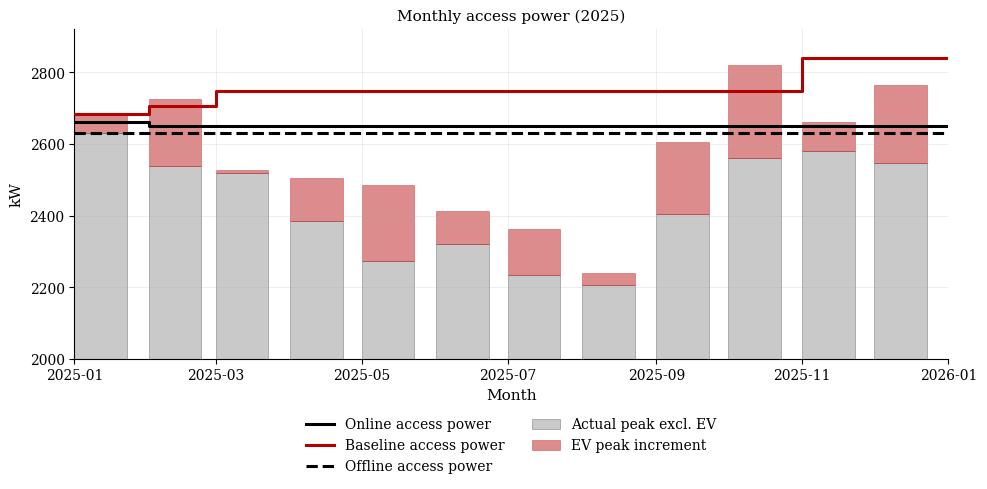

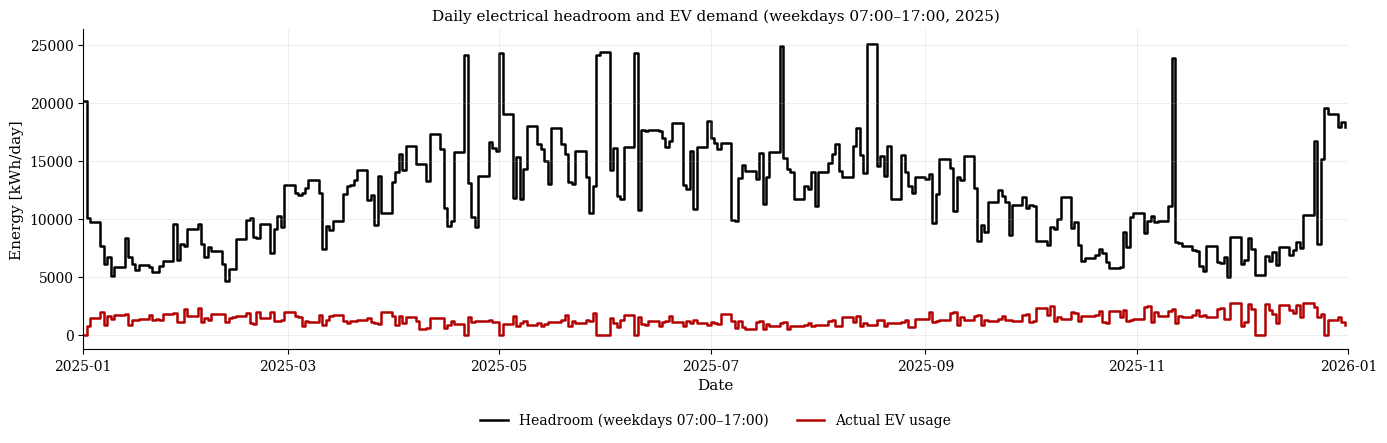

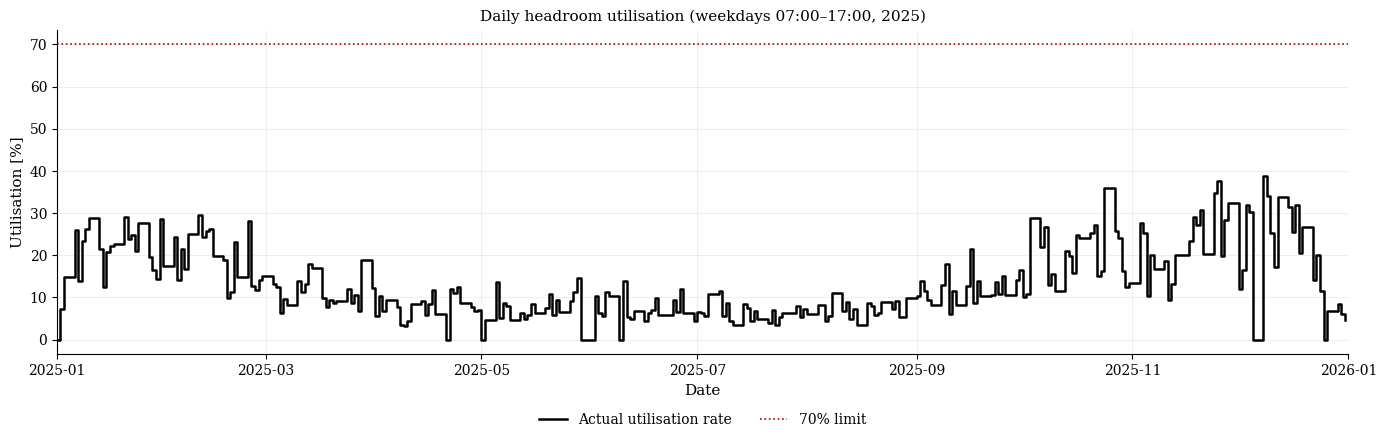

In [5]:
# §1.2 — Access power selection (grid-based)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
MARGIN_KW = 20.0

_det_ap_col = (
    "optimized_access_power_kw"
    if "optimized_access_power_kw" in DET_EV_MONTHLY.columns
    else "optimized_access_kw"
)
months = DET_EV_MONTHLY.set_index("month")[_det_ap_col].sort_index().index

# --- 2024 training ---
train_2024_path = PROJECT_ROOT / "data" / "plant1_2024_training.csv"
train_2024 = pd.read_csv(train_2024_path)
train_2024["month"] = pd.PeriodIndex(train_2024["timestamp"].astype(str).str.slice(0, 7), freq="M")

monthly_peak_2024_grid_kw = train_2024.groupby("month")["grid_consumption"].max() * 4.0
baseline_2024_peak_grid_kw = float(monthly_peak_2024_grid_kw.max())

monthly_peak_2024_excl_ev_kw = (
    train_2024.groupby("month")["grid_consumption_excl_ev"].max() * 4.0
)
baseline_2024_peak_excl_ev_kw = float(monthly_peak_2024_excl_ev_kw.max())

# --- 2025 monthly peaks (all hours) ---
tmp_2025 = plant.loc[
    plant["timestamp"].dt.year == 2025,
    ["timestamp", "grid_consumption", "grid_consumption_excl_ev"],
].copy()
tmp_2025["month"] = tmp_2025["timestamp"].dt.to_period("M")

monthly_peak_2025_grid_kw = (
    tmp_2025.groupby("month")["grid_consumption"].max() * 4.0
).reindex(months).astype(float)

monthly_peak_2025_excl_ev_kw = (
    tmp_2025.groupby("month")["grid_consumption_excl_ev"].max() * 4.0
).reindex(months).astype(float)

# --- Conservative: cum-max(grid_consumption, M-1) + margin ---
cummax_grid_Mm1_kw = monthly_peak_2025_grid_kw.cummax().shift(1)
cummax_grid_Mm1_kw.loc[months.min()] = baseline_2024_peak_grid_kw
cummax_grid_Mm1_kw = cummax_grid_Mm1_kw.fillna(baseline_2024_peak_grid_kw)
access_power_conservative_kw = cummax_grid_Mm1_kw + MARGIN_KW

months_2024 = monthly_peak_2024_grid_kw.sort_index().index
cummax_2024_Mm1_kw = monthly_peak_2024_grid_kw.cummax().shift(1)
cummax_2024_Mm1_kw.loc[months_2024.min()] = float(monthly_peak_2024_grid_kw.iloc[0])
cummax_2024_Mm1_kw = cummax_2024_Mm1_kw.fillna(float(monthly_peak_2024_grid_kw.iloc[0]))
access_power_conservative_2024_kw = cummax_2024_Mm1_kw + MARGIN_KW
access_power_by_month_conservative_hr = pd.concat(
    [access_power_conservative_2024_kw, access_power_conservative_kw]
).sort_index()

# --- Flex-aware: cum-max(grid_consumption_excl_ev, M-1) + margin ---
cummax_excl_ev_Mm1_kw = monthly_peak_2025_excl_ev_kw.cummax().shift(1)
cummax_excl_ev_Mm1_kw.loc[months.min()] = baseline_2024_peak_excl_ev_kw
cummax_excl_ev_Mm1_kw = cummax_excl_ev_Mm1_kw.fillna(baseline_2024_peak_excl_ev_kw)
access_power_flex_aware_kw = cummax_excl_ev_Mm1_kw + MARGIN_KW

cummax_2024_excl_ev_Mm1_kw = monthly_peak_2024_excl_ev_kw.cummax().shift(1)
cummax_2024_excl_ev_Mm1_kw.loc[months_2024.min()] = float(monthly_peak_2024_excl_ev_kw.iloc[0])
cummax_2024_excl_ev_Mm1_kw = cummax_2024_excl_ev_Mm1_kw.fillna(float(monthly_peak_2024_excl_ev_kw.iloc[0]))
access_power_flex_aware_2024_kw = cummax_2024_excl_ev_Mm1_kw + MARGIN_KW
access_power_by_month_flex_hr = pd.concat(
    [access_power_flex_aware_2024_kw, access_power_flex_aware_kw]
).sort_index()

access_power_deterministic_kw = (
    DET_EV_MONTHLY.assign(month_key=DET_EV_MONTHLY["month"].astype(str))
    .set_index("month_key")[_det_ap_col]
    .astype(float)
)

table = pd.DataFrame(
    {
        "actual_monthly_peak_kw_grid": monthly_peak_2025_grid_kw.values,
        "actual_monthly_peak_kw_excl_ev": monthly_peak_2025_excl_ev_kw.values,
        "cummax_grid_kw_M_minus_1": cummax_grid_Mm1_kw.values,
        "cummax_excl_ev_kw_M_minus_1": cummax_excl_ev_Mm1_kw.values,
        "access_power_conservative": access_power_conservative_kw.values,
        "access_power_flex_aware": access_power_flex_aware_kw.values,
        "access_power_deterministic": access_power_deterministic_kw.reindex(
            months.astype(str)
        ).values,
    },
    index=months,
).T
display(table.round(1))

# --- plant_hr for headroom validation plots ---
train_2024_ts = pd.to_datetime(train_2024["timestamp"], utc=True, errors="coerce")
train_2024_ts = train_2024_ts.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
_hr_cols = ["timestamp", "ev", "grid_consumption_excl_ev"]
plant_hr = pd.concat(
    [
        train_2024.assign(timestamp=train_2024_ts)[_hr_cols],
        plant.loc[plant["timestamp"].dt.year == 2025, _hr_cols],
    ],
    ignore_index=True,
).sort_values("timestamp")
for _c in ["ev", "grid_consumption_excl_ev"]:
    plant_hr[_c] = pd.to_numeric(plant_hr[_c], errors="coerce").fillna(0.0)

_ev_daily = plant_hr.assign(date=plant_hr["timestamp"].dt.normalize()).groupby("date")["ev"].sum()
plant_hr = plant_hr[plant_hr["timestamp"].dt.normalize() >= _ev_daily[_ev_daily > 1.0].index.min()].copy()


def _daily_headroom_kwh(ts, load_kwh_15, ev_window, access_by_month):
    access_kw = access_by_month.reindex(ts.dt.to_period("M")).to_numpy(dtype=float)
    headroom_kw = np.maximum(access_kw - 4.0 * np.asarray(load_kwh_15, dtype=float), 0.0)
    return (
        pd.DataFrame({"date": ts.dt.normalize(), "h": headroom_kw * 0.25})
        .loc[ev_window]
        .groupby("date")["h"]
        .sum()
    )


ts_hr = plant_hr["timestamp"]
ev_window = (
    (ts_hr.dt.dayofweek < 5)
    & (ts_hr.dt.hour + ts_hr.dt.minute / 60.0 >= 7.0)
    & (ts_hr.dt.hour + ts_hr.dt.minute / 60.0 < 17.0)
)
# Headroom load: grid draw without EV (kWh/15 min) — playroom = access − 4×grid_excl_ev
grid_excl_ev_kwh = plant_hr["grid_consumption_excl_ev"].to_numpy(dtype=float)

daily_h_cons = _daily_headroom_kwh(
    ts_hr, grid_excl_ev_kwh, ev_window, access_power_by_month_conservative_hr
)
daily_h_flex = _daily_headroom_kwh(
    ts_hr, grid_excl_ev_kwh, ev_window, access_power_by_month_flex_hr
)

daily_ev_kwh = (
    pd.DataFrame({"date": ts_hr.dt.normalize(), "ev": plant_hr["ev"]})
    .loc[ev_window]
    .groupby("date")["ev"]
    .sum()
    .reindex(daily_h_cons.index)
)
hr_dates = pd.to_datetime(daily_h_cons.index)
util_cons_pct = np.where(daily_h_cons > 1e-9, 100.0 * daily_ev_kwh / daily_h_cons, np.nan)
util_flex_pct = np.where(daily_h_flex > 1e-9, 100.0 * daily_ev_kwh / daily_h_flex, np.nan)

# --- §1.2 plots (STYLE_GUIDE_PLOTS.md) ---
import matplotlib as mpl

THESIS_STYLE = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}
mpl.rcParams.update(THESIS_STYLE)

C_BLACK = "#000000"
C_KUL_RED = "#b30000"
C_BAR_PEAK = "#666666"
LW_ACCESS = 2.2
LW_DAILY = 1.8
_LGND_BOTTOM = dict(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)
_X_START_2025 = pd.Timestamp("2025-01-01")
_X_END_2025 = pd.Timestamp("2026-01-01")

month_ts = months.to_timestamp()
month_ts_step = pd.DatetimeIndex([*month_ts, _X_END_2025])


def _extend_step_y(y_month) -> np.ndarray:
    y = np.asarray(y_month, dtype=float)
    return np.r_[y, y[-1]]


peak_excl_kw = monthly_peak_2025_excl_ev_kw.values.astype(float)
peak_ev_incr_kw = np.maximum(
    (monthly_peak_2025_grid_kw - monthly_peak_2025_excl_ev_kw).values.astype(float),
    0.0,
)
_bar_w_days = 22

fig_acc, ax_acc = plt.subplots(figsize=(10, 5))
ax_acc.bar(
    month_ts,
    peak_excl_kw,
    width=_bar_w_days,
    align="edge",
    color=C_BAR_PEAK,
    alpha=0.35,
    edgecolor=C_BLACK,
    linewidth=0.5,
    label="Actual peak excl. EV",
    zorder=1,
)
ax_acc.bar(
    month_ts,
    peak_ev_incr_kw,
    width=_bar_w_days,
    bottom=peak_excl_kw,
    align="edge",
    color=C_KUL_RED,
    alpha=0.45,
    edgecolor=C_KUL_RED,
    linewidth=0.5,
    label="EV peak increment",
    zorder=1,
)
ax_acc.step(
    month_ts_step,
    _extend_step_y(access_power_flex_aware_kw.values),
    where="post",
    color=C_BLACK,
    linewidth=LW_ACCESS,
    linestyle="-",
    label="Online access power",
    zorder=3,
)
ax_acc.step(
    month_ts_step,
    _extend_step_y(access_power_conservative_kw.values),
    where="post",
    color=C_KUL_RED,
    linewidth=LW_ACCESS,
    linestyle="-",
    label="Baseline access power",
    zorder=3,
)
ax_acc.step(
    month_ts_step,
    _extend_step_y(access_power_deterministic_kw.reindex(months.astype(str)).values),
    where="post",
    color=C_BLACK,
    linewidth=LW_ACCESS,
    linestyle="--",
    label="Offline access power",
    zorder=3,
)
ax_acc.set_title("Monthly access power (2025)")
ax_acc.set_ylabel("kW")
ax_acc.set_xlabel("Month")
_y_max_acc = float(
    np.nanmax(
        [
            np.nanmax(peak_excl_kw + peak_ev_incr_kw),
            access_power_conservative_kw.max(),
            access_power_flex_aware_kw.max(),
            access_power_deterministic_kw.reindex(months.astype(str)).max(),
        ]
    )
)
ax_acc.set_ylim(2000, _y_max_acc + 80)
ax_acc.set_xlim(_X_START_2025, _X_END_2025)
ax_acc.margins(x=0)
ax_acc.legend(**_LGND_BOTTOM)
fig_acc.subplots_adjust(bottom=0.26)
plt.tight_layout()
plt.show()

# Daily headroom / utilisation — 2025 only (weekdays 07:00–17:00)
idx_2025 = (
    pd.DatetimeIndex(pd.to_datetime(daily_h_flex.index))
    .normalize()
    .unique()
    .sort_values()
)
idx_2025 = idx_2025[idx_2025.year == 2025]

df_hr_2025 = pd.DataFrame(
    {
        "headroom": daily_h_flex.reindex(idx_2025),
        "ev_actual": daily_ev_kwh.reindex(idx_2025),
    },
    index=idx_2025,
).astype(float)
df_hr_2025["ev_actual"] = df_hr_2025["ev_actual"].replace([np.inf, -np.inf], np.nan)

util_actual_2025 = pd.Series(np.asarray(util_flex_pct, dtype=float), index=hr_dates).reindex(
    idx_2025
)

fig_hr, ax_hr = plt.subplots(figsize=(14, 4.5))
ax_hr.plot(
    df_hr_2025.index,
    df_hr_2025["headroom"],
    drawstyle="steps-post",
    color=C_BLACK,
    linewidth=LW_DAILY,
    label="Headroom (weekdays 07:00–17:00)",
    zorder=1,
)
ax_hr.plot(
    df_hr_2025.index,
    df_hr_2025["ev_actual"],
    drawstyle="steps-post",
    color=C_KUL_RED,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Actual EV usage",
    zorder=2,
)
ax_hr.set_title("Daily electrical headroom and EV demand (weekdays 07:00–17:00, 2025)")
ax_hr.set_ylabel("Energy [kWh/day]")
ax_hr.set_xlabel("Date")
ax_hr.set_xlim(_X_START_2025, _X_END_2025)
ax_hr.margins(x=0)
ax_hr.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False)
fig_hr.subplots_adjust(bottom=0.26)
plt.tight_layout()
plt.show()

fig_u, ax_u = plt.subplots(figsize=(14, 4.5))
ax_u.plot(
    idx_2025,
    util_actual_2025,
    drawstyle="steps-post",
    color=C_BLACK,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Actual utilisation rate",
    zorder=2,
)
ax_u.axhline(70.0, color=C_KUL_RED, linewidth=1.2, linestyle=":", label="70% limit")
ax_u.set_title("Daily headroom utilisation (weekdays 07:00–17:00, 2025)")
ax_u.set_ylabel("Utilisation [%]")
ax_u.set_xlabel("Date")
ax_u.set_xlim(_X_START_2025, _X_END_2025)
ax_u.margins(x=0)
ax_u.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2, frameon=False)
fig_u.subplots_adjust(bottom=0.24)
plt.tight_layout()
plt.show()


# --- Monthly access power for Parts 2–4 (§1.2 grid-based) ---
ACCESS_POWER_BASELINE_MONTHLY = access_power_conservative_kw.copy()
ACCESS_POWER_BASELINE_MONTHLY.index = ACCESS_POWER_BASELINE_MONTHLY.index.astype(str)
ACCESS_POWER_ONLINE_MONTHLY = access_power_flex_aware_kw.copy()
ACCESS_POWER_ONLINE_MONTHLY.index = ACCESS_POWER_ONLINE_MONTHLY.index.astype(str)


### 1.3 Access power selection (no-PV counterfactual)

Same structure as **§1.2**, but monthly peaks and access power use the **no-PV** site load (kWh/15 min):

- **With EV:** `grid_nopv = grid_consumption + pv_production - grid_injection` (monthly peak \(P = 4 \times\) max per month).
- **Excl. EV:** `grid_excl_ev_nopv = grid_consumption_excl_ev + pv_production - grid_injection`.
- **Conservative access:** cum-max\(_{m<M}\)(peak `grid_nopv`) + 20 kW; January 2025 seeded from 2024.
- **Flex-aware access:** cum-max\(_{m<M}\)(peak `grid_excl_ev_nopv`) + 20 kW; January 2025 seeded from 2024.
- **Headroom (conservative & flex-aware):** chosen access minus `grid_excl_ev_nopv` in the EV window (weekdays 07:00–17:00) — same playroom definition as §1.2, on the no-PV baseline load.

2024 training CSV has no `grid_injection`; there we use `inflex_load + ev` and `inflex_load` as the no-PV equivalents.

**Not used in Part 2** unless you explicitly switch `ACCESS_POWER_ONLINE_MONTHLY` to the §1.3 series.


month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
actual_monthly_peak_kw_grid_nopv,3007.9,2726.5,2844.6,2724.5,2813.5,2637.3,2787.3,2794.2,2715.2,2821.0,2690.0,2779.4
actual_monthly_peak_kw_excl_ev_nopv,2889.9,2588.4,2662.8,2603.0,2712.8,2596.8,2624.0,2747.6,2576.0,2694.1,2609.6,2631.6
cummax_grid_nopv_kw_M_minus_1,2663.5,3007.9,3007.9,3007.9,3007.9,3007.9,3007.9,3007.9,3007.9,3007.9,3007.9,3007.9
cummax_excl_ev_nopv_kw_M_minus_1,2642.5,2889.9,2889.9,2889.9,2889.9,2889.9,2889.9,2889.9,2889.9,2889.9,2889.9,2889.9
access_power_conservative_nopv,2683.5,3027.9,3027.9,3027.9,3027.9,3027.9,3027.9,3027.9,3027.9,3027.9,3027.9,3027.9
access_power_flex_aware_nopv,2662.5,2909.9,2909.9,2909.9,2909.9,2909.9,2909.9,2909.9,2909.9,2909.9,2909.9,2909.9


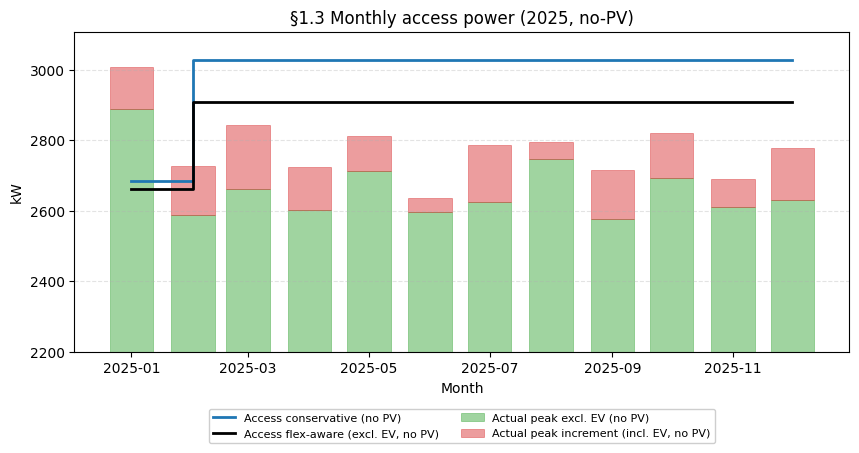

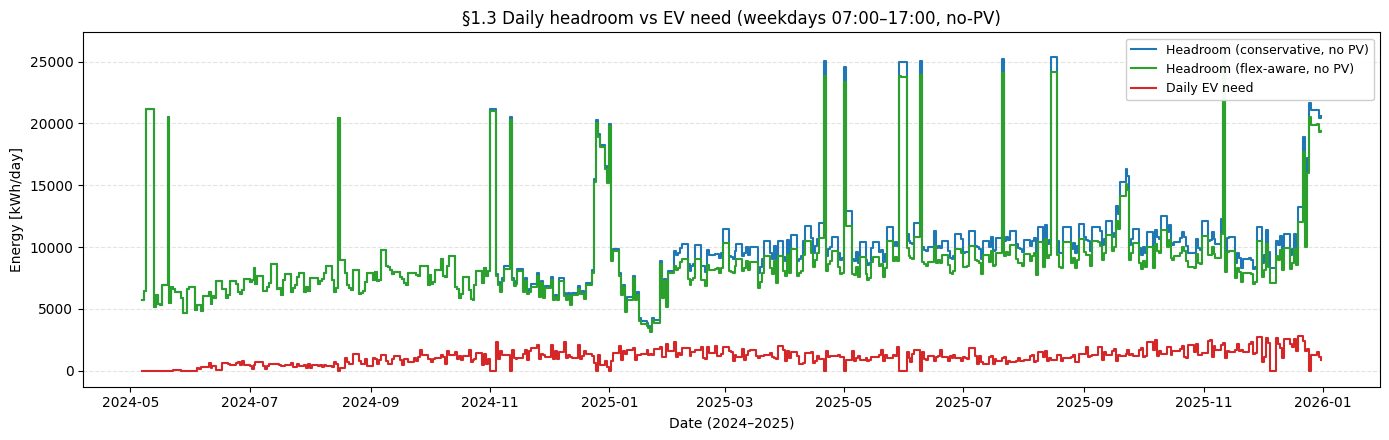

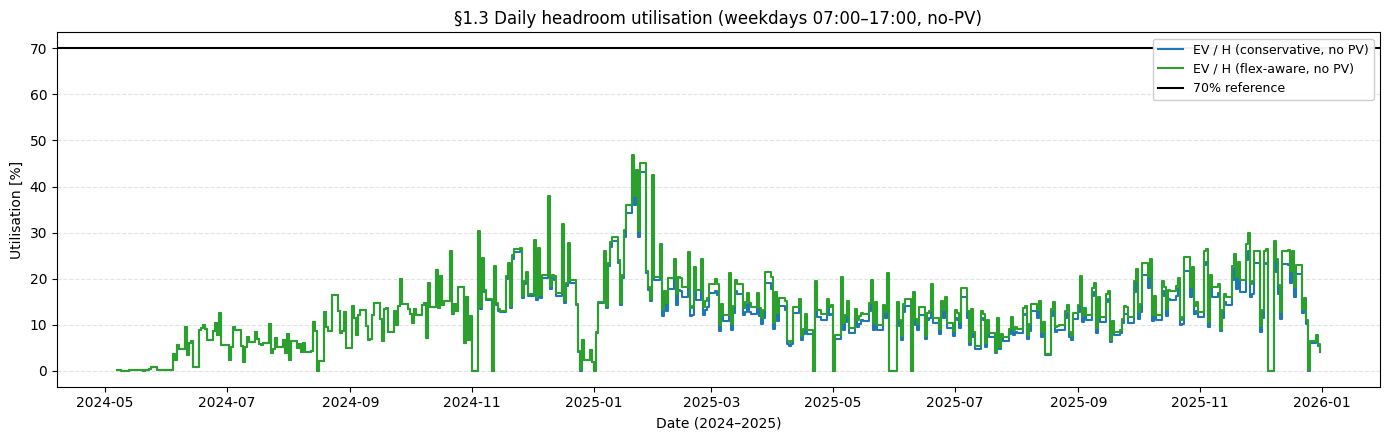

In [6]:
# §1.3 — Access power selection (no-PV counterfactual)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
MARGIN_KW = 20.0

months = (
    DET_EV_MONTHLY.set_index("month")["optimized_access_power_kw"]
    .sort_index()
    .index
)


def _add_nopv_columns(df: pd.DataFrame) -> pd.DataFrame:
    """No-PV site load (kWh/15 min): grid + PV - injection; 2024 fallback inflex (+ ev)."""
    out = df.copy()
    for c in [
        "grid_consumption",
        "grid_consumption_excl_ev",
        "pv_production",
        "grid_injection",
        "inflex_load",
        "ev",
    ]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0.0)
    if "grid_injection" in out.columns:
        out["grid_nopv"] = (
            out["grid_consumption"] + out["pv_production"] - out["grid_injection"]
        )
        out["grid_excl_ev_nopv"] = (
            out["grid_consumption_excl_ev"]
            + out["pv_production"]
            - out["grid_injection"]
        )
    else:
        out["grid_nopv"] = out["inflex_load"] + out["ev"]
        out["grid_excl_ev_nopv"] = out["inflex_load"]
    return out


# --- 2024 training ---
train_2024_path = PROJECT_ROOT / "data" / "plant1_2024_training.csv"
train_2024 = _add_nopv_columns(pd.read_csv(train_2024_path))
train_2024["month"] = pd.PeriodIndex(
    train_2024["timestamp"].astype(str).str.slice(0, 7), freq="M"
)

monthly_peak_2024_grid_nopv_kw = train_2024.groupby("month")["grid_nopv"].max() * 4.0
baseline_2024_peak_grid_nopv_kw = float(monthly_peak_2024_grid_nopv_kw.max())

monthly_peak_2024_excl_ev_nopv_kw = (
    train_2024.groupby("month")["grid_excl_ev_nopv"].max() * 4.0
)
baseline_2024_peak_excl_ev_nopv_kw = float(monthly_peak_2024_excl_ev_nopv_kw.max())

# --- 2025 monthly peaks (all hours) ---
_pv_cols = ["pv_production", "grid_injection"]
_tmp_cols = ["timestamp", "grid_consumption", "grid_consumption_excl_ev"] + [
    c for c in _pv_cols if c in plant.columns
]
tmp_2025 = _add_nopv_columns(
    plant.loc[plant["timestamp"].dt.year == 2025, _tmp_cols].copy()
)
tmp_2025["month"] = tmp_2025["timestamp"].dt.to_period("M")

monthly_peak_2025_grid_nopv_kw = (
    tmp_2025.groupby("month")["grid_nopv"].max() * 4.0
).reindex(months).astype(float)

monthly_peak_2025_excl_ev_nopv_kw = (
    tmp_2025.groupby("month")["grid_excl_ev_nopv"].max() * 4.0
).reindex(months).astype(float)

# --- Conservative: cum-max(grid_nopv, M-1) + margin ---
cummax_grid_nopv_Mm1_kw = monthly_peak_2025_grid_nopv_kw.cummax().shift(1)
cummax_grid_nopv_Mm1_kw.loc[months.min()] = baseline_2024_peak_grid_nopv_kw
cummax_grid_nopv_Mm1_kw = cummax_grid_nopv_Mm1_kw.fillna(baseline_2024_peak_grid_nopv_kw)
access_power_conservative_nopv_kw = cummax_grid_nopv_Mm1_kw + MARGIN_KW

months_2024 = monthly_peak_2024_grid_nopv_kw.sort_index().index
cummax_2024_nopv_Mm1_kw = monthly_peak_2024_grid_nopv_kw.cummax().shift(1)
cummax_2024_nopv_Mm1_kw.loc[months_2024.min()] = float(
    monthly_peak_2024_grid_nopv_kw.iloc[0]
)
cummax_2024_nopv_Mm1_kw = cummax_2024_nopv_Mm1_kw.fillna(
    float(monthly_peak_2024_grid_nopv_kw.iloc[0])
)
access_power_conservative_nopv_2024_kw = cummax_2024_nopv_Mm1_kw + MARGIN_KW
access_power_by_month_conservative_nopv_hr = pd.concat(
    [access_power_conservative_nopv_2024_kw, access_power_conservative_nopv_kw]
).sort_index()

# --- Flex-aware: cum-max(grid_excl_ev_nopv, M-1) + margin ---
cummax_excl_ev_nopv_Mm1_kw = monthly_peak_2025_excl_ev_nopv_kw.cummax().shift(1)
cummax_excl_ev_nopv_Mm1_kw.loc[months.min()] = baseline_2024_peak_excl_ev_nopv_kw
cummax_excl_ev_nopv_Mm1_kw = cummax_excl_ev_nopv_Mm1_kw.fillna(
    baseline_2024_peak_excl_ev_nopv_kw
)
access_power_flex_aware_nopv_kw = cummax_excl_ev_nopv_Mm1_kw + MARGIN_KW

cummax_2024_excl_ev_nopv_Mm1_kw = monthly_peak_2024_excl_ev_nopv_kw.cummax().shift(1)
cummax_2024_excl_ev_nopv_Mm1_kw.loc[months_2024.min()] = float(
    monthly_peak_2024_excl_ev_nopv_kw.iloc[0]
)
cummax_2024_excl_ev_nopv_Mm1_kw = cummax_2024_excl_ev_nopv_Mm1_kw.fillna(
    float(monthly_peak_2024_excl_ev_nopv_kw.iloc[0])
)
access_power_flex_aware_nopv_2024_kw = cummax_2024_excl_ev_nopv_Mm1_kw + MARGIN_KW
access_power_by_month_flex_nopv_hr = pd.concat(
    [access_power_flex_aware_nopv_2024_kw, access_power_flex_aware_nopv_kw]
).sort_index()

table_nopv = pd.DataFrame(
    {
        "actual_monthly_peak_kw_grid_nopv": monthly_peak_2025_grid_nopv_kw.values,
        "actual_monthly_peak_kw_excl_ev_nopv": monthly_peak_2025_excl_ev_nopv_kw.values,
        "cummax_grid_nopv_kw_M_minus_1": cummax_grid_nopv_Mm1_kw.values,
        "cummax_excl_ev_nopv_kw_M_minus_1": cummax_excl_ev_nopv_Mm1_kw.values,
        "access_power_conservative_nopv": access_power_conservative_nopv_kw.values,
        "access_power_flex_aware_nopv": access_power_flex_aware_nopv_kw.values,
    },
    index=months,
).T
display(table_nopv.round(1))

# --- plant_hr for headroom validation plots ---
train_2024_ts = pd.to_datetime(train_2024["timestamp"], utc=True, errors="coerce")
train_2024_ts = train_2024_ts.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
_hr_cols = ["timestamp", "ev", "grid_nopv", "grid_excl_ev_nopv"]
_plant_hr_2025_cols = ["timestamp", "ev"] + [
    c
    for c in [
        "grid_consumption",
        "grid_consumption_excl_ev",
        "pv_production",
        "grid_injection",
        "inflex_load",
    ]
    if c in plant.columns
]
plant_hr_nopv = pd.concat(
    [
        train_2024.assign(timestamp=train_2024_ts)[
            ["timestamp", "ev", "grid_nopv", "grid_excl_ev_nopv"]
        ],
        _add_nopv_columns(
            plant.loc[plant["timestamp"].dt.year == 2025, _plant_hr_2025_cols]
        )[["timestamp", "ev", "grid_nopv", "grid_excl_ev_nopv"]],
    ],
    ignore_index=True,
).sort_values("timestamp")
for _c in ["ev", "grid_nopv", "grid_excl_ev_nopv"]:
    plant_hr_nopv[_c] = pd.to_numeric(plant_hr_nopv[_c], errors="coerce").fillna(0.0)

_ev_daily_nopv = (
    plant_hr_nopv.assign(date=plant_hr_nopv["timestamp"].dt.normalize())
    .groupby("date")["ev"]
    .sum()
)
plant_hr_nopv = plant_hr_nopv[
    plant_hr_nopv["timestamp"].dt.normalize()
    >= _ev_daily_nopv[_ev_daily_nopv > 1.0].index.min()
].copy()


def _daily_headroom_kwh_nopv(ts, load_kwh_15, ev_window, access_by_month):
    access_kw = access_by_month.reindex(ts.dt.to_period("M")).to_numpy(dtype=float)
    headroom_kw = np.maximum(access_kw - 4.0 * np.asarray(load_kwh_15, dtype=float), 0.0)
    return (
        pd.DataFrame({"date": ts.dt.normalize(), "h": headroom_kw * 0.25})
        .loc[ev_window]
        .groupby("date")["h"]
        .sum()
    )


ts_hr_nopv = plant_hr_nopv["timestamp"]
ev_window_nopv = (
    (ts_hr_nopv.dt.dayofweek < 5)
    & (ts_hr_nopv.dt.hour + ts_hr_nopv.dt.minute / 60.0 >= 7.0)
    & (ts_hr_nopv.dt.hour + ts_hr_nopv.dt.minute / 60.0 < 17.0)
)
# Same baseline as §1.2: playroom = access − grid draw without EV (no-PV series)
grid_excl_ev_nopv_kwh = plant_hr_nopv["grid_excl_ev_nopv"].to_numpy(dtype=float)

daily_h_cons_nopv = _daily_headroom_kwh_nopv(
    ts_hr_nopv,
    grid_excl_ev_nopv_kwh,
    ev_window_nopv,
    access_power_by_month_conservative_nopv_hr,
)
daily_h_flex_nopv = _daily_headroom_kwh_nopv(
    ts_hr_nopv,
    grid_excl_ev_nopv_kwh,
    ev_window_nopv,
    access_power_by_month_flex_nopv_hr,
)

daily_ev_kwh_nopv = (
    pd.DataFrame({"date": ts_hr_nopv.dt.normalize(), "ev": plant_hr_nopv["ev"]})
    .loc[ev_window_nopv]
    .groupby("date")["ev"]
    .sum()
    .reindex(daily_h_cons_nopv.index)
)
hr_dates_nopv = pd.to_datetime(daily_h_cons_nopv.index)
util_cons_pct_nopv = np.where(
    daily_h_cons_nopv > 1e-9, 100.0 * daily_ev_kwh_nopv / daily_h_cons_nopv, np.nan
)
util_flex_pct_nopv = np.where(
    daily_h_flex_nopv > 1e-9, 100.0 * daily_ev_kwh_nopv / daily_h_flex_nopv, np.nan
)

# --- §1.3 plots (ZOH, solid lines; high-contrast palette) ---
C_BLACK = "#000000"
C_RED = "#d62728"
C_BLUE = "#1f77b4"
C_GREEN = "#2ca02c"
LW_PEAK, LW_ACCESS, LW_DAILY = 1.4, 2.0, 1.5

month_ts_nopv = months.to_timestamp()
peak_excl_nopv_kw = monthly_peak_2025_excl_ev_nopv_kw.values.astype(float)
peak_ev_incr_nopv_kw = (
    monthly_peak_2025_grid_nopv_kw - monthly_peak_2025_excl_ev_nopv_kw
).values.astype(float)
peak_ev_incr_nopv_kw = np.maximum(peak_ev_incr_nopv_kw, 0.0)
_bar_w_days = 22

fig_acc_nopv, ax_acc_nopv = plt.subplots(figsize=(10, 5))
ax_acc_nopv.bar(
    month_ts_nopv,
    peak_excl_nopv_kw,
    width=_bar_w_days,
    align="center",
    color=C_GREEN,
    alpha=0.45,
    edgecolor=C_GREEN,
    linewidth=0.6,
    label="Actual peak excl. EV (no PV)",
    zorder=1,
)
ax_acc_nopv.bar(
    month_ts_nopv,
    peak_ev_incr_nopv_kw,
    width=_bar_w_days,
    bottom=peak_excl_nopv_kw,
    align="center",
    color=C_RED,
    alpha=0.45,
    edgecolor=C_RED,
    linewidth=0.6,
    label="Actual peak increment (incl. EV, no PV)",
    zorder=1,
)
ax_acc_nopv.step(
    month_ts_nopv,
    access_power_conservative_nopv_kw.values,
    where="post",
    color=C_BLUE,
    linewidth=LW_ACCESS,
    linestyle="-",
    label="Access conservative (no PV)",
    zorder=3,
)
ax_acc_nopv.step(
    month_ts_nopv,
    access_power_flex_aware_nopv_kw.values,
    where="post",
    color=C_BLACK,
    linewidth=LW_ACCESS,
    linestyle="-",
    label="Access flex-aware (excl. EV, no PV)",
    zorder=3,
)
ax_acc_nopv.set_title("§1.3 Monthly access power (2025, no-PV)")
ax_acc_nopv.set_ylabel("kW")
ax_acc_nopv.set_xlabel("Month")
ax_acc_nopv.set_ylim(
    2200,
    max(
        access_power_conservative_nopv_kw.max(),
        access_power_flex_aware_nopv_kw.max(),
        monthly_peak_2025_grid_nopv_kw.max(),
        monthly_peak_2025_excl_ev_nopv_kw.max(),
    )
    + 80,
)
ax_acc_nopv.grid(True, axis="y", linestyle="--", alpha=0.35)
ax_acc_nopv.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, fontsize=8, framealpha=0.95
)
fig_acc_nopv.subplots_adjust(bottom=0.24)
plt.show()

fig_hr_nopv, ax_hr_nopv = plt.subplots(figsize=(14, 4.5))
ax_hr_nopv.step(
    hr_dates_nopv,
    daily_h_cons_nopv.values,
    where="post",
    color=C_BLUE,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Headroom (conservative, no PV)",
)
ax_hr_nopv.step(
    hr_dates_nopv,
    daily_h_flex_nopv.values,
    where="post",
    color=C_GREEN,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Headroom (flex-aware, no PV)",
)
ax_hr_nopv.step(
    hr_dates_nopv,
    daily_ev_kwh_nopv.values,
    where="post",
    color=C_RED,
    linewidth=LW_DAILY,
    linestyle="-",
    label="Daily EV need",
)
ax_hr_nopv.set_ylabel("Energy [kWh/day]")
ax_hr_nopv.set_xlabel("Date (2024–2025)")
ax_hr_nopv.set_title("§1.3 Daily headroom vs EV need (weekdays 07:00–17:00, no-PV)")
ax_hr_nopv.grid(True, axis="y", linestyle="--", alpha=0.35)
ax_hr_nopv.legend(loc="upper right", fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()

fig_u_nopv, ax_u_nopv = plt.subplots(figsize=(14, 4.5))
ax_u_nopv.step(
    hr_dates_nopv,
    util_cons_pct_nopv,
    where="post",
    color=C_BLUE,
    linewidth=LW_DAILY,
    linestyle="-",
    label="EV / H (conservative, no PV)",
)
ax_u_nopv.step(
    hr_dates_nopv,
    util_flex_pct_nopv,
    where="post",
    color=C_GREEN,
    linewidth=LW_DAILY,
    linestyle="-",
    label="EV / H (flex-aware, no PV)",
)
ax_u_nopv.axhline(
    70.0, color=C_BLACK, linewidth=1.5, linestyle="-", label="70% reference"
)
ax_u_nopv.set_ylabel("Utilisation [%]")
ax_u_nopv.set_xlabel("Date (2024–2025)")
ax_u_nopv.set_title("§1.3 Daily headroom utilisation (weekdays 07:00–17:00, no-PV)")
ax_u_nopv.grid(True, axis="y", linestyle="--", alpha=0.35)
ax_u_nopv.legend(loc="upper right", fontsize=9, framealpha=0.95)
plt.tight_layout()
plt.show()


## 2. Rolling-horizon online MPC simulation (EV-only)

Full-year simulation via `run_ev_online_mpc_1` in `online_MPC_1_EV.py`:

- At each 15 min step: 24 h EV-only MPC (`mpc_ev_24h`) on forecast data.
- Actuator chain: **clipper** (Eq. 3.50 in MPC; `min(access, peak_sofar)` in catch-up) → optional **enforce daily EV demand** (12:00–17:00): after a clip, add only the **minimum** kWh needed when `ev_to_deliver` cannot still be met using envelope headroom through **17:00**; otherwise defer to catch-up (`[17:00−slack, 17:00)`). Diagnostics: `ev_envelope_remaining_kwh`, `ev_envelope_headroom_after_kwh`, `ev_envelope_feasible`, `ev_enforce_deferred`.
- **Access power passed to MPC and online billing:** `ACCESS_POWER_ONLINE_MONTHLY` from §1.2 (**flex-aware**, cum-max `grid_consumption_excl_ev` + 20 kW). Set in the config cell below; run **§1.2** first.

Outputs: `results_ev_online`, `summary_ev_online` (monthly bills), and optional CSV export for Part 3.


In [23]:
# Configuration for EV-only online MPC 1

# Forecast strategies (must match columns in forecast_ev.csv / forecast_inflex_load.csv)
EV_FORECAST_STRATEGY = "c_p90"        # uses column like forecast_ev_a
INFLEX_FORECAST_STRATEGY = "c"    # uses column like forecast_inflex_a
PV_FORECAST_STRATEGY = "chronos2_elia_p50"  # "actual", "k1".. "k10"

# Slack before the real 17:00 deadline (minutes)
EV_DEADLINE_SLACK_MIN = 105        # e.g. 0, 15, 30

# Daily EV demand safeguard (applied after clipping)
ENFORCE_DAILY_EV_DEMAND = True

# Monthly access power from §1.2 (grid-based, kW) — keys 'YYYY-MM'
# Baseline / shadow billing: conservative (cum-max grid + 20 kW)
# Online MPC + online billing: flex-aware (cum-max grid_excl_ev + 20 kW)
if "ACCESS_POWER_BASELINE_MONTHLY" not in globals():
    ACCESS_POWER_BASELINE_MONTHLY = table.loc["access_power_conservative"].copy()
    ACCESS_POWER_BASELINE_MONTHLY.index = ACCESS_POWER_BASELINE_MONTHLY.index.astype(str)
if "ACCESS_POWER_ONLINE_MONTHLY" not in globals():
    ACCESS_POWER_ONLINE_MONTHLY = table.loc["access_power_flex_aware"].copy()
    ACCESS_POWER_ONLINE_MONTHLY.index = ACCESS_POWER_ONLINE_MONTHLY.index.astype(str)

In [8]:
from pathlib import Path
import sys

# Ensure src is on path
PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from online_MPC_1_EV import run_ev_online_mpc_1

results_ev_online, summary_ev_online = run_ev_online_mpc_1(
    forecast_strategy_ev=EV_FORECAST_STRATEGY,
    forecast_strategy_inflex=INFLEX_FORECAST_STRATEGY,
    forecast_strategy_pv=PV_FORECAST_STRATEGY,
    ev_deadline_slack_minutes=EV_DEADLINE_SLACK_MIN,
    enforce_daily_ev_demand=ENFORCE_DAILY_EV_DEMAND,
    access_power_by_month=ACCESS_POWER_ONLINE_MONTHLY,
    verbose=True,
)

results_ev_online.head(), list(summary_ev_online.keys())

EV-only Online MPC 1 – Full-year simulation
  EV forecast strategy:        c_p90
  Inflex forecast strategy:    c
  PV forecast strategy:        chronos2_elia_p50
  EV deadline slack (min): 105
  Enforce daily EV demand: True
  Plant data:             C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\data\plant1.csv
  EV forecast:            C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_ev_rolling_horizon.csv
  Inflex forecast:        C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_inflex_load_rolling_horizon.csv
  PV forecast:            C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_pv_rolling_horizon.csv
  Billing config:         C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\config\billing.yaml
--------------------------------------------------------------------------------
[Online MPC] Simulating day 2025-01-01 (step 1/35

(            timestamp  grid_consumption  price  pv_production  grid_injection  \
 0 2025-01-01 00:00:00           160.125  10.62            0.0             0.0   
 1 2025-01-01 00:15:00           161.875  10.62            0.0             0.0   
 2 2025-01-01 00:30:00           163.625  10.62            0.0             0.0   
 3 2025-01-01 00:45:00           154.000  10.62            0.0             0.0   
 4 2025-01-01 01:00:00           154.000  10.27            0.0             0.0   
 
    total_consumption   ev  inflex_load  grid_consumption_excl_ev  \
 0            160.125  0.0      160.125                   160.125   
 1            161.875  0.0      161.875                   161.875   
 2            163.625  0.0      163.625                   163.625   
 3            154.000  0.0      154.000                   154.000   
 4            154.000  0.0      154.000                   154.000   
 
    thermal_load  ...  current_peak_opt_kw  ev_power_envelope_base_kw  \
 0     91.313867 

In [9]:
# Export online MPC results for reuse (similar to notebook 02)

import pandas as pd
from pathlib import Path

# Ensure results from Part 2 are available
results_ev_online = results_ev_online.copy()

# 1) Full 15-min timeseries for notebook reuse
out_dir_notebooks = Path("../output/notebooks")
out_dir_notebooks.mkdir(parents=True, exist_ok=True)

export_15min_online = results_ev_online.copy()
export_15min_online_path = out_dir_notebooks / "online_ev_15min_notebook_09.csv"
export_15min_online.to_csv(export_15min_online_path, index=False)

print(f"Saved online MPC 15-min results to: {export_15min_online_path}")
print(f"  Rows: {len(export_15min_online)}")
if "ev" in export_15min_online.columns:
    print(f"  Total EV energy (sum ev): {export_15min_online['ev_online_mpc'].sum():.2f} (kW * step)")

# 2) EV timeseries export for optimised_ts (similar to deterministic_ev.csv)
out_dir_optimised_ts = Path("../output/optimised_ts")
out_dir_optimised_ts.mkdir(parents=True, exist_ok=True)

# Use timestamp and EV power
export_ev_ts = results_ev_online[["timestamp", "ev_online_mpc"]].copy()

export_ev_ts_path = out_dir_optimised_ts / "online_ev.csv"
export_ev_ts.to_csv(export_ev_ts_path, index=False)

print(f"Saved online EV schedule to: {export_ev_ts_path}")
print(f"  Rows: {len(export_ev_ts)}")
print(f"  Total EV energy (sum ev_online): {export_ev_ts['ev_online_mpc'].sum():.2f} (kW * step)")


Saved online MPC 15-min results to: ..\output\notebooks\online_ev_15min_notebook_09.csv
  Rows: 35040
  Total EV energy (sum ev): 345345.14 (kW * step)
Saved online EV schedule to: ..\output\optimised_ts\online_ev.csv
  Rows: 35040
  Total EV energy (sum ev_online): 345345.14 (kW * step)


## 3. Visualisation and comparison of results

Compare **uncontrolled EV**, **deterministic EV MPC** (notebook 02 / §3.5.2), and **online MPC** (Part 2) on profiles, peaks, uncharged energy, and costs.

**Shadow billing (§3.2):**
- **Baseline & deterministic** energy costs / peaks: `DET_EV_MONTHLY` export from notebook 02.
- **`baseline_access_kw` in plots:** §1.2 **conservative** access (`ACCESS_POWER_BASELINE_MONTHLY` / `table` row `access_power_conservative`) — aligned with notebook 02 baseline access.
- **`online_access_kw` in plots:** §1.2 **flex-aware** access — same series as the MPC constraint in Part 2.
- **Online net costs** come from Part 2 bills (computed with flex-aware access). Re-run Part 2 after changing §1.2 if you update access rules.


### 3.1 Optimized volumes

EV power, remaining energy, grid consumption, and MPC window diagnostics. Online series from Part 2 export or in-memory `results_ev_online`.


Top 5 highest grid_consumption peaks (online MPC, kW):


,timestamp,grid_consumption_kw
0,2025-10-24 11:00:00,2821.0
1,2025-10-24 11:30:00,2800.0
2,2025-12-15 09:15:00,2765.0
3,2025-10-24 11:15:00,2730.0
4,2025-02-11 08:45:00,2726.5


Visualizing week 6: 2025-02-10 to 2025-02-17
Selected day 2: 2025-02-11


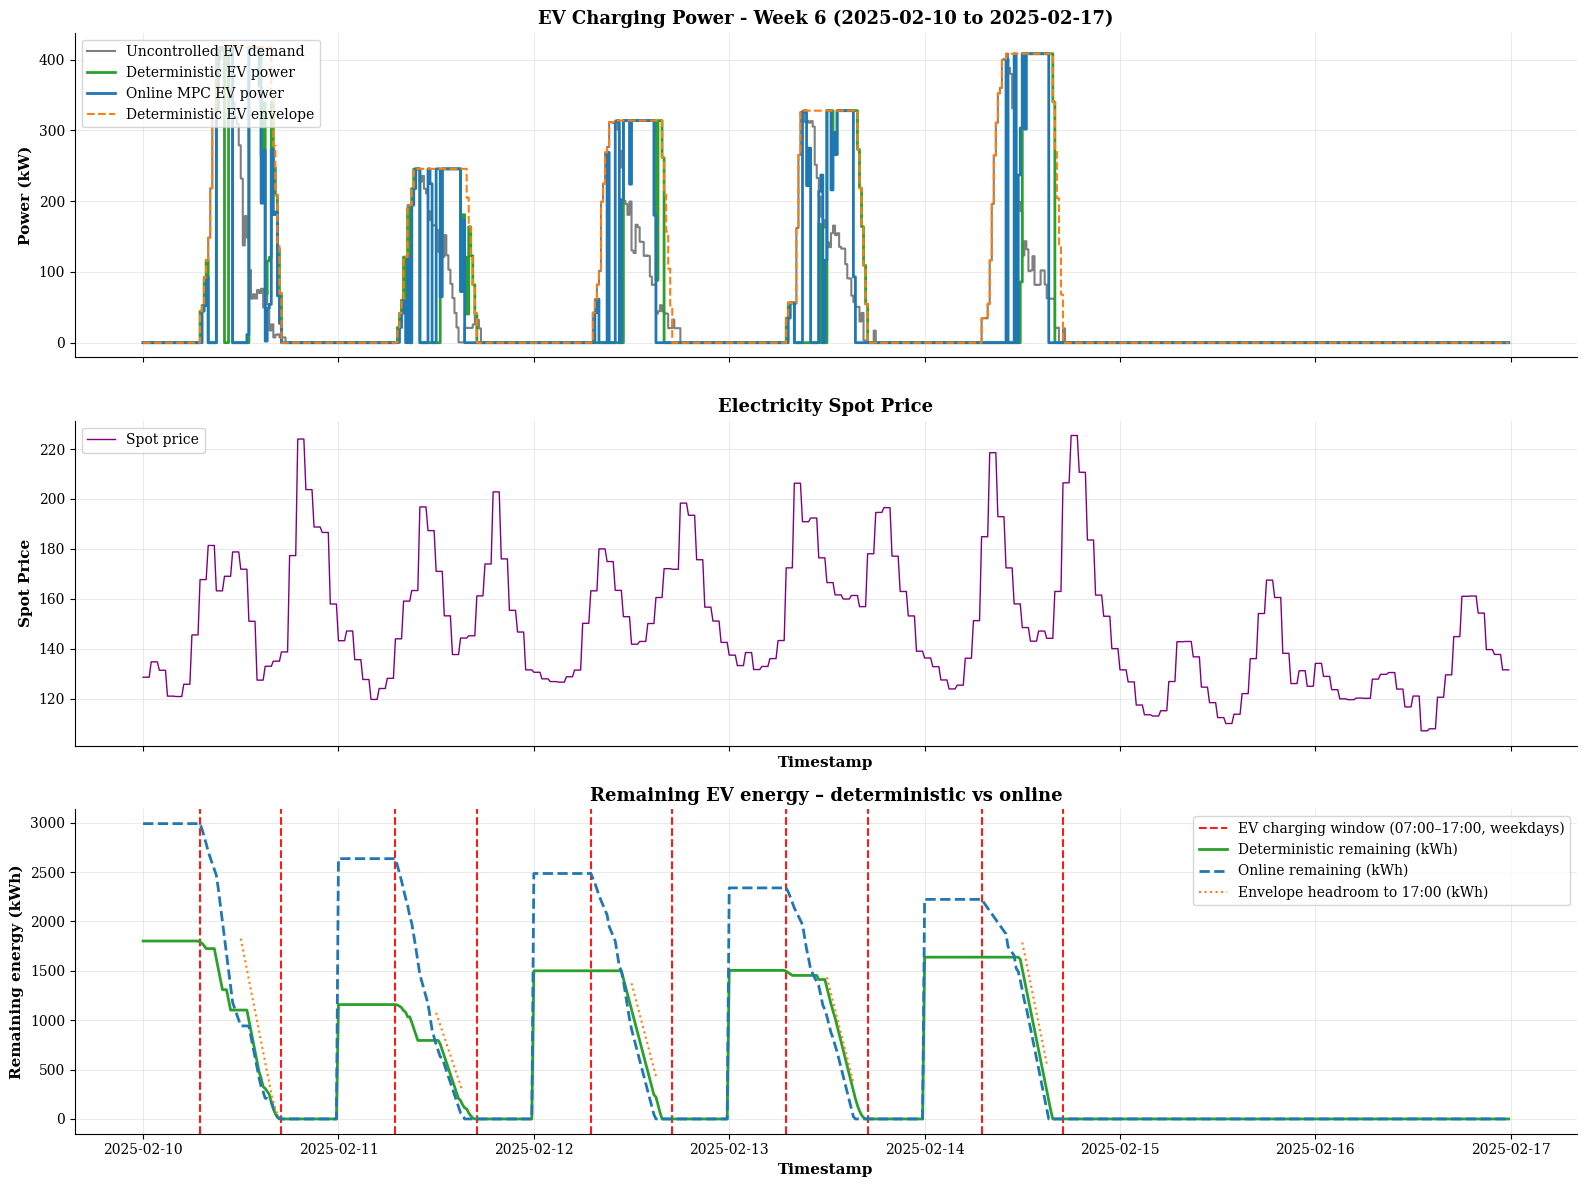

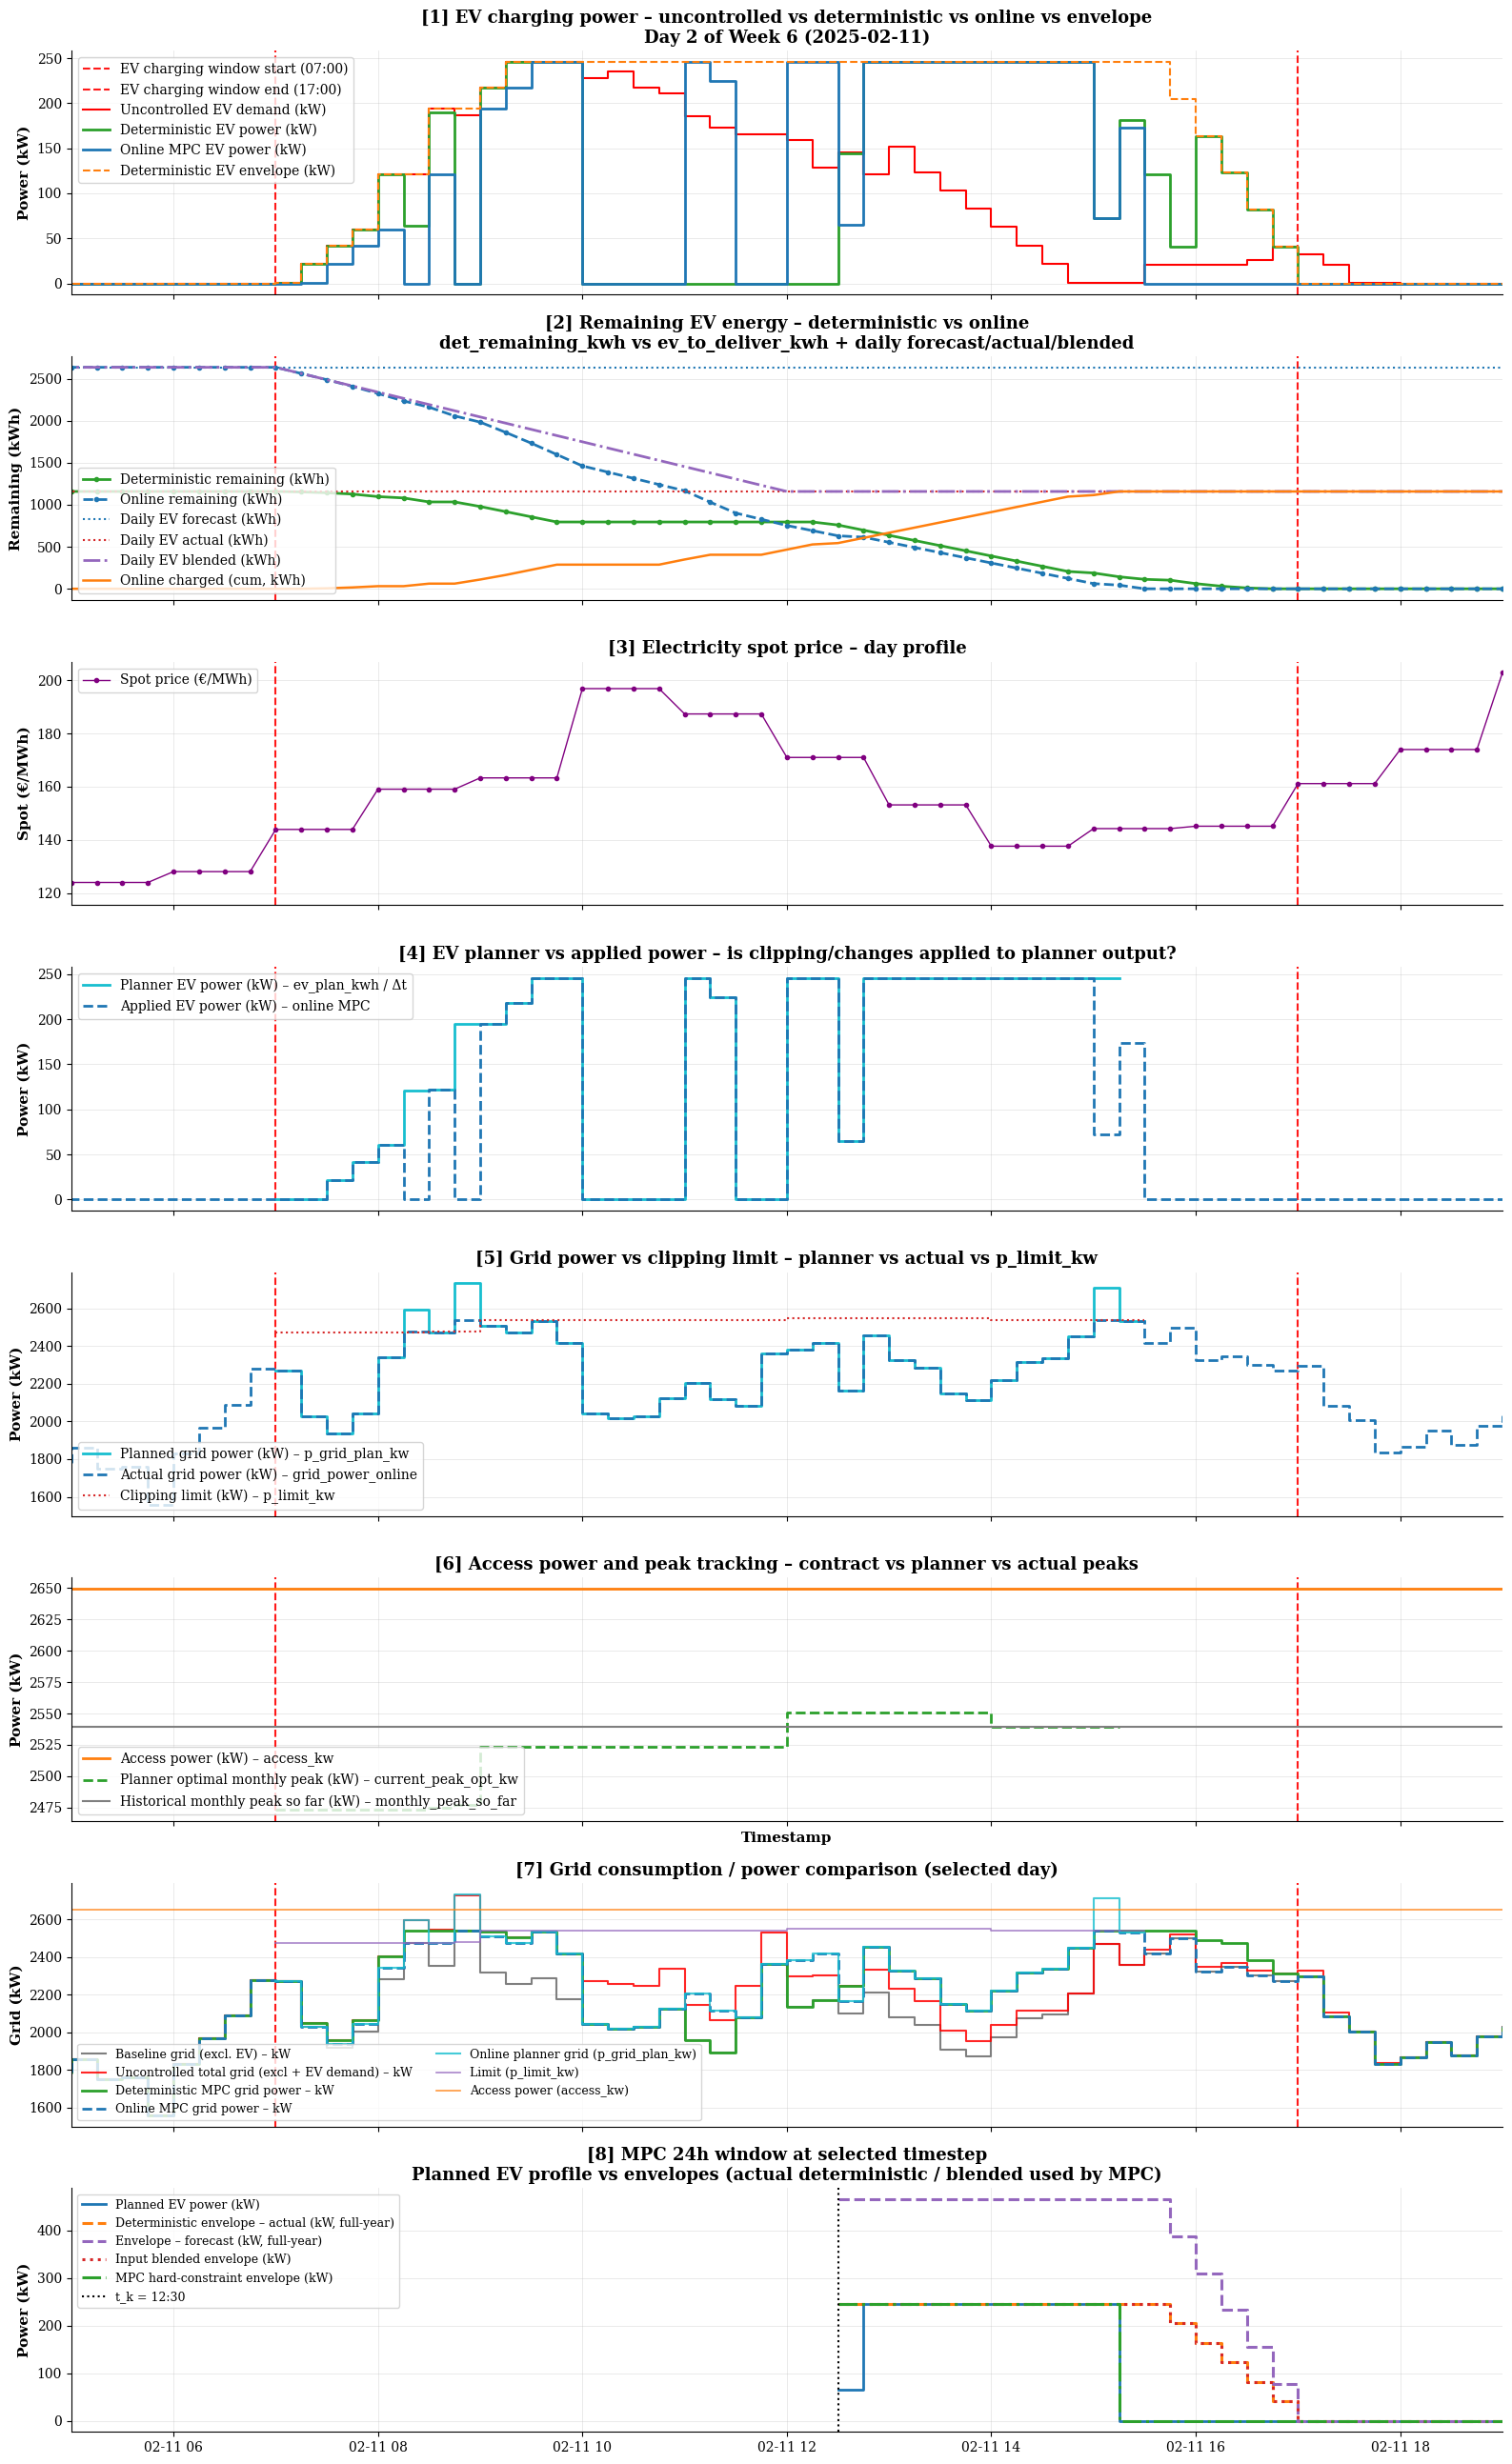

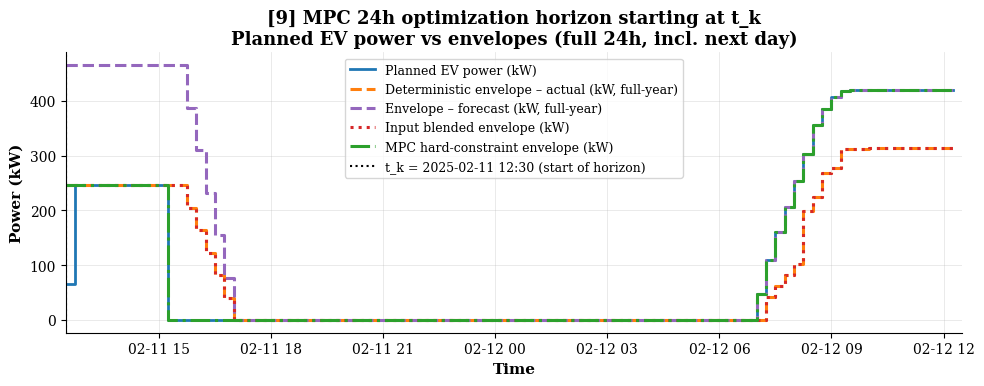

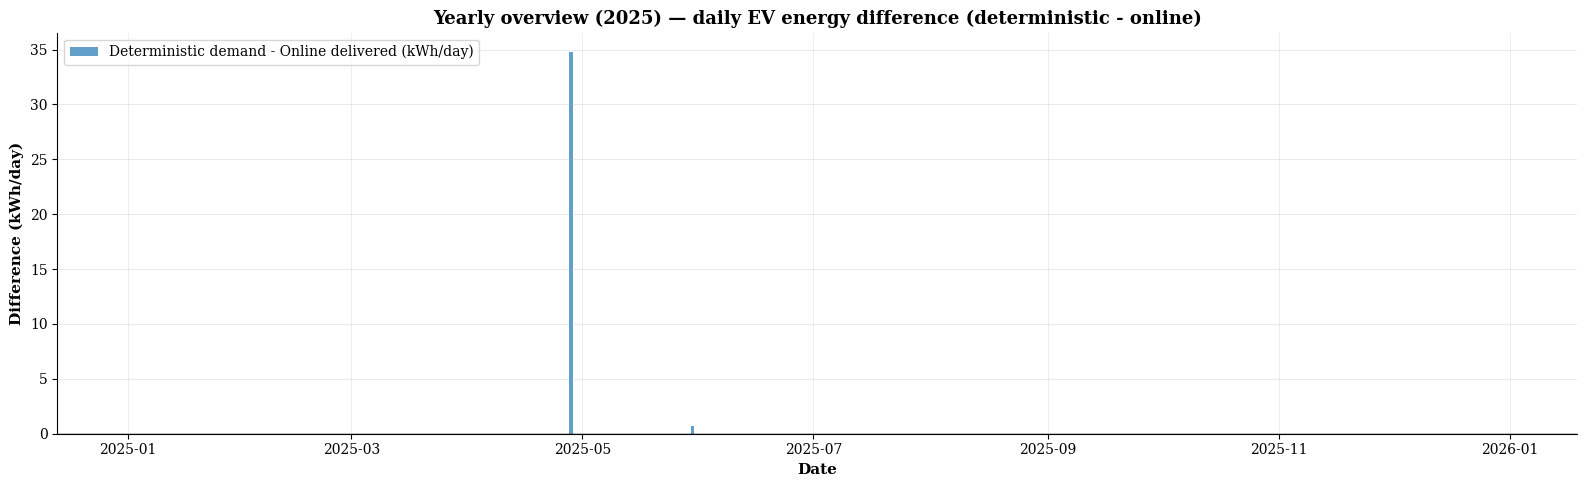

<Figure size 640x480 with 0 Axes>

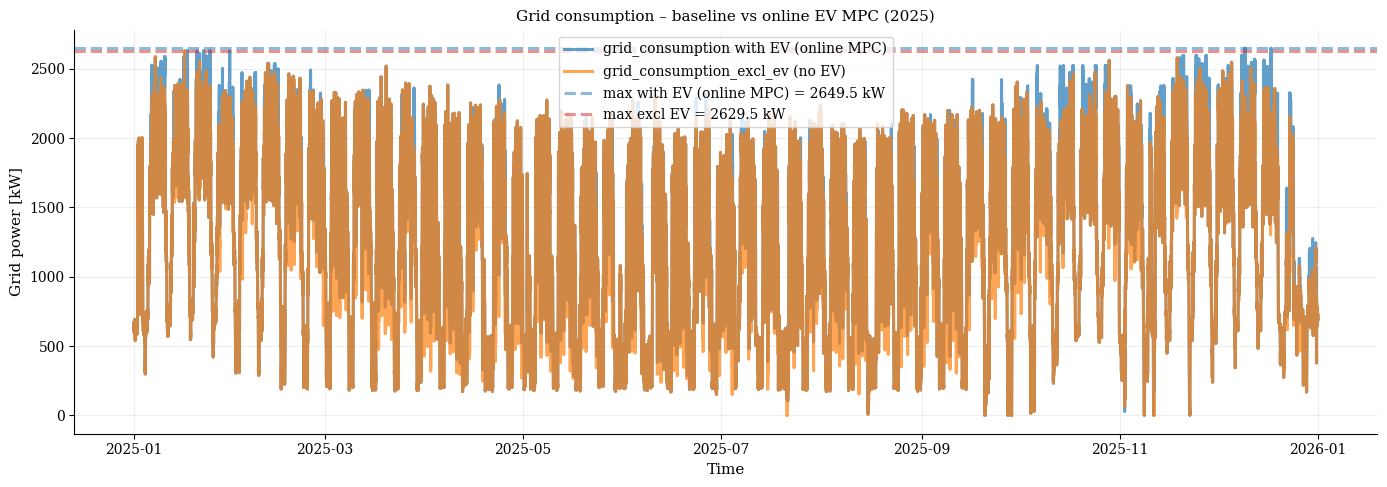

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Weekly / Daily / Yearly plots (EV only) — data only
# Expected columns in results_ev_online: timestamp, ev, ev_online_mpc, price

# Select week by week number (1-based), weeks starting on Monday
WEEK_NUMBER = 6  # change this (1..52) to select another week
day_of_week = 2  # Change this to select a day (1-7, where 1 is the first day of the selected week)
MPC_HOUR = 12
MPC_MINUTE = 30

# Plot data: None = use Part 2 in-memory/CSV; 105 = prefer Part 4 slack CSV if up to date.
PLOT_SLACK_MIN = None  # set to 105 only after re-running Part 4.1 with updated src

from pathlib import Path

_diag_cols = ["was_clipped", "ev_enforce_deferred", "ev_envelope_headroom_after_kwh"]

def _has_diag_cols(df):
    return all(c in df.columns for c in _diag_cols)

results_df = None
if "results_ev_online" in globals() and _has_diag_cols(results_ev_online):
    results_df = results_ev_online.copy()
    print("[Part 3] Using in-memory results_ev_online (Part 2)")
elif PLOT_SLACK_MIN is not None:
    csv_path = Path(
        f"../output/notebooks/online_ev_15min_notebook_09_{int(PLOT_SLACK_MIN)}_min_slack.csv"
    )
    if not csv_path.exists():
        raise FileNotFoundError(
            f"Slack CSV not found: {csv_path}. Run Part 4.1 or set PLOT_SLACK_MIN=None and run Part 2."
        )
    _csv_df = pd.read_csv(csv_path)
    if _has_diag_cols(_csv_df):
        results_df = _csv_df
        print(f"[Part 3] Loaded slack={PLOT_SLACK_MIN} min from {csv_path.name}")
    elif "results_ev_online" in globals():
        results_df = results_ev_online.copy()
        print(
            f"[Part 3] Slack CSV is stale (missing {_diag_cols}); using results_ev_online from Part 2 instead."
        )
    else:
        raise KeyError(
            f"{csv_path.name} is missing columns {[c for c in _diag_cols if c not in _csv_df.columns]}. "
            "Re-run Part 4.1 after updating src/online_MPC_1_EV.py, or run Part 2 in this session."
        )
elif "results_ev_online" in globals():
    results_df = results_ev_online.copy()
    print("[Part 3] Using in-memory results_ev_online (Part 2)")
else:
    csv_path = Path("../output/notebooks/online_ev_15min_notebook_09.csv")
    if not csv_path.exists():
        raise NameError(
            "`results_ev_online` is not defined and export CSV was not found at "
            f"{csv_path}. Run Part 2 once (online MPC) or update the path."
        )
    results_df = pd.read_csv(csv_path)

results_df["timestamp"] = pd.to_datetime(results_df["timestamp"], errors="raise")
results_df = results_df.sort_values("timestamp").reset_index(drop=True)

_missing_diag = [c for c in _diag_cols if c not in results_df.columns]
if _missing_diag:
    raise KeyError(
        f"Results missing columns {_missing_diag}. "
        "Re-run Part 2 (EV_DEADLINE_SLACK_MIN must match what you want to plot)."
    )

# --- Top 5 highest online MPC grid consumption peaks ---
# `grid_consumption` is kWh per 15-min interval -> convert to kW via *4.
if "grid_consumption" in results_df.columns:
    _peaks = results_df[["timestamp", "grid_consumption"]].copy()
    _peaks["grid_consumption_kw"] = pd.to_numeric(_peaks["grid_consumption"], errors="coerce") * 4.0
    top5_peaks_online = (
        _peaks.dropna(subset=["grid_consumption_kw"])
        .sort_values("grid_consumption_kw", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )
    print("Top 5 highest grid_consumption peaks (online MPC, kW):")
    display(top5_peaks_online[["timestamp", "grid_consumption_kw"]])
else:
    print("Column 'grid_consumption' not found in online results; cannot compute peaks.")

# Infer timestep in hours from the data
_dt_hours = results_df["timestamp"].diff().dt.total_seconds().median() / 3600.0

# Derived energy per 15-min step (kWh) from EV demand
results_df["ev_energy_kwh"] = results_df["ev"] * float(_dt_hours)

# Online EV power in kW (15-min kWh -> kW)
if "ev_online_mpc" in results_df.columns:
    results_df["ev_power_kw_online"] = results_df["ev_online_mpc"] / float(_dt_hours)
else:
    raise KeyError("results_ev_online must contain 'ev_online_mpc' column (kWh per 15-min step).")

# ----------------------
# Weekly + Daily plots
# ----------------------

year_start = pd.Timestamp("2025-01-01 00:00:00")
# First Monday on or after Jan 1
first_monday = year_start
while first_monday.weekday() != 0:  # 0 = Monday
    first_monday += pd.Timedelta(days=1)

start_week = first_monday + pd.Timedelta(days=(WEEK_NUMBER - 1) * 7)
end_week = start_week + pd.Timedelta(days=7)
week_number = WEEK_NUMBER

# Selected day inside that week
selected_day_start = start_week + pd.Timedelta(days=int(day_of_week) - 1)
selected_day_end = selected_day_start + pd.Timedelta(days=1)

print(f"Visualizing week {week_number}: {start_week.strftime('%Y-%m-%d')} to {end_week.strftime('%Y-%m-%d')}")
print(f"Selected day {day_of_week}: {selected_day_start.strftime('%Y-%m-%d')}")

# Filter data for selected week (online MPC results)
week_data = results_df[
    (results_df["timestamp"] >= start_week)
    & (results_df["timestamp"] < end_week)
].copy()

# Align with deterministic 15-min export to get baseline, deterministic, and envelope
# Allow plotting without re-running notebook 02 in this session.
if "DET_EV_15MIN" in globals():
    _week_det = DET_EV_15MIN.copy()
else:
    from pathlib import Path

    det_csv_path = Path("../output/notebooks/deterministic_ev_15min_notebook_02.csv")
    if not det_csv_path.exists():
        raise NameError(
            "`DET_EV_15MIN` is not defined and deterministic export CSV was not found at "
            f"{det_csv_path}. Run notebook 02 once (export) or update the path."
        )
    _week_det = pd.read_csv(det_csv_path)

_week_det["timestamp"] = pd.to_datetime(_week_det["timestamp"])
_week_det = _week_det[
    (_week_det["timestamp"] >= start_week)
    & (_week_det["timestamp"] < end_week)
].copy()

# Merge online results (week_data) with deterministic export on timestamp
_week_merge = week_data.merge(
    _week_det[["timestamp", "ev_demand_actual", "ev_charge_power", "ev_power_envelope"]],
    on="timestamp",
    how="left",
)

# Weekly plot: EV operation over one week

# Filter data for selected week (online MPC results)
week_data = results_df[
    (results_df["timestamp"] >= start_week)
    & (results_df["timestamp"] < end_week)
].copy()

# Align with deterministic 15-min export to get baseline, deterministic, and envelope
# Allow plotting without re-running notebook 02 in this session.
if "DET_EV_15MIN" in globals():
    _week_det = DET_EV_15MIN.copy()
else:
    from pathlib import Path

    det_csv_path = Path("../output/notebooks/deterministic_ev_15min_notebook_02.csv")
    if not det_csv_path.exists():
        raise NameError(
            "`DET_EV_15MIN` is not defined and deterministic export CSV was not found at "
            f"{det_csv_path}. Run notebook 02 once (export) or update the path."
        )
    _week_det = pd.read_csv(det_csv_path)

_week_det["timestamp"] = pd.to_datetime(_week_det["timestamp"])
_week_det = _week_det[
    (_week_det["timestamp"] >= start_week)
    & (_week_det["timestamp"] < end_week)
].copy()

# Deterministic remaining energy per time step (kWh)
_week_det["date"] = _week_det["timestamp"].dt.date
daily_det_demand = _week_det.groupby("date")["ev_demand_actual"].transform("sum")
_week_det["det_charged_cum_kwh"] = _week_det.groupby("date")["ev_charge"].cumsum()
_week_det["det_remaining_kwh"] = daily_det_demand - _week_det["det_charged_cum_kwh"]

# Merge online results (week_data) with deterministic export on timestamp
_week_merge = week_data.merge(
    _week_det[
        [
            "timestamp",
            "ev_demand_actual",
            "ev_charge_power",
            "ev_power_envelope",
            "det_remaining_kwh",
        ]
    ],
    on="timestamp",
    how="left",
)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Plot 1: EV power – uncontrolled, deterministic, online MPC, and deterministic envelope
ax1.step(
    _week_merge["timestamp"],
    _week_merge["ev_demand_actual"] * 4.0,  # kWh/15min -> kW
    label="Uncontrolled EV demand",
    color="tab:gray",
    linewidth=1.5,
    where="post",
)
ax1.step(
    _week_merge["timestamp"],
    _week_merge["ev_charge_power"],
    label="Deterministic EV power",
    color="tab:green",
    linewidth=2,
    where="post",
)
ax1.step(
    _week_merge["timestamp"],
    _week_merge["ev_power_kw_online"],
    label="Online MPC EV power",
    color="tab:blue",
    linewidth=2,
    where="post",
)
ax1.step(
    _week_merge["timestamp"],
    _week_merge["ev_power_envelope"],
    label="Deterministic EV envelope",
    color="tab:orange",
    linewidth=1.5,
    linestyle="--",
    where="post",
)
ax1.set_ylabel("Power (kW)", fontsize=11, fontweight="bold")
ax1.set_title(
    f"EV Charging Power - Week {week_number} "
    f"({start_week.strftime('%Y-%m-%d')} to {end_week.strftime('%Y-%m-%d')})",
    fontsize=13,
    fontweight="bold",
)

ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# Plot 2: Spot price (separate)
ax2.plot(
    _week_merge["timestamp"],
    _week_merge["price"],
    label="Spot price",
    color="purple",
    linewidth=1,
)
ax2.set_ylabel("Spot Price", fontsize=11, fontweight="bold")
ax2.set_xlabel("Timestamp", fontsize=11, fontweight="bold")
ax2.set_title("Electricity Spot Price", fontsize=13, fontweight="bold")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

import matplotlib.patches as mpatches

# Plot 3: Remaining EV energy (kWh) – deterministic vs online

# Vertical red lines to indicate EV charging window (weekdays 07:00–17:00)
first_label = True
for d in pd.date_range(start_week, end_week - pd.Timedelta(days=1), freq="D"):
    if d.weekday() < 5:  # Monday–Friday
        start_block = d.replace(hour=7, minute=0, second=0)
        end_block = d.replace(hour=17, minute=0, second=0)

        label = "EV charging window (07:00–17:00, weekdays)" if first_label else None
        first_label = False

        ax3.axvline(start_block, color="red", linestyle="--", linewidth=1.5, alpha=0.9, label=label)
        ax3.axvline(end_block,   color="red", linestyle="--", linewidth=1.5, alpha=0.9)

line_det, = ax3.plot(
    _week_merge["timestamp"],
    _week_merge["det_remaining_kwh"],
    label="Deterministic remaining (kWh)",
    color="tab:green",
    linewidth=2,
)
line_onl, = ax3.plot(
    _week_merge["timestamp"],
    _week_merge["ev_to_deliver_kwh"],
    label="Online remaining (kWh)",
    color="tab:blue",
    linewidth=2,
    linestyle="--",
)


if "ev_envelope_remaining_kwh" in _week_merge.columns:
    ax3.plot(
        _week_merge["timestamp"],
        _week_merge["ev_envelope_remaining_kwh"],
        label="Envelope headroom to 17:00 (kWh)",
        color="tab:orange",
        linewidth=1.5,
        linestyle=":",
    )

ax3.set_ylabel("Remaining energy (kWh)", fontsize=11, fontweight="bold")
ax3.set_xlabel("Timestamp", fontsize=11, fontweight="bold")
ax3.set_title("Remaining EV energy – deterministic vs online", fontsize=13, fontweight="bold")

ax3.legend(loc="upper right")
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Online MPC slice for this day
day_data = results_df[
    (results_df["timestamp"] >= selected_day_start)
    & (results_df["timestamp"] < selected_day_end)
].copy()

# Deterministic slice for this day
# Allow plotting without re-running notebook 02 in this session.
if "DET_EV_15MIN" in globals():
    _day_det = DET_EV_15MIN.copy()
else:
    from pathlib import Path

    det_csv_path = Path("../output/notebooks/deterministic_ev_15min_notebook_02.csv")
    if not det_csv_path.exists():
        raise NameError(
            "`DET_EV_15MIN` is not defined and deterministic export CSV was not found at "
            f"{det_csv_path}. Run notebook 02 once (export) or update the path."
        )
    _day_det = pd.read_csv(det_csv_path)

_day_det["timestamp"] = pd.to_datetime(_day_det["timestamp"])
_day_det = _day_det[
    (_day_det["timestamp"] >= selected_day_start)
    & (_day_det["timestamp"] < selected_day_end)
].copy()

# Deterministic remaining energy (kWh) for this day
_day_det["date"] = _day_det["timestamp"].dt.date
daily_det_demand = _day_det.groupby("date")["ev_demand_actual"].transform("sum")
_day_det["det_charged_cum_kwh"] = _day_det.groupby("date")["ev_charge"].cumsum()
_day_det["det_remaining_kwh"] = daily_det_demand - _day_det["det_charged_cum_kwh"]

# Merge online + deterministic for aligned plotting
_day_merge = day_data.merge(
    _day_det[
        [
            "timestamp",
            "ev_demand_actual",
            "ev_charge_power",
            "ev_power_envelope",
            "det_remaining_kwh",
            # Deterministic grid quantities
            "grid_power",
            "grid_consumption",
        ]
    ],
    on="timestamp",
    how="left",
)

fig, axes = plt.subplots(8, 1, figsize=(16, 26), sharex=True)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes

# Helper: x-limits for 05:00–19:00
x_start = selected_day_start.replace(hour=5, minute=0, second=0)
x_end = selected_day_start.replace(hour=19, minute=0, second=0)

# Add vertical red lines at 07:00 and 17:00 on all 7 daily plots
axes_daily = [ax1, ax2, ax3, ax4, ax5, ax6, ax7]

start_line = selected_day_start.replace(hour=7, minute=0, second=0, microsecond=0)
end_line   = selected_day_start.replace(hour=17, minute=0, second=0, microsecond=0)

for ax in axes_daily:
    ax.axvline(
        start_line,
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.9,
        label="EV charging window start (07:00)" if ax is axes_daily[0] else None,
    )
    ax.axvline(
        end_line,
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.9,
        label="EV charging window end (17:00)" if ax is axes_daily[0] else None,
    )

# Optional: ensure the legend on the first plot shows the red line meaning
axes_daily[0].legend(loc="upper right")

# ----------------------------
# Plot 1: EV power – uncontrolled, deterministic, online, envelope (kW)
# ----------------------------
ax1.step(
    _day_merge["timestamp"],
    _day_merge["ev_demand_actual"] * 4.0,  # kWh/15min -> kW
    label="Uncontrolled EV demand (kW)",
    color="red",
    linewidth=1.5,
    where="post",
)
ax1.step(
    _day_merge["timestamp"],
    _day_merge["ev_charge_power"],
    label="Deterministic EV power (kW)",
    color="tab:green",
    linewidth=2,
    where="post",
)
ax1.step(
    _day_merge["timestamp"],
    _day_merge["ev_power_kw_online"],
    label="Online MPC EV power (kW)",
    color="tab:blue",
    linewidth=2,
    where="post",
)
ax1.step(
    _day_merge["timestamp"],
    _day_merge["ev_power_envelope"],
    label="Deterministic EV envelope (kW)",
    color="tab:orange",
    linewidth=1.5,
    linestyle="--",
    where="post",
)
ax1.set_ylabel("Power (kW)", fontsize=11, fontweight="bold")
ax1.set_title(
    f"[1] EV charging power – uncontrolled vs deterministic vs online vs envelope\n"
    f"Day {day_of_week} of Week {week_number} ({selected_day_start.strftime('%Y-%m-%d')})",
    fontsize=13,
    fontweight="bold",
)
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# ----------------------------
# Plot 2: Remaining EV energy – deterministic vs online (kWh)
# ----------------------------
# --- daily energy scalars for this day (kWh) ---

this_date = selected_day_start.date()

# Actual daily EV energy (kWh) from deterministic MPC
daily_ev_actual_kwh = float(daily_det_demand.iloc[0])

# Forecasted daily EV energy (kWh):
# at the start of the day (w_actual = 0) ev_daily_demand_kwh = required_forecast
if "ev_daily_demand_kwh" in _day_merge.columns:
    daily_ev_forecast_kwh = float(_day_merge["ev_daily_demand_kwh"].iloc[0])
else:
    daily_ev_forecast_kwh = np.nan  # fallback, should not happen if online export is complete

# Time-of-day and unfolded fraction w_actual(t) for this day
tod_day = _day_merge["timestamp"].dt.hour + _day_merge["timestamp"].dt.minute / 60.0
w_actual_day = np.zeros_like(tod_day, dtype=float)
w_actual_day[tod_day <= 7.0] = 0.0
w_actual_day[tod_day >= 12.0] = 1.0
mid_mask = (tod_day > 7.0) & (tod_day < 12.0)
w_actual_day[mid_mask] = (tod_day[mid_mask] - 7.0) / 5.0

# Blended daily energy target (kWh) as seen at each timestep
daily_ev_blend_kwh = (1.0 - w_actual_day) * daily_ev_forecast_kwh + w_actual_day * daily_ev_actual_kwh

# Cumulative EV energy actually charged by online MPC during this day (kWh)
ev_energy_step_kwh = _day_merge["ev_power_kw_online"] * float(_dt_hours)
ev_charged_cum_kwh = ev_energy_step_kwh.cumsum()

ax2.plot(
    _day_merge["timestamp"],
    _day_merge["det_remaining_kwh"],
    label="Deterministic remaining (kWh)",
    color="tab:green",
    linewidth=2,
    marker="o",
    markersize=3,
)
ax2.plot(
    _day_merge["timestamp"],
    _day_merge["ev_to_deliver_kwh"],
    label="Online remaining (kWh)",
    color="tab:blue",
    linewidth=2,
    linestyle="--",
    marker="o",
    markersize=3,
)

# New: daily energy scalars and blended line
ax2.plot(
    _day_merge["timestamp"],
    np.full(len(_day_merge), daily_ev_forecast_kwh),
    label="Daily EV forecast (kWh)",
    color="tab:blue",
    linewidth=1.5,
    linestyle=":",
)
ax2.plot(
    _day_merge["timestamp"],
    np.full(len(_day_merge), daily_ev_actual_kwh),
    label="Daily EV actual (kWh)",
    color="tab:red",
    linewidth=1.5,
    linestyle=":",
)
ax2.plot(
    _day_merge["timestamp"],
    daily_ev_blend_kwh,
    label="Daily EV blended (kWh)",
    color="tab:purple",
    linewidth=2,
    linestyle="-.",
)
ax2.plot(
    _day_merge["timestamp"],
    ev_charged_cum_kwh,
    label="Online charged (cum, kWh)",
    color="tab:orange",
    linewidth=1.8,
)

ax2.set_ylabel("Remaining (kWh)", fontsize=11, fontweight="bold")
ax2.set_title(
    "[2] Remaining EV energy – deterministic vs online\n"
    "det_remaining_kwh vs ev_to_deliver_kwh + daily forecast/actual/blended",
    fontsize=13,
    fontweight="bold",
)
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

# ----------------------------
# Plot 3: Spot price (€/MWh)
# ----------------------------
ax3.plot(
    _day_merge["timestamp"],
    _day_merge["price"],
    label="Spot price (€/MWh)",
    color="purple",
    linewidth=1,
    marker="o",
    markersize=3,
)
ax3.set_ylabel("Spot (€/MWh)", fontsize=11, fontweight="bold")
ax3.set_title("[3] Electricity spot price – day profile", fontsize=13, fontweight="bold")
ax3.legend(loc="upper left")
ax3.grid(True, alpha=0.3)

# ----------------------------
# Plot 4: EV planner vs applied EV power (kW)
# ----------------------------
ax4.step(
    _day_merge["timestamp"],
    _day_merge["ev_plan_kwh"] / float(_dt_hours),
    label="Planner EV power (kW) – ev_plan_kwh / Δt",
    color="tab:cyan",
    linewidth=2,
    where="post",
)
ax4.step(
    _day_merge["timestamp"],
    _day_merge["ev_power_kw_online"],
    label="Applied EV power (kW) – online MPC",
    color="tab:blue",
    linewidth=2,
    linestyle="--",
    where="post",
)
ax4.set_ylabel("Power (kW)", fontsize=11, fontweight="bold")
ax4.set_title(
    "[4] EV planner vs applied power – is clipping/changes applied to planner output?",
    fontsize=13,
    fontweight="bold",
)
ax4.legend(loc="upper left")
ax4.grid(True, alpha=0.3)

# ----------------------------
# Plot 5: Grid power – planner vs actual vs clipping limit (kW)
# ----------------------------
ax5.step(
    _day_merge["timestamp"],
    _day_merge["p_grid_plan_kw"],
    label="Planned grid power (kW) – p_grid_plan_kw",
    color="tab:cyan",
    linewidth=2,
    where="post",
)
ax5.step(
    _day_merge["timestamp"],
    _day_merge["grid_power_online"],
    label="Actual grid power (kW) – grid_power_online",
    color="tab:blue",
    linewidth=2,
    linestyle="--",
    where="post",
)
ax5.step(
    _day_merge["timestamp"],
    _day_merge["p_limit_kw"],
    label="Clipping limit (kW) – p_limit_kw",
    color="tab:red",
    linewidth=1.5,
    linestyle=":",
    where="post",
)
ax5.set_ylabel("Power (kW)", fontsize=11, fontweight="bold")
ax5.set_title(
    "[5] Grid power vs clipping limit – planner vs actual vs p_limit_kw",
    fontsize=13,
    fontweight="bold",
)
ax5.legend(loc="lower left")
ax5.grid(True, alpha=0.3)

# ----------------------------
# Plot 6: Access power & peak tracking (kW)
# ----------------------------
ax6.step(
    _day_merge["timestamp"],
    _day_merge["access_kw"],
    label="Access power (kW) – access_kw",
    color="tab:orange",
    linewidth=2,
    where="post",
)
ax6.step(
    _day_merge["timestamp"],
    _day_merge["current_peak_opt_kw"],
    label="Planner optimal monthly peak (kW) – current_peak_opt_kw",
    color="tab:green",
    linewidth=2,
    linestyle="--",
    where="post",
)
ax6.step(
    _day_merge["timestamp"],
    _day_merge["monthly_peak_so_far"],
    label="Historical monthly peak so far (kW) – monthly_peak_so_far",
    color="tab:gray",
    linewidth=1.5,
    where="post",
)
ax6.set_ylabel("Power (kW)", fontsize=11, fontweight="bold")
ax6.set_xlabel("Timestamp", fontsize=11, fontweight="bold")
ax6.set_title(
    "[6] Access power and peak tracking – contract vs planner vs actual peaks",
    fontsize=13,
    fontweight="bold",
)
ax6.legend(loc="lower left")
ax6.grid(True, alpha=0.3)

# ----------------------------
# Plot 7: Grid consumption comparison (kW)
# ----------------------------
# Convert kWh/15min -> kW via *4 for consumption series
base_excl_kw = pd.to_numeric(_day_merge.get("grid_consumption_excl_ev"), errors="coerce") * 4.0
uncontrolled_total_kw = (
    pd.to_numeric(_day_merge.get("grid_consumption_excl_ev"), errors="coerce")
    + pd.to_numeric(_day_merge.get("ev_demand_actual"), errors="coerce")
) * 4.0

# Deterministic grid power is already in kW in notebook 02 export
det_grid_kw = pd.to_numeric(_day_merge.get("grid_power"), errors="coerce")

# Online grid power is already in kW in this notebook's exported 15-min CSV (Part 2)
online_grid_kw = pd.to_numeric(_day_merge.get("grid_power_online"), errors="coerce")

ax7.step(
    _day_merge["timestamp"],
    base_excl_kw,
    label="Baseline grid (excl. EV) – kW",
    color="tab:gray",
    linewidth=1.5,
    where="post",
)
ax7.step(
    _day_merge["timestamp"],
    uncontrolled_total_kw,
    label="Uncontrolled total grid (excl + EV demand) – kW",
    color="red",
    linewidth=1.5,
    alpha=0.85,
    where="post",
)
ax7.step(
    _day_merge["timestamp"],
    det_grid_kw,
    label="Deterministic MPC grid power – kW",
    color="tab:green",
    linewidth=2,
    where="post",
)
ax7.step(
    _day_merge["timestamp"],
    online_grid_kw,
    label="Online MPC grid power – kW",
    color="tab:blue",
    linewidth=2,
    linestyle="--",
    where="post",
)

# Extra reference lines (to reach 7 lines total): planner, limit, access
ax7.step(
    _day_merge["timestamp"],
    pd.to_numeric(_day_merge.get("p_grid_plan_kw"), errors="coerce"),
    label="Online planner grid (p_grid_plan_kw)",
    color="tab:cyan",
    linewidth=1.5,
    alpha=0.8,
    where="post",
)
ax7.step(
    _day_merge["timestamp"],
    pd.to_numeric(_day_merge.get("p_limit_kw"), errors="coerce"),
    label="Limit (p_limit_kw)",
    color="tab:purple",
    linewidth=1.2,
    alpha=0.8,
    where="post",
)
ax7.step(
    _day_merge["timestamp"],
    pd.to_numeric(_day_merge.get("access_kw"), errors="coerce"),
    label="Access power (access_kw)",
    color="tab:orange",
    linewidth=1.2,
    alpha=0.8,
    where="post",
)

ax7.set_ylabel("Grid (kW)", fontsize=11, fontweight="bold")
ax7.set_title("[7] Grid consumption / power comparison (selected day)", fontsize=13, fontweight="bold")
ax7.legend(loc="lower left", ncol=2, fontsize=9)
ax7.grid(True, alpha=0.3)

# ----------------------------
# Plot 8: MPC 24h window at selected timestep
# ----------------------------
from pathlib import Path

t_k = selected_day_start.replace(
    hour=MPC_HOUR,
    minute=MPC_MINUTE,
    second=0,
    microsecond=0,
)

# Lazy-load the large debug CSV once per session
if "MPC_DEBUG_08" in globals():
    debug_df = MPC_DEBUG_08
else:
    debug_csv_path = Path("../output/notebooks/online_ev_mpc_debug_notebook_09.csv")
    if not debug_csv_path.exists():
        debug_df = None
        ax8.text(
            0.5, 0.5,
            f"MPC debug CSV not found at\n{debug_csv_path}",
            ha="center", va="center", transform=ax8.transAxes,
        )
        ax8.set_axis_off()
    else:
        MPC_DEBUG_08 = pd.read_csv(
            debug_csv_path,
            parse_dates=["t_k", "timestamp_window"],
        )
        debug_df = MPC_DEBUG_08

if debug_df is not None:
    window_df = (
        debug_df.loc[debug_df["t_k"] == t_k]
        .sort_values("timestamp_window")
        .reset_index(drop=True)
    )

    if window_df.empty:
        ax8.text(
            0.5, 0.5,
            f"No MPC window found for t_k = {t_k}",
            ha="center", va="center", transform=ax8.transAxes,
        )
        ax8.set_axis_off()
    else:
        ts_win = window_df["timestamp_window"]

        # Index of t_k in full-year results_df
        # (assumes same timestamp grid as online simulation)
        idx0 = results_df.index[results_df["timestamp"] == t_k]
        if len(idx0) == 0:
            ax8.text(
                0.5, 0.5,
                f"t_k = {t_k} not found in results_df",
                ha="center", va="center", transform=ax8.transAxes,
            )
            ax8.set_axis_off()
        else:
            idx0 = int(idx0[0])
            idx1 = idx0 + len(window_df)

                        # Actual deterministic envelope used for catch-up (full-year)
            if "ev_power_envelope_base_kw" in results_df.columns:
                env_actual_kw = results_df["ev_power_envelope_base_kw"].iloc[idx0:idx1].to_numpy()
            else:
                env_actual_kw = np.full(len(ts_win), np.nan)

            # Blended envelope actually passed into mpc_ev_24h (per-window, input)
            if "in_ev_power_envelope_fixed_kw" in window_df.columns:
                env_blend_kw = window_df["in_ev_power_envelope_fixed_kw"].astype(float).to_numpy()
            else:
                env_blend_kw = np.full(len(ts_win), np.nan)

            # Forecast-only envelope slice (per-window) from online_MPC_1_EV.py
            if "in_ev_power_envelope_forecast_kw" in window_df.columns:
                env_forecast_kw = window_df["in_ev_power_envelope_forecast_kw"].astype(float).to_numpy()
            else:
                env_forecast_kw = np.full(len(ts_win), np.nan)

            # Hard-constraint envelope inside MPC after slack shift
            if "opt_ev_power_envelope_mpc" in window_df.columns:
                env_mpc_kw = window_df["opt_ev_power_envelope_mpc"].astype(float).to_numpy()
            else:
                env_mpc_kw = np.full(len(ts_win), np.nan)

            # Planned EV power from optimiser
            if "opt_ev_charge" in window_df.columns:
                p_ev_plan_kw = window_df["opt_ev_charge"].astype(float).to_numpy() * 4.0
            else:
                p_ev_plan_kw = np.full(len(ts_win), np.nan)

            # Plot everything as zero-order-hold (step) blocks
            ax8.step(
                ts_win,
                p_ev_plan_kw,
                label="Planned EV power (kW)",
                color="C0",
                linewidth=2,
                where="post",
            )
            ax8.step(
                ts_win,
                env_actual_kw,
                label="Deterministic envelope – actual (kW, full-year)",
                color="C1",
                linestyle="--",
                where="post",
            )
            ax8.step(
                ts_win,
                env_forecast_kw,
                label="Envelope – forecast (kW, full-year)",
                color="C4",
                linestyle="--",
                where="post",
            )
            ax8.step(
                ts_win,
                env_blend_kw,
                label="Input blended envelope (kW)",
                color="C3",
                linestyle=":",
                where="post",
            )
            ax8.step(
                ts_win,
                env_mpc_kw,
                label="MPC hard-constraint envelope (kW)",
                color="C2",
                linestyle="-.",
                where="post",
            )
            
            ax8.axvline(
                t_k,
                color="k",
                linestyle=":",
                linewidth=1.5,
                label=f"t_k = {t_k.strftime('%H:%M')}",
            )

            ax8.set_ylabel("Power (kW)", fontsize=11, fontweight="bold")
            ax8.set_title(
                "[8] MPC 24h window at selected timestep\n"
                "Planned EV profile vs envelopes (actual deterministic / blended used by MPC)",
                fontsize=13,
                fontweight="bold",
            )
            ax8.legend(loc="best", fontsize=9)
            ax8.grid(True, alpha=0.3)
# ----------------------------
# Zoom all plots to 05:00–19:00
# ----------------------------
for ax in axes:
    ax.set_xlim(x_start, x_end)

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 9: MPC 24h optimization horizon starting at t_k (separate figure)
# ----------------------------
fig9, ax9 = plt.subplots(1, 1, figsize=(10, 4))

# Build a synthetic 24h horizon axis starting at t_k
dt_hours = float(_dt_hours)          # same Δt as rest of notebook
n_steps = len(window_df)             # length of MPC window
ts_horizon = t_k + pd.to_timedelta(np.arange(n_steps) * dt_hours, unit="h")

ax9.step(
    ts_horizon,
    p_ev_plan_kw,
    label="Planned EV power (kW)",
    color="C0",
    linewidth=2,
    where="post",
)
ax9.step(
    ts_horizon,
    env_actual_kw,
    label="Deterministic envelope – actual (kW, full-year)",
    color="C1",
    linestyle="--",
    where="post",
)
ax9.step(
    ts_horizon,
    env_forecast_kw,
    label="Envelope – forecast (kW, full-year)",
    color="C4",
    linestyle="--",
    where="post",
)
ax9.step(
    ts_horizon,
    env_blend_kw,
    label="Input blended envelope (kW)",
    color="C3",
    linestyle=":",
    where="post",
)
ax9.step(
    ts_horizon,
    env_mpc_kw,
    label="MPC hard-constraint envelope (kW)",
    color="C2",
    linestyle="-.",
    where="post",
)

ax9.axvline(
    t_k,
    color="k",
    linestyle=":",
    linewidth=1.5,
    label=f"t_k = {t_k.strftime('%Y-%m-%d %H:%M')} (start of horizon)",
)

# Force full 24h horizon starting at t_k
ax9.set_xlim(t_k, t_k + pd.Timedelta(hours=24))

ax9.set_ylabel("Power (kW)", fontsize=11, fontweight="bold")
ax9.set_xlabel("Time", fontsize=11, fontweight="bold")
ax9.set_title(
    "[9] MPC 24h optimization horizon starting at t_k\n"
    "Planned EV power vs envelopes (full 24h, incl. next day)",
    fontsize=13,
    fontweight="bold",
)
ax9.legend(loc="best", fontsize=9)
ax9.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------
# Yearly plot: daily EV demand vs unmet (online)
# ----------------------

year = 2025

# Daily EV demand from deterministic 15-min export (kWh per day)
# Allow plotting without re-running notebook 02 in this session.
if "DET_EV_15MIN" in globals():
    _det_year = DET_EV_15MIN.copy()
else:
    from pathlib import Path

    det_csv_path = Path("../output/notebooks/deterministic_ev_15min_notebook_02.csv")
    if not det_csv_path.exists():
        raise NameError(
            "`DET_EV_15MIN` is not defined and deterministic export CSV was not found at "
            f"{det_csv_path}. Run notebook 02 once (export) or update the path."
        )
    _det_year = pd.read_csv(det_csv_path)

_det_year["timestamp"] = pd.to_datetime(_det_year["timestamp"])
_det_year = _det_year[_det_year["timestamp"].dt.year == year].set_index("timestamp")

daily_demand_kwh = _det_year["ev_demand_actual"].resample("D").sum()

# Daily unmet demand (online MPC)
# Prefer the already-loaded/exported online results (`results_df`).
# Fall back to in-memory `results_ev_online` if present.
if "results_df" in globals():
    _res_year = results_df.copy()
elif "results_ev_online" in globals():
    _res_year = results_ev_online.copy()
else:
    raise NameError(
        "No online results found. Expected `results_df` (loaded from CSV) or `results_ev_online` (from Part 2)."
    )

_res_year["timestamp"] = pd.to_datetime(_res_year["timestamp"], errors="raise")
_res_year = _res_year[_res_year["timestamp"].dt.year == year].set_index("timestamp")

if "uncharged_kwh" in _res_year.columns:
    # Per-interval unmet energy, with day-level value repeating through the day
    daily_unmet_kwh = _res_year["uncharged_kwh"].resample("D").max()
elif "ev_to_deliver_kwh" in _res_year.columns:
    # Fallback: end-of-day remaining energy to deliver
    daily_unmet_kwh = _res_year["ev_to_deliver_kwh"].resample("D").last().fillna(0.0)
else:
    raise KeyError(
        "Online results are missing both 'uncharged_kwh' and 'ev_to_deliver_kwh', so unmet demand cannot be computed."
    )
# Daily EV energy actually delivered by online MPC (kWh per day)
if "ev_online_mpc" in _res_year.columns:
    daily_ev_online_kwh = _res_year["ev_online_mpc"].resample("D").sum()
else:
    raise KeyError("Online results missing 'ev_online_mpc' column for daily EV energy.")

# Align indexes
all_days = daily_demand_kwh.index.union(daily_ev_online_kwh.index)
daily_demand_kwh = daily_demand_kwh.reindex(all_days, fill_value=0.0)
daily_ev_online_kwh = daily_ev_online_kwh.reindex(all_days, fill_value=0.0)

# Difference: deterministic demand minus online delivered
# > 0  => uncharged (online < deterministic)
# < 0  => overcharged (online > deterministic)
daily_diff_kwh = daily_demand_kwh - daily_ev_online_kwh

fig, ax = plt.subplots(1, 1, figsize=(16, 5))

# Single bar: difference per day (deterministic - online)
ax.bar(
    all_days,
    daily_diff_kwh.values,
    width=0.9,
    color="tab:blue",
    alpha=0.7,
    label="Deterministic demand - Online delivered (kWh/day)",
)

# Zero line for reference
ax.axhline(0.0, color="black", linewidth=1.0)

ax.set_title(
    f"Yearly overview ({year}) — daily EV energy difference (deterministic - online)",
    fontsize=13,
    fontweight="bold",
)
ax.set_ylabel("Difference (kWh/day)", fontsize=11, fontweight="bold")
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

ax.set_title(f"Yearly overview ({year}) — deterministic demand vs online EV energy and unmet demand", fontsize=13, fontweight="bold")
ax.set_ylabel("Energy (kWh/day)", fontsize=11, fontweight="bold")
ax.set_xlabel("Date", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Yearly grid consumption – baseline vs online EV MPC

gc_year = _res_year.copy().sort_index()

# Baseline (no EV) in kW, from grid_consumption_excl_ev (kWh/15min)
gc_year["grid_consumption_excl_ev_kw"] = pd.to_numeric(
    gc_year["grid_consumption_excl_ev"], errors="coerce"
) * 4.0

# Online MPC grid power in kW (already kW in grid_power_online)
gc_year["grid_consumption_online_kw"] = np.maximum(
    pd.to_numeric(gc_year["grid_power_online"], errors="coerce"),
    0.0,
)

max_gc_online_kw = gc_year["grid_consumption_online_kw"].max()
max_gc_excl_kw = gc_year["grid_consumption_excl_ev_kw"].max()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    gc_year.index,
    gc_year["grid_consumption_online_kw"],
    label="grid_consumption with EV (online MPC)",
    alpha=0.7,
)
ax.plot(
    gc_year.index,
    gc_year["grid_consumption_excl_ev_kw"],
    label="grid_consumption_excl_ev (no EV)",
    alpha=0.7,
)

# Highlight maxima (similar style to part 1)
ax.axhline(
    max_gc_online_kw,
    color="tab:blue",
    linestyle="--",
    alpha=0.5,
    label=f"max with EV (online MPC) = {max_gc_online_kw:.1f} kW",
)
ax.axhline(
    max_gc_excl_kw,
    color="tab:red",
    linestyle="--",
    alpha=0.5,
    label=f"max excl EV = {max_gc_excl_kw:.1f} kW",
)

ax.set_title(f"Grid consumption – baseline vs online EV MPC ({year})")
ax.set_xlabel("Time")
ax.set_ylabel("Grid power [kW]")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


### 3.2 The bill

Shadow billing table and cost breakdown: baseline vs deterministic (notebook 02) vs online MPC (Part 2). Access-power columns use §1.2 conservative (baseline) and flex-aware (online) as documented in §3 introduction.


Shadow billing monthly comparison (first rows)


,month,baseline_net_cost_eur,deterministic_net_cost_eur,online_net_cost_eur,deterministic_savings_eur,online_savings_eur
0,2025-01,198817.187903,197725.324273,198848.662134,1091.863630,-31.474231
1,2025-02,193918.029264,192168.580655,194000.461774,1749.448609,-82.432509
2,2025-03,157138.204053,155781.722065,157094.739639,1356.481988,43.464414
3,2025-04,124865.912955,122842.725813,124822.448540,2023.187141,43.464414
4,2025-05,106408.259216,104213.251512,106364.794802,2195.007704,43.464414


COST COMPARISON: BASELINE vs DETERMINISTIC vs ONLINE MPC (ORIGINAL BILLS)

Cost Component                       Baseline (EUR)  Deterministic (EUR)         Online (EUR)    Savings det (EUR)   Savings online (EUR)
--------------------------------------------------------------------------------------------------------------------------
Energy Cost                              375,450.30           375,295.02           375,450.30               155.28                   0.00
Spot Cost                              1,075,304.89         1,066,502.39         1,075,304.89             8,802.50                   0.00
Access Power Cost                         99,044.91            94,584.56            95,342.94             4,460.35               3,701.97
Monthly Peak Cost                        130,160.36           123,433.87           130,160.36             6,726.49                   0.00
Over-usage Cost                            1,800.78                 0.00             5,182.01             1,800.

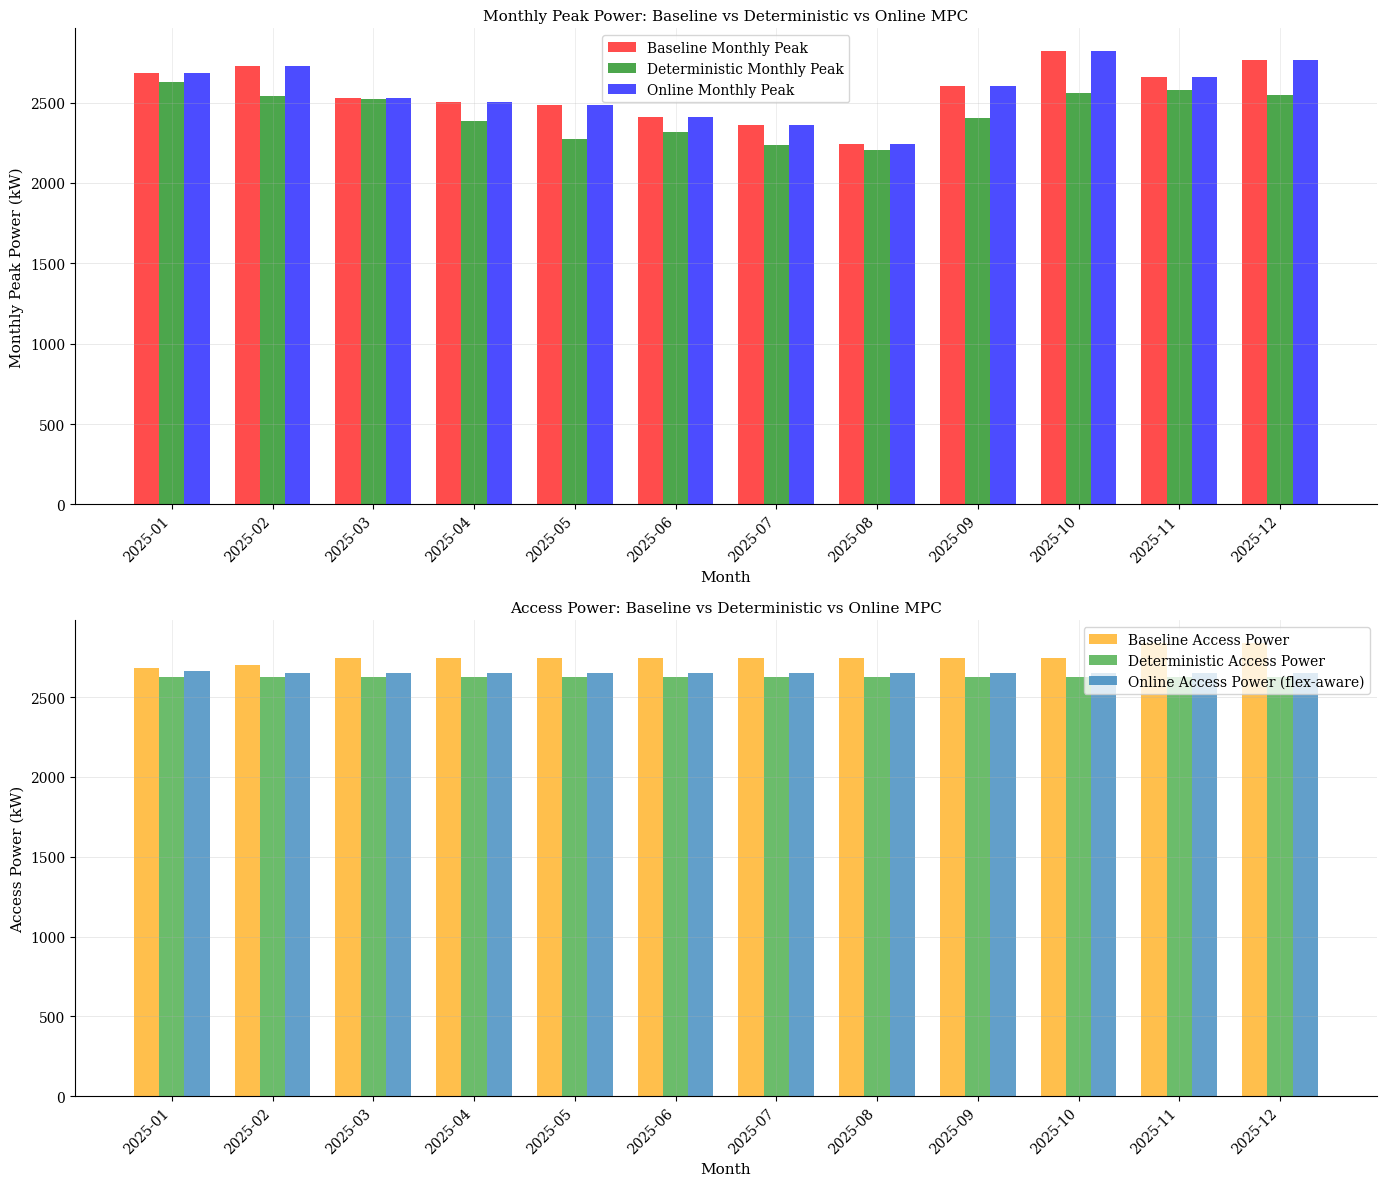


MONTHLY PEAK AND ACCESS POWER SUMMARY (BASELINE vs DETERMINISTIC vs ONLINE)
  month  baseline_peak_kw  deterministic_peak_kw  online_peak_kw  baseline_access_kw  deterministic_access_kw  online_access_kw  access_reduction_kw_det  access_reduction_kw_online
2025-01            2684.5            2629.500000          2684.5              2683.5                   2629.5            2662.5                     54.0                        21.0
2025-02            2726.5            2539.500000          2726.5              2704.5                   2629.5            2649.5                     75.0                        55.0
2025-03            2527.0            2520.000000          2527.0              2746.5                   2629.5            2649.5                    117.0                        97.0
2025-04            2506.0            2383.500000          2506.0              2746.5                   2629.5            2649.5                    117.0                        97.0
2025-05           

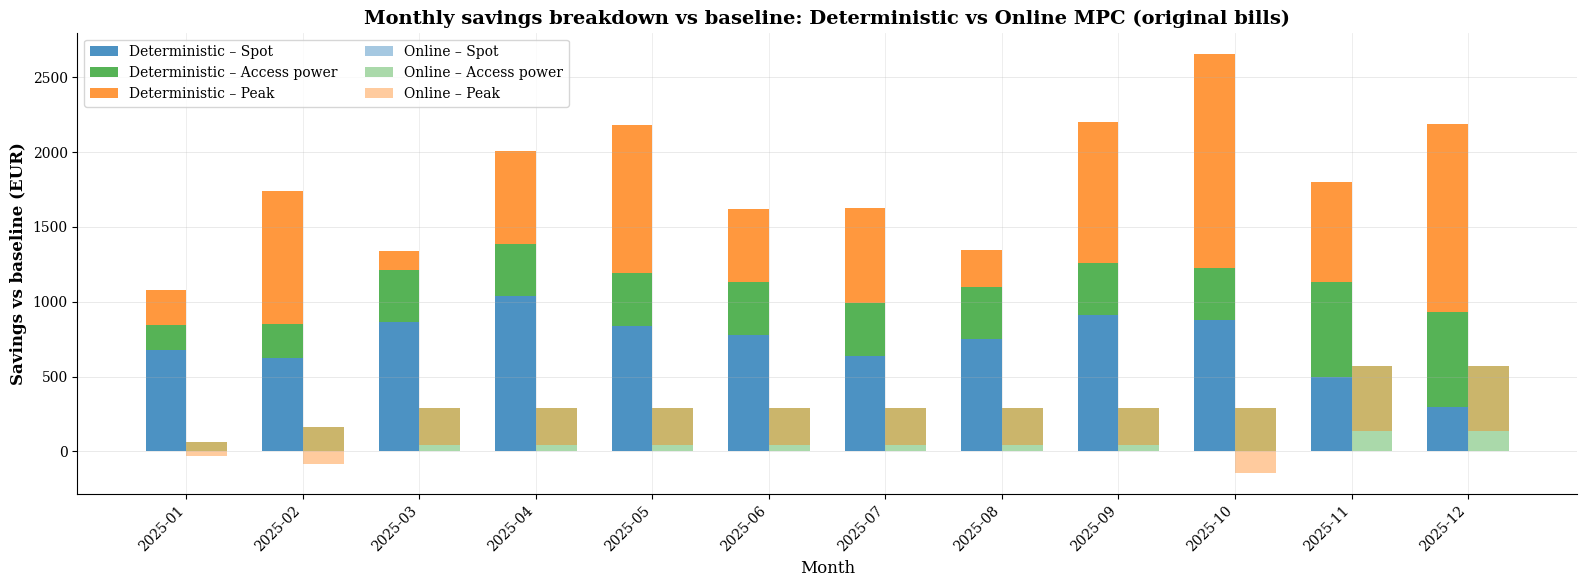


Savings breakdown (first rows):


,month,spot_savings_det,access_power_savings_det,peak_savings_det,total_savings_det,spot_savings_online,access_power_savings_online,peak_savings_online,total_savings_online
0,2025-01,681.098555,161.867473,236.978376,1079.944405,0.0,62.948462,-94.422693,-31.474231
1,2025-02,624.348567,224.815935,889.358007,1738.522509,0.0,164.865019,-247.297529,-82.432510
2,2025-03,862.173457,350.712859,128.507637,1341.393953,0.0,290.761943,-247.297529,43.464414
3,2025-04,1037.596388,350.712859,616.719958,2005.029205,0.0,290.761943,-247.297529,43.464414
4,2025-05,840.888055,350.712859,988.691250,2180.292163,0.0,290.761943,-247.297529,43.464414


In [10]:
# Shadow billing (fixed): baseline vs deterministic vs online MPC (costs from original online bills)

import pandas as pd
from pathlib import Path
import sys

# --- Standalone fallbacks (load from exports if not in memory) ---
PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

# 1) Deterministic monthly export from notebook 02
if "DET_EV_MONTHLY" not in globals():
    det_monthly_path = PROJECT_ROOT / "output" / "notebooks" / "deterministic_ev_monthly_notebook_02.csv"
    if not det_monthly_path.exists():
        raise FileNotFoundError(f"Deterministic monthly export not found: {det_monthly_path}")
    DET_EV_MONTHLY = pd.read_csv(det_monthly_path)
    if "month" in DET_EV_MONTHLY.columns:
        DET_EV_MONTHLY["month"] = pd.PeriodIndex(DET_EV_MONTHLY["month"], freq="M")

# 1b) Deterministic 15-min export from notebook 02 (used for yearly EV energy totals)
if "DET_EV_15MIN" not in globals():
    det_15min_path = PROJECT_ROOT / "output" / "notebooks" / "deterministic_ev_15min_notebook_02.csv"
    if not det_15min_path.exists():
        raise FileNotFoundError(f"Deterministic 15-min export not found: {det_15min_path}")
    DET_EV_15MIN = pd.read_csv(det_15min_path)

# 2) Online 15-min export from this notebook Part 2 (used to compute online bills)
if "results_df" in globals():
    _online_15min = results_df.copy()
elif "results_ev_online" in globals():
    _online_15min = results_ev_online.copy()
else:
    online_15min_path = PROJECT_ROOT / "output" / "notebooks" / "online_ev_15min_notebook_09.csv"
    if not online_15min_path.exists():
        raise FileNotFoundError(f"Online 15-min export not found: {online_15min_path}")
    _online_15min = pd.read_csv(online_15min_path)

# Make downstream code compatible with the original notebook variables
if "results_ev_online" not in globals():
    results_ev_online = _online_15min

# 3) Compute online bills/injection bills (summary_ev_online replacement)
if "summary_ev_online" not in globals():
    from billing import load_billing_config, calculate_monthly_bills, calculate_monthly_injection_bills

    billing_cfg_path = PROJECT_ROOT / "config" / "billing.yaml"
    billing_cfg = load_billing_config(str(billing_cfg_path))

    # Ensure required columns exist
    required_cols = {"timestamp", "grid_consumption", "price", "grid_injection"}
    missing_cols = sorted(list(required_cols - set(_online_15min.columns)))
    if missing_cols:
        raise KeyError(f"Online export missing required columns for billing: {missing_cols}")

    # Use the exported access power series if present (kW)
    access_col = "access_kw" if "access_kw" in _online_15min.columns else None
    online_bills = calculate_monthly_bills(
        _online_15min,
        billing_cfg,
        volume_col="grid_consumption",
        price_col="price",
        timestamp_col="timestamp",
        access_power_col=access_col,
    )
    online_inj = calculate_monthly_injection_bills(
        _online_15min,
        billing_cfg,
        injection_col="grid_injection",
        price_col="price",
        timestamp_col="timestamp",
    )

    summary_ev_online = {"bills": online_bills, "injection_bills": online_inj}

# 4) Require §1.2 `table` (both conservative and flex-aware rows)
if "table" not in globals():
    raise NameError(
        "Run §1.2 first to build `table` with access_power_conservative and access_power_flex_aware."
    )

# Use deterministic monthly export and original online MPC summary
required = ["DET_EV_MONTHLY", "summary_ev_online", "table"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(
        f"Missing objects {missing}. Please run deterministic export (notebook 02), the online MPC simulation, and Section 1 (access table) first. Missing: {missing}"
    )

monthly_det = DET_EV_MONTHLY.copy()
monthly_det["month_key"] = monthly_det["month"].astype(str)

online_bills_orig = summary_ev_online["bills"].copy()
online_injection_orig = summary_ev_online["injection_bills"].copy()

online_bills_orig["month_key"] = online_bills_orig["month"].astype(str)
online_injection_orig["month_key"] = online_injection_orig["month"].astype(str)

# Net monthly cost for online MPC (using ORIGINAL online bills)
online_net_orig = online_bills_orig[["month_key", "total_cost_eur"]].merge(
    online_injection_orig[["month_key", "injection_net_revenue_eur"]],
    on="month_key",
    how="left",
)
online_net_orig["online_net_cost_eur"] = (
    online_net_orig["total_cost_eur"]
    - online_net_orig["injection_net_revenue_eur"].fillna(0.0)
)

online_net_orig = online_net_orig.set_index("month_key")

# Assemble comparison table (shadow billing)
shadow = pd.DataFrame({"month_key": monthly_det["month_key"]}).set_index("month_key")

# From notebook 02 monthly export
shadow["baseline_net_cost_eur"] = monthly_det["baseline_net_cost_eur"].values
shadow["deterministic_net_cost_eur"] = monthly_det["optimized_net_cost_eur"].values
shadow["baseline_peak_kw"] = monthly_det["baseline_monthly_peak_kw"].values
shadow["deterministic_peak_kw"] = monthly_det["optimized_monthly_peak_kw"].values
shadow["baseline_access_kw"] = (
    table.loc["access_power_conservative"]
    .rename(index=lambda m: str(m))
    .reindex(shadow.index)
    .astype(float)
    .values
)
shadow["deterministic_access_kw"] = monthly_det["optimized_access_power_kw"].values
shadow["baseline_volume_mwh"] = monthly_det["baseline_volume_mwh"].values
shadow["deterministic_volume_mwh"] = monthly_det["optimized_volume_mwh"].values
shadow["ev_cost_baseline_eur"] = monthly_det["ev_cost_baseline_eur"].values
shadow["ev_cost_deterministic_eur"] = monthly_det["ev_cost_optimized_eur"].values

# Online MPC metrics: costs from original bills, access power from §1.2 flex-aware
shadow["online_net_cost_eur"] = online_net_orig.loc[shadow.index, "online_net_cost_eur"].values
shadow["online_peak_kw"] = online_bills_orig.set_index("month_key")["monthly_peak_kw"].reindex(shadow.index).values

shadow["online_access_kw"] = (
    table.loc["access_power_flex_aware"]
    .rename(index=lambda m: str(m))
    .reindex(shadow.index)
    .astype(float)
    .values
)

shadow["online_volume_mwh"] = online_bills_orig.set_index("month_key")["volume_mwh"].reindex(shadow.index).values

# Derived savings vs baseline (net costs)
shadow["deterministic_savings_eur"] = (
    shadow["baseline_net_cost_eur"] - shadow["deterministic_net_cost_eur"]
)
shadow["online_savings_eur"] = (
    shadow["baseline_net_cost_eur"] - shadow["online_net_cost_eur"]
)

# Expose as main shadow billing table
shadow_billing_08 = shadow.reset_index().rename(columns={"month_key": "month"})

print("Shadow billing monthly comparison (first rows)")
display(
    shadow_billing_08[
        [
            "month",
            "baseline_net_cost_eur",
            "deterministic_net_cost_eur",
            "online_net_cost_eur",
            "deterministic_savings_eur",
            "online_savings_eur",
        ]
    ].head()
)
# Component-wise cost comparison: Baseline vs Online MPC (like notebook 02)

import pandas as pd

# We need deterministic monthly export (baseline) and original online bills
required = ["DET_EV_MONTHLY", "summary_ev_online", "shadow_billing_08"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(
        f"Missing objects {missing}. Please run deterministic export (notebook 02), online MPC simulation, and shadow billing first. Missing: {missing}"
    )

monthly_det = DET_EV_MONTHLY.copy()
monthly_det["month_key"] = monthly_det["month"].astype(str)

online_bills_orig = summary_ev_online["bills"].copy()
online_injection_orig = summary_ev_online["injection_bills"].copy()

online_bills_orig["month_key"] = online_bills_orig["month"].astype(str)
online_injection_orig["month_key"] = online_injection_orig["month"].astype(str)

# Baseline totals from deterministic monthly export (already net of injection)
baseline_total = monthly_det["baseline_net_cost_eur"].sum()

# Online totals from original online bills + injection
online_net = online_bills_orig[["month_key", "total_cost_eur"]].merge(
    online_injection_orig[["month_key", "injection_net_revenue_eur"]],
    on="month_key",
    how="left",
)
online_net["online_net_cost_eur"] = (
    online_net["total_cost_eur"]
    - online_net["injection_net_revenue_eur"].fillna(0.0)
)
online_total = online_net["online_net_cost_eur"].sum()

# Component-wise sums
baseline_energy = monthly_det["baseline_energy_cost_eur"].sum()
online_energy = online_bills_orig["energy_cost_eur"].sum()

baseline_spot = monthly_det["baseline_spot_cost_eur"].sum()
online_spot = online_bills_orig["spot_cost_eur"].sum()

baseline_access = monthly_det["baseline_access_cost_eur"].sum()
online_access = online_bills_orig["access_cost_eur"].sum()

baseline_peak = (
    monthly_det["baseline_monthly_peak_cost_eur"].sum()
    + monthly_det["baseline_over_usage_cost_eur"].sum()
)
online_peak = (
    online_bills_orig["monthly_peak_cost_eur"].sum()
    + online_bills_orig["over_usage_cost_eur"].sum()
)

baseline_injection = monthly_det["baseline_injection_net_revenue_eur"].sum()
online_injection = online_injection_orig["injection_net_revenue_eur"].sum()

print("=" * 80)
print("COST COMPARISON: BASELINE vs DETERMINISTIC vs ONLINE MPC (ORIGINAL BILLS)")
print("=" * 80)
print(
    f"\n{'Cost Component':<30} "
    f"{'Baseline (EUR)':>20} {'Deterministic (EUR)':>20} {'Online (EUR)':>20} "
    f"{'Savings det (EUR)':>20} {'Savings online (EUR)':>22}"
)
print("-" * 122)

components = [
    (
        "Energy Cost",
        baseline_energy,
        monthly_det["optimized_energy_cost_eur"].sum(),
        online_energy,
    ),
    (
        "Spot Cost",
        baseline_spot,
        monthly_det["optimized_spot_cost_eur"].sum(),
        online_spot,
    ),
    (
        "Access Power Cost",
        baseline_access,
        monthly_det["optimized_access_cost_eur"].sum(),
        online_access,
    ),
    (
        "Monthly Peak Cost",
        monthly_det["baseline_monthly_peak_cost_eur"].sum(),
        monthly_det["optimized_monthly_peak_cost_eur"].sum(),
        online_bills_orig["monthly_peak_cost_eur"].sum(),
    ),
    (
        "Over-usage Cost",
        monthly_det["baseline_over_usage_cost_eur"].sum(),
        monthly_det["optimized_over_usage_cost_eur"].sum(),
        online_bills_orig["over_usage_cost_eur"].sum(),
    ),
    (
        "Injection Revenue",
        -baseline_injection,
        -monthly_det["optimized_injection_net_revenue_eur"].sum(),
        -online_injection,
    ),
]

for name, base_val, det_val, online_val in components:
    det_savings = base_val - det_val
    online_savings = base_val - online_val
    print(
        f"{name:<30} "
        f"{base_val:>20,.2f} {det_val:>20,.2f} {online_val:>20,.2f} "
        f"{det_savings:>20,.2f} {online_savings:>22,.2f}"
    )

print("-" * 122)
print(
    f"{'TOTAL COST':<30} "
    f"{baseline_total:>20,.2f} {monthly_det['optimized_net_cost_eur'].sum():>20,.2f} {online_total:>20,.2f} "
    f"{baseline_total - monthly_det['optimized_net_cost_eur'].sum():>20,.2f} "
    f"{baseline_total - online_total:>22,.2f}"
)
print("=" * 80)

savings_det_pct = (
    (baseline_total - monthly_det["optimized_net_cost_eur"].sum()) / baseline_total * 100
)
savings_online_pct = ((baseline_total - online_total) / baseline_total * 100)
print(
    f"\nTotal Savings vs Baseline — Deterministic: "
    f"{baseline_total - monthly_det['optimized_net_cost_eur'].sum():,.2f} EUR "
    f"({savings_det_pct:.2f}%)"
)
print(
    f"Total Savings vs Baseline — Online:       "
    f"{baseline_total - online_total:,.2f} EUR ({savings_online_pct:.2f}%)"
)

# Total EV demand from deterministic 15-min export (kWh -> MWh)
total_ev_demand_kwh = float(DET_EV_15MIN["ev_demand_actual"].sum())
total_ev_demand_mwh = total_ev_demand_kwh / 1000.0

# Deterministic MPC: charged EV energy (kWh -> MWh)
charged_det_kwh = float(DET_EV_15MIN["ev_charge"].sum())
charged_det_mwh = charged_det_kwh / 1000.0
unmet_det_mwh = max(total_ev_demand_mwh - charged_det_mwh, 0.0)

# Online MPC: charged EV energy (kWh -> MWh)
# Use the loaded export `_online_15min` (or fall back to in-memory results if present).
_online_src = None
if "_online_15min" in globals():
    _online_src = _online_15min
elif "results_df" in globals():
    _online_src = results_df
elif "results_ev_online" in globals():
    _online_src = results_ev_online
else:
    raise NameError("No online results found to compute charged energy.")

if "ev_online_mpc" not in _online_src.columns:
    raise KeyError("Online results must contain 'ev_online_mpc' column (kWh per 15-min step).")
charged_online_kwh = float(_online_src["ev_online_mpc"].sum())
charged_online_mwh = charged_online_kwh / 1000.0

uncharged_dict = summary_ev_online.get("uncharged_kwh_by_day", {})
if not isinstance(uncharged_dict, dict):
    raise TypeError("summary_ev_online['uncharged_kwh_by_day'] must be a dict day -> kWh.")
unmet_online_kwh = float(sum(max(v, 0.0) for v in uncharged_dict.values()))
unmet_online_mwh = unmet_online_kwh / 1000.0

# Baseline (uncontrolled): assume all EV demand is charged
charged_baseline_mwh = total_ev_demand_mwh
unmet_baseline_mwh = 0.0

print("\nEV ENERGY SUMMARY (2025) — demand, charged, unmet (MWh)")
print("=" * 80)
print(f"{'Scenario':<20} {'Demand (MWh)':>15} {'Charged (MWh)':>18} {'Unmet (MWh)':>15}")
print("-" * 80)
print(f"{'Baseline':<20} {total_ev_demand_mwh:>15,.2f} {charged_baseline_mwh:>18,.2f} {unmet_baseline_mwh:>15,.2f}")
print(f"{'Deterministic':<20} {total_ev_demand_mwh:>15,.2f} {charged_det_mwh:>18,.2f} {unmet_det_mwh:>15,.2f}")
print(f"{'Online MPC':<20} {total_ev_demand_mwh:>15,.2f} {charged_online_mwh:>18,.2f} {unmet_online_mwh:>15,.2f}")
print("=" * 80)
# Plot monthly access power comparison: baseline vs deterministic vs online (flex-aware kW)
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Monthly Peak Power (baseline vs deterministic vs online)
ax1 = axes[0]
x = range(len(monthly_det))
width = 0.25

ax1.bar([i - width for i in x], monthly_det["baseline_monthly_peak_kw"], width,
        label="Baseline Monthly Peak", color="red", alpha=0.7)
ax1.bar([i for i in x], monthly_det["optimized_monthly_peak_kw"], width,
        label="Deterministic Monthly Peak", color="green", alpha=0.7)
ax1.bar([i + width for i in x], shadow_billing_08["online_peak_kw"], width,
        label="Online Monthly Peak", color="blue", alpha=0.7)
ax1.set_xlabel("Month")
ax1.set_ylabel("Monthly Peak Power (kW)")
ax1.set_title("Monthly Peak Power: Baseline vs Deterministic vs Online MPC")
ax1.set_xticks(x)
ax1.set_xticklabels(monthly_det["month"].astype(str), rotation=45, ha="right")
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Plot 2: Access Power (baseline vs deterministic vs online flex-aware)
ax2 = axes[1]
ax2.bar([i - width for i in x], shadow_billing_08["baseline_access_kw"], width,
        label="Baseline Access Power", color="orange", alpha=0.7)
ax2.bar([i for i in x], monthly_det["optimized_access_power_kw"], width,
        label="Deterministic Access Power", color="tab:green", alpha=0.7)
ax2.bar([i + width for i in x], shadow_billing_08["online_access_kw"], width,
        label="Online Access Power (flex-aware)", color="tab:blue", alpha=0.7)
ax2.set_xlabel("Month")
ax2.set_ylabel("Access Power (kW)")
ax2.set_title("Access Power: Baseline vs Deterministic vs Online MPC")
ax2.set_xticks(x)
ax2.set_xticklabels(monthly_det["month"].astype(str), rotation=45, ha="right")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("MONTHLY PEAK AND ACCESS POWER SUMMARY (BASELINE vs DETERMINISTIC vs ONLINE)")
print("=" * 80)
comparison_df = pd.DataFrame({
    "month": monthly_det["month"].astype(str),
    "baseline_peak_kw": monthly_det["baseline_monthly_peak_kw"],
    "deterministic_peak_kw": monthly_det["optimized_monthly_peak_kw"],
    "online_peak_kw": shadow_billing_08["online_peak_kw"],
    "baseline_access_kw": shadow_billing_08["baseline_access_kw"],
    "deterministic_access_kw": monthly_det["optimized_access_power_kw"],
    "online_access_kw": shadow_billing_08["online_access_kw"],
})
comparison_df["access_reduction_kw_det"] = (
    comparison_df["baseline_access_kw"] - comparison_df["deterministic_access_kw"]
)
comparison_df["access_reduction_kw_online"] = (
    comparison_df["baseline_access_kw"] - comparison_df["online_access_kw"]
)
print(comparison_df.to_string(index=False))
print("=" * 80)

# EV yearly energy and unmet demand summary (2025)

import numpy as np

required = ["DET_EV_15MIN", "results_ev_online", "summary_ev_online"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(
        f"Missing objects {missing}. Please run deterministic notebook 02, the online MPC simulation, and exports first. Missing: {missing}"
    )


# Savings breakdown vs baseline (fixed): deterministic vs online (costs from original online bills)

import numpy as np

required = ["DET_EV_MONTHLY", "summary_ev_online"]
missing = [name for name in required if name not in globals()]
if missing:
    raise NameError(
        f"Missing objects {missing}. Please run deterministic export (notebook 02) and the online MPC simulation first. Missing: {missing}"
    )

monthly_det = DET_EV_MONTHLY.copy()
monthly_det["month_key"] = monthly_det["month"].astype(str)

online_bills_orig = summary_ev_online["bills"].copy()
online_bills_orig["month_key"] = online_bills_orig["month"].astype(str)

# Baseline vs deterministic savings (all from deterministic export)
base_spot = monthly_det["baseline_spot_cost_eur"]
opt_spot = monthly_det["optimized_spot_cost_eur"]

base_access = monthly_det["baseline_access_cost_eur"]
opt_access = monthly_det["optimized_access_cost_eur"]

base_peak = monthly_det["baseline_monthly_peak_cost_eur"] + monthly_det["baseline_over_usage_cost_eur"]
opt_peak = monthly_det["optimized_monthly_peak_cost_eur"] + monthly_det["optimized_over_usage_cost_eur"]

spot_savings_det = base_spot - opt_spot
access_savings_det = base_access - opt_access
peak_savings_det = base_peak - opt_peak

# Baseline vs online savings using ORIGINAL online bills
base_spot_online = base_spot
base_access_online = base_access
base_peak_online = base_peak

online_idx = online_bills_orig.set_index("month_key")
spot_online = online_idx.loc[monthly_det["month_key"], "spot_cost_eur"].values
access_online = online_idx.loc[monthly_det["month_key"], "access_cost_eur"].values
peak_online = (
    online_idx.loc[monthly_det["month_key"], "monthly_peak_cost_eur"].values
    + online_idx.loc[monthly_det["month_key"], "over_usage_cost_eur"].values
)

spot_savings_online = base_spot_online.values - spot_online
access_savings_online = base_access_online.values - access_online
peak_savings_online = base_peak_online.values - peak_online

# Assemble combined savings table
savings_dual = pd.DataFrame({
    "month": monthly_det["month"],
    "month_key": monthly_det["month_key"],
    # deterministic vs baseline
    "spot_savings_det": spot_savings_det,
    "access_power_savings_det": access_savings_det,
    "peak_savings_det": peak_savings_det,
    # online vs baseline
    "spot_savings_online": spot_savings_online,
    "access_power_savings_online": access_savings_online,
    "peak_savings_online": peak_savings_online,
})

savings_dual["total_savings_det"] = (
    savings_dual["spot_savings_det"]
    + savings_dual["access_power_savings_det"]
    + savings_dual["peak_savings_det"]
)

savings_dual["total_savings_online"] = (
    savings_dual["spot_savings_online"]
    + savings_dual["access_power_savings_online"]
    + savings_dual["peak_savings_online"]
)

# --- Stacked bar plot: deterministic vs online (both vs baseline) ---

x = np.arange(len(savings_dual))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))

# Deterministic MPC savings (left stack per month)
ax.bar(
    x - width / 2,
    savings_dual["spot_savings_det"],
    width,
    label="Deterministic – Spot",
    color="tab:blue",
    alpha=0.8,
)
ax.bar(
    x - width / 2,
    savings_dual["access_power_savings_det"],
    width,
    bottom=savings_dual["spot_savings_det"],
    label="Deterministic – Access power",
    color="tab:green",
    alpha=0.8,
)
ax.bar(
    x - width / 2,
    savings_dual["peak_savings_det"],
    width,
    bottom=(
        savings_dual["spot_savings_det"]
        + savings_dual["access_power_savings_det"]
    ),
    label="Deterministic – Peak",
    color="tab:orange",
    alpha=0.8,
)

# Online MPC savings (right stack per month)
ax.bar(
    x + width / 2,
    savings_dual["spot_savings_online"],
    width,
    label="Online – Spot",
    color="tab:blue",
    alpha=0.4,
)
ax.bar(
    x + width / 2,
    savings_dual["access_power_savings_online"],
    width,
    bottom=savings_dual["spot_savings_online"],
    label="Online – Access power",
    color="tab:green",
    alpha=0.4,
)
ax.bar(
    x + width / 2,
    savings_dual["peak_savings_online"],
    width,
    bottom=(
        savings_dual["spot_savings_online"]
        + savings_dual["access_power_savings_online"]
    ),
    label="Online – Peak",
    color="tab:orange",
    alpha=0.4,
)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Savings vs baseline (EUR)", fontsize=12, fontweight="bold")
ax.set_title(
    "Monthly savings breakdown vs baseline: Deterministic vs Online MPC (original bills)",
    fontsize=14,
    fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(savings_dual["month"].astype(str), rotation=45, ha="right")
ax.legend(loc="upper left", ncol=2)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\nSavings breakdown (first rows):")
cols_show = [
    "month",
    "spot_savings_det",
    "access_power_savings_det",
    "peak_savings_det",
    "total_savings_det",
    "spot_savings_online",
    "access_power_savings_online",
    "peak_savings_online",
    "total_savings_online",
]
display(savings_dual[cols_show].head())

## 4. Slack sensitivity

Sensitivity of **deadline slack** (minutes before 17:00) on uncontrolled vs online EV delivery and costs. Uses the same **`ENFORCE_DAILY_EV_DEMAND`** safeguard as Part 2 (config in §4.1).

| Part | Purpose | Access power |
|------|---------|----------------|
| **4.1** | Run online MPC for each slack value | §1.2 **flex-aware** (`ACCESS_POWER_ONLINE_MONTHLY`) |
| **4.2** | Thesis plots: unmet MWh vs slack; online savings vs baseline | — |
| **4.3** | One slack: recreate Part 3.1 + 3.2 plots | Shadow AP: conservative baseline, flex online |
| **4.4** | Stacked savings vs slack (baseline re-bill) | Baseline: §1.2 **conservative**; online: `access_kw` from slack export (flex) |

**Run order:** §1.2 → Part 4.1 (long) → 4.2–4.4. Part 4.3 requires §1.2 `table` with both access rows (do not rebuild `table` from bills only).


In [ ]:
# Part 4.1 — Slack sensitivity run (includes strategy selection + access power mapping)
from pathlib import Path
import sys

# --- paths / imports ---
PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from online_MPC_1_EV_slack_sensitivity import run_online_mpc_slack_sensitivity

# --- 4.1A Strategy selection (edit these) ---
EV_FORECAST_STRATEGY = "c_p90"        # uses column like forecast_ev_a
INFLEX_FORECAST_STRATEGY = "c"    # uses column like forecast_inflex_a
PV_FORECAST_STRATEGY = "chronos2_elia_p50"  # "actual", "k1".. "k10"

# --- 4.1B Slack sweep settings ---
SLACKS_MIN = range(0, 181, 15)  # 0..210 inclusive, step 15

# Daily EV demand safeguard (same as Part 2; catch-up enforce when slack > 0)
ENFORCE_DAILY_EV_DEMAND = True

# --- 4.1C Monthly access power (kW): online MPC uses §1.2 flex-aware ---
if "table" not in globals():
    raise NameError("`table` not found. Run §1.2 first.")
if "ACCESS_POWER_ONLINE_MONTHLY" not in globals():
    ACCESS_POWER_ONLINE_MONTHLY = table.loc["access_power_flex_aware"].copy()
    ACCESS_POWER_ONLINE_MONTHLY.index = ACCESS_POWER_ONLINE_MONTHLY.index.astype(str)
ACCESS_POWER_DICT = {str(k): float(v) for k, v in ACCESS_POWER_ONLINE_MONTHLY.items()}

# --- 4.1D Run sensitivity sweep ---
outs = run_online_mpc_slack_sensitivity(
    slacks_min=SLACKS_MIN,
    forecast_strategy_ev=EV_FORECAST_STRATEGY,
    forecast_strategy_inflex=INFLEX_FORECAST_STRATEGY,
    forecast_strategy_pv=PV_FORECAST_STRATEGY,
    enforce_daily_ev_demand=ENFORCE_DAILY_EV_DEMAND,
    access_power_by_month=ACCESS_POWER_DICT,
    per_slack_save=True,  # writes per-slack 15-min + debug CSVs
    # optional (defaults shown):
    # per_slack_15min_stem="online_ev_15min_notebook_09",
    # per_slack_debug_stem="online_ev_mpc_debug_notebook_09",
    verbose=True,
)
print("\nSensitivity outputs (aggregates):")
print("- combined 15-min results:", outs.results_15min_path)
print("- per-slack summary:", outs.summary_path)
print("\nPer-slack files are saved as:")
print("- output/notebooks/online_ev_15min_notebook_09_<xx>_min_slack.csv")
print("- output/notebooks/online_ev_mpc_debug_notebook_09_<xx>_min_slack.csv")

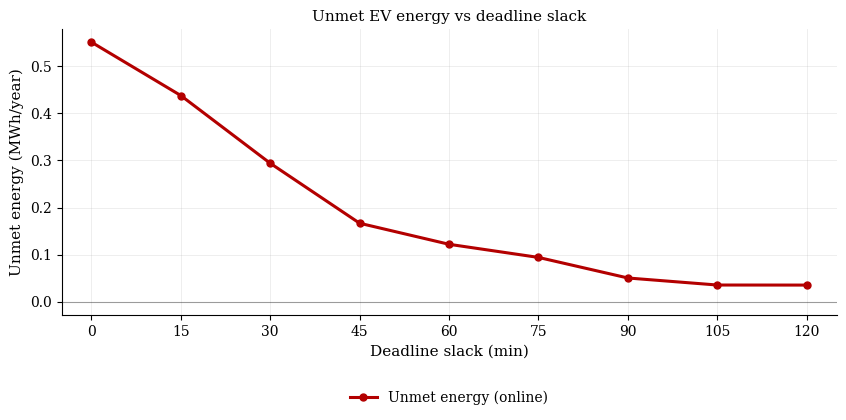

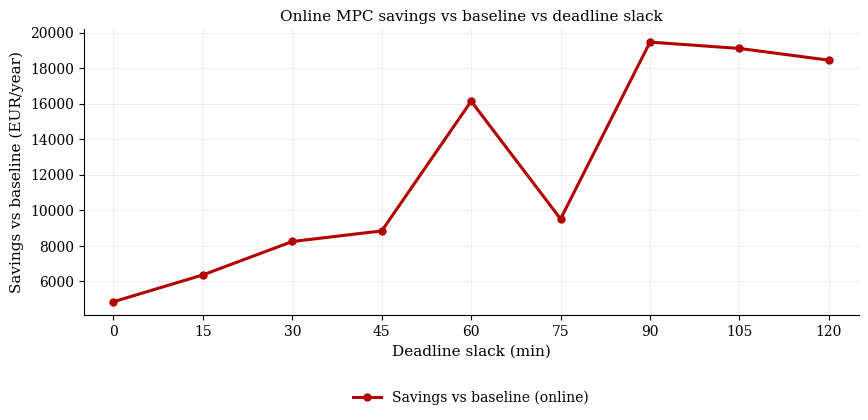

,slack_min,enforce_daily_ev_demand,unmet_mwh,online_net_cost_eur,baseline_net_cost_eur,online_savings_vs_baseline_eur,ev_enforce_steps,ev_enforce_extra_kwh_total
0,0.0,True,0.551380,1.676900e+06,1.681751e+06,4851.564769,26,594.718893
1,15.0,True,0.437945,1.675389e+06,1.681751e+06,6362.310111,25,531.987458
2,30.0,True,0.294122,1.673509e+06,1.681751e+06,8242.654767,20,440.040534
3,45.0,True,0.166715,1.672912e+06,1.681751e+06,8839.026071,13,313.066881
4,60.0,True,0.122001,1.665610e+06,1.681751e+06,16141.284673,9,205.247245
5,75.0,True,0.094125,1.672239e+06,1.681751e+06,9511.858640,5,128.349989
6,90.0,True,0.050438,1.662284e+06,1.681751e+06,19466.970441,2,26.899775
7,105.0,True,0.035500,1.662642e+06,1.681751e+06,19109.626156,0,0.000000
8,120.0,True,0.035375,1.663302e+06,1.681751e+06,18449.136275,0,0.000000


In [44]:
# Part 4.2 — thesis-style slack plots (inline)

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
summary_path = PROJECT_ROOT / "output" / "notebooks" / "online_ev_slack_sensitivity_summary_notebook_09.csv"
if not summary_path.exists():
    raise FileNotFoundError(f"Run Part 4.1 first. Missing: {summary_path}")

sens = pd.read_csv(summary_path).sort_values("slack_min").reset_index(drop=True)

THESIS_STYLE = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}
C_KUL_RED = "#b30000"
C_BLACK = "#000000"
mpl.rcParams.update(THESIS_STYLE)


def _plot_slack(ax, x, y, *, title, ylabel, legend_label):
    ax.set_axisbelow(True)
    ax.plot(
        x, y,
        color=C_KUL_RED,
        linewidth=2.2,
        linestyle="-",
        marker="o",
        markersize=5,
        label=legend_label,
    )
    ticks = sorted(pd.to_numeric(x, errors="coerce").dropna().unique())
    ax.set_xticks(ticks)
    ax.set_xlim(min(ticks) - 5, max(ticks) + 5)
    ax.set_xlabel("Deadline slack (min)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    h, lab = ax.get_legend_handles_labels()
    ax.legend(h, lab, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=1, frameon=False)


slack = sens["slack_min"]

fig1, ax1 = plt.subplots(figsize=(10, 4.2))
_plot_slack(
    ax1, slack, sens["unmet_mwh"],
    title="Unmet EV energy vs deadline slack",
    ylabel="Unmet energy (MWh/year)",
    legend_label="Unmet energy (online)",
)
ax1.axhline(0.0, color=C_BLACK, linewidth=0.8, alpha=0.35)
fig1.subplots_adjust(bottom=0.22, top=0.90)
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 4.2))
_plot_slack(
    ax2, slack, sens["online_savings_vs_baseline_eur"],
    title="Online MPC savings vs baseline vs deadline slack",
    ylabel="Savings vs baseline (EUR/year)",
    legend_label="Savings vs baseline (online)",
)
fig2.subplots_adjust(bottom=0.22, top=0.90)
plt.show()

display(sens)

[Part 4.3] Using slack_min=90 | dt=0.250 h
Top 5 highest grid_consumption peaks (online MPC, kW):


,timestamp,grid_consumption_kw
0,2025-10-24 11:00:00,2821.0
1,2025-10-24 11:30:00,2800.0
2,2025-12-15 09:15:00,2765.0
3,2025-10-24 11:15:00,2730.0
4,2025-02-11 08:45:00,2726.5


Visualizing week 3: 2025-01-20 to 2025-01-27
Selected day 1: 2025-01-20


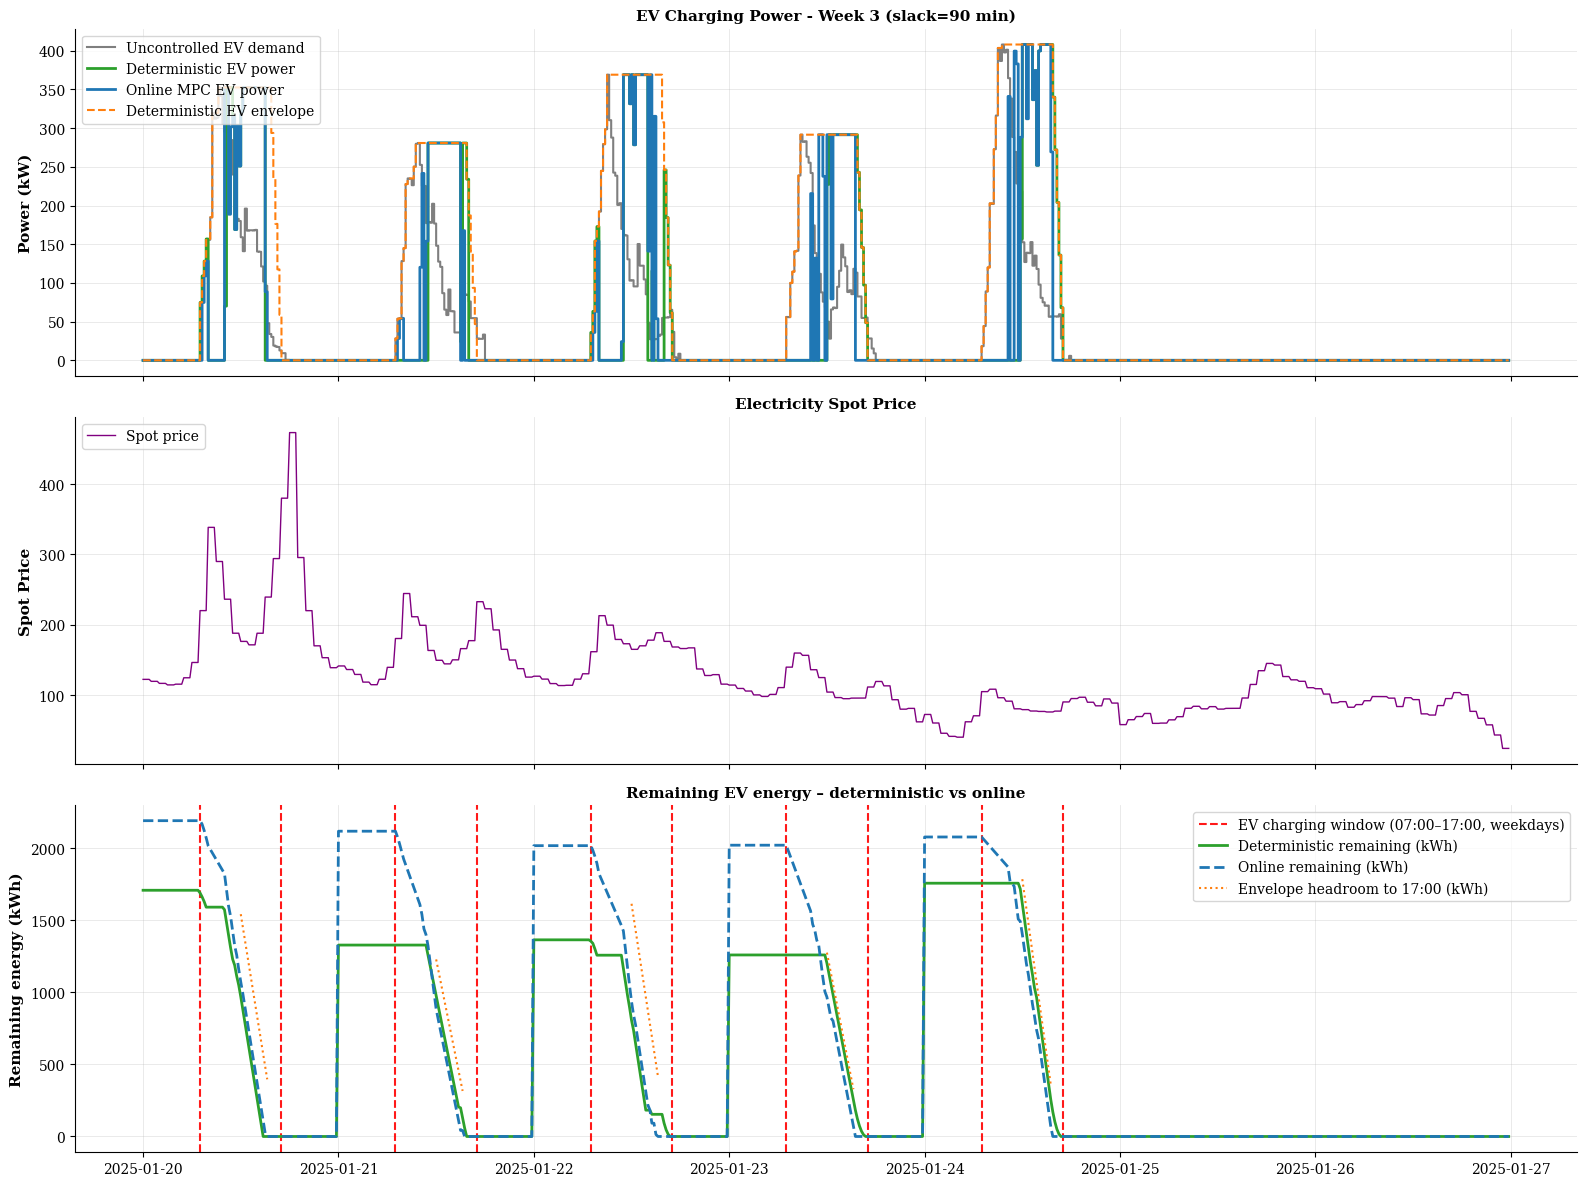

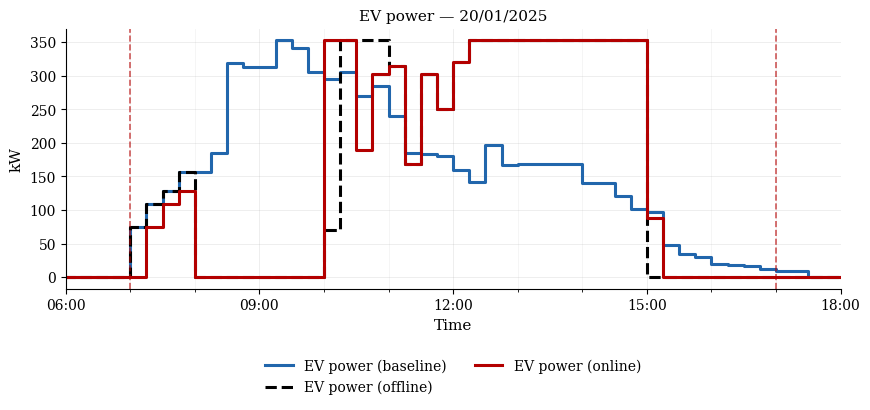

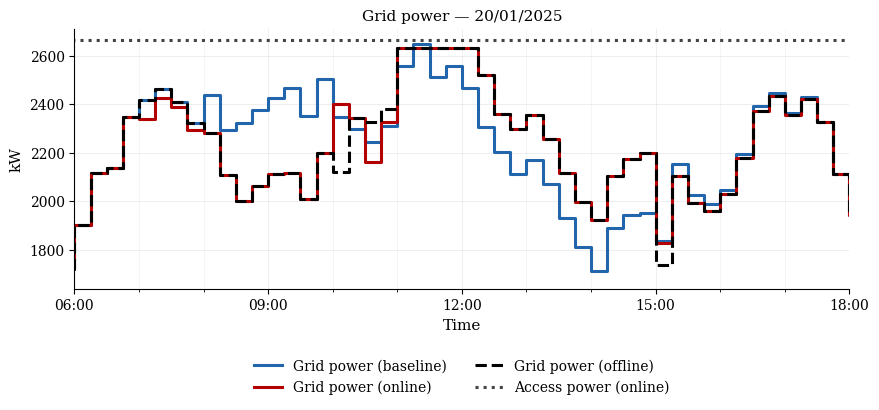

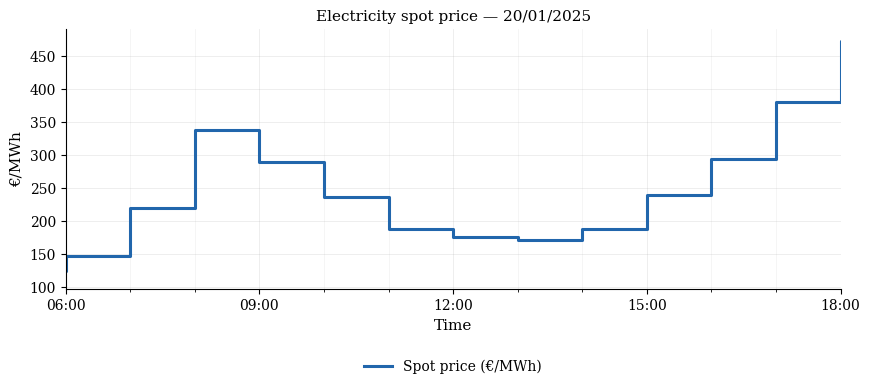

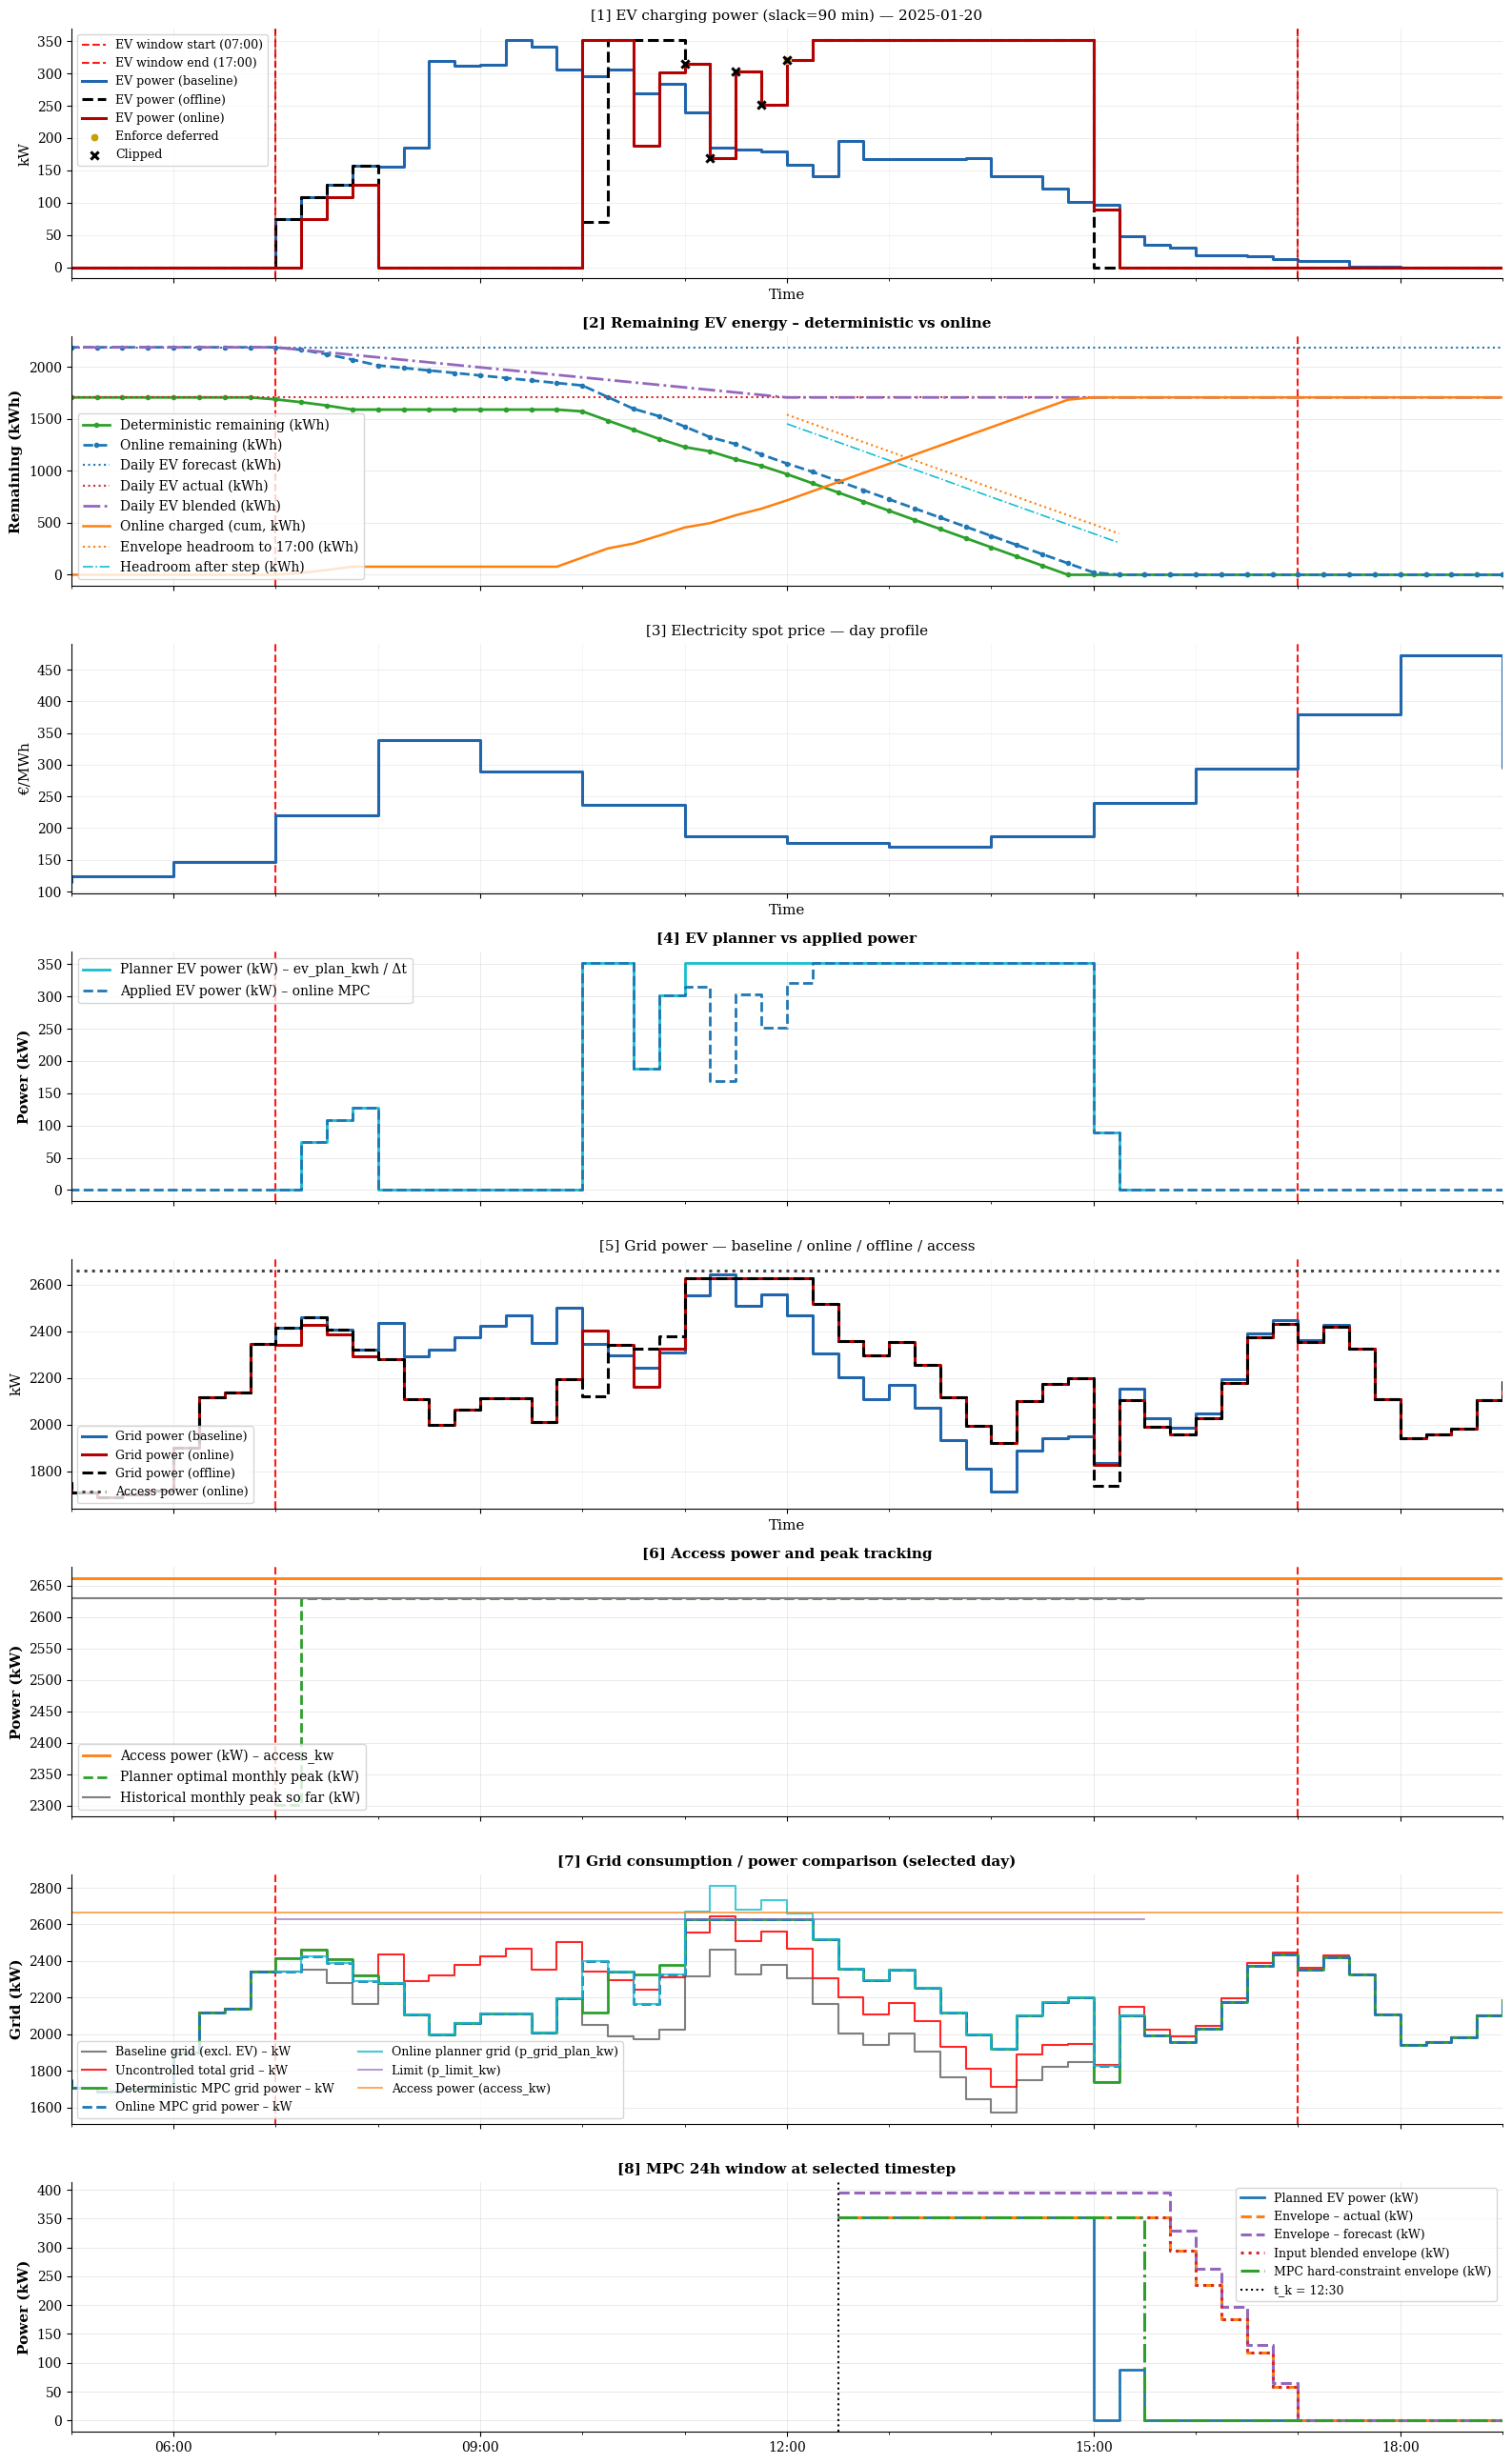

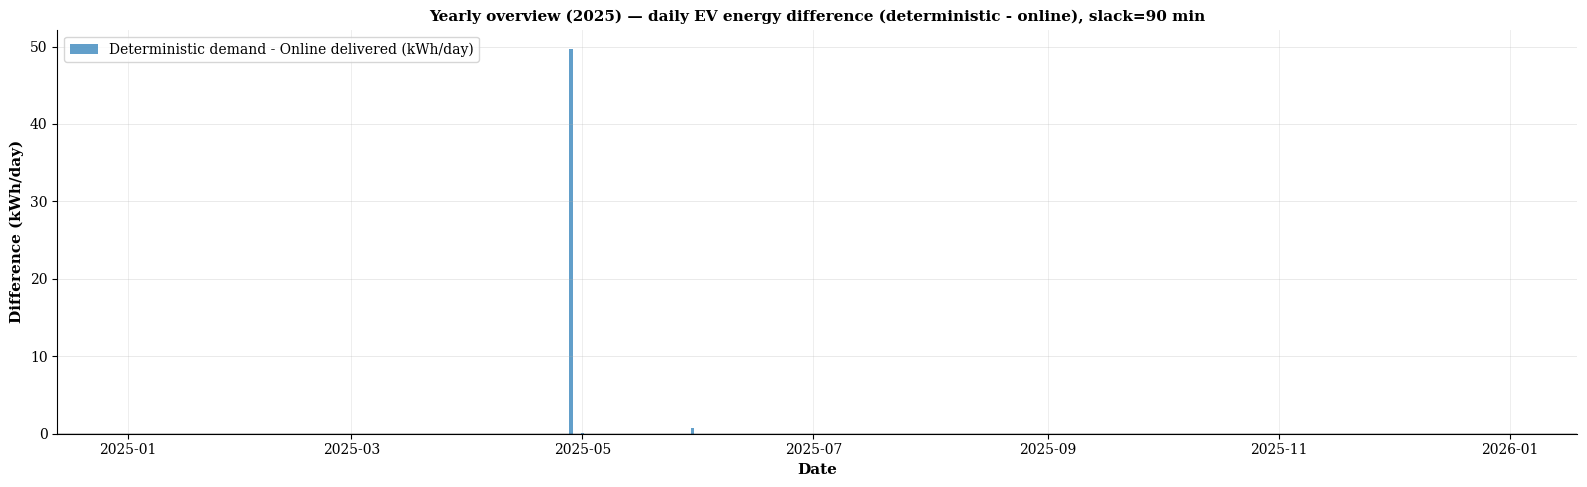

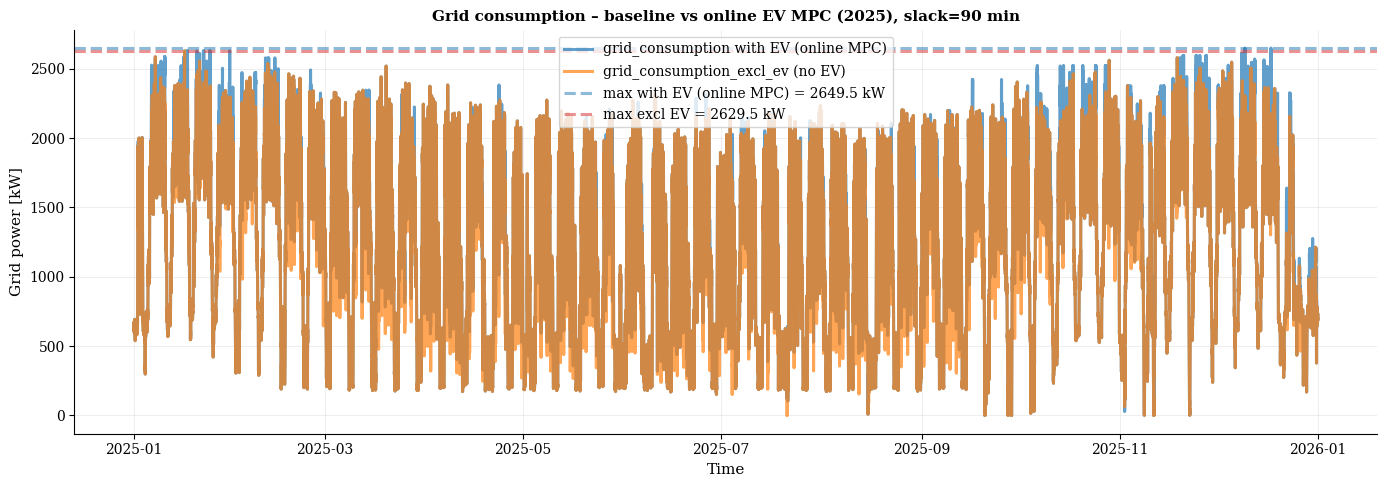

Shadow billing monthly comparison (first rows)


,month,baseline_net_cost_eur,deterministic_net_cost_eur,online_net_cost_eur,deterministic_savings_eur,online_savings_eur
0,2025-01,198817.187903,197725.324273,197882.302501,1091.863630,934.885402
1,2025-02,193918.029264,192168.580655,192466.050959,1749.448609,1451.978305
2,2025-03,157138.204053,155781.722065,155907.436550,1356.481988,1230.767503
3,2025-04,124865.912955,122842.725813,123044.654864,2023.187141,1821.258090
4,2025-05,106408.259216,104213.251512,104376.816998,2195.007704,2031.442218


COST COMPARISON (slack=90 min): BASELINE vs DETERMINISTIC vs ONLINE (recomputed)

Cost Component                       Baseline (EUR)  Deterministic (EUR)         Online (EUR)    Savings det (EUR)   Savings online (EUR)
--------------------------------------------------------------------------------------------------------------------------
Energy Cost                              375,450.30           375,295.02           375,348.53               155.28                 101.77
Spot Cost                              1,075,304.89         1,066,502.39         1,067,481.74             8,802.50               7,823.15
Access Power Cost                         99,044.91            94,584.56            95,342.94             4,460.35               3,701.97
Monthly Peak Cost                        130,160.36           123,433.87           124,172.59             6,726.49               5,987.78
Over-usage Cost                            1,800.78                 0.00                 0.00            

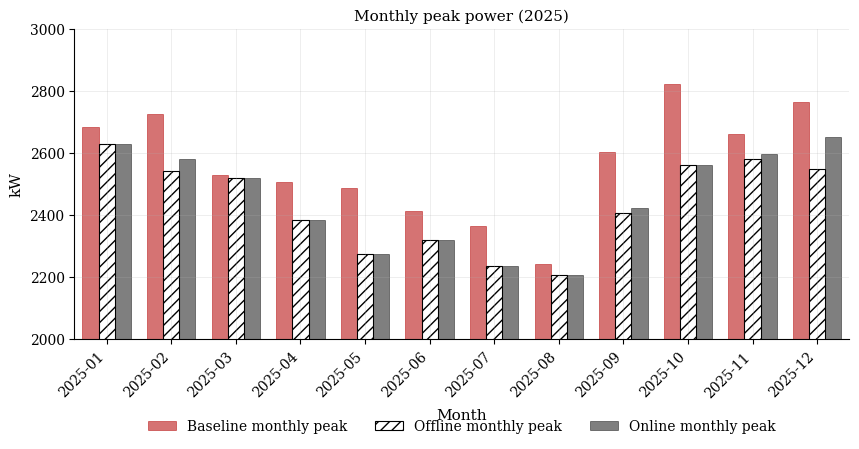

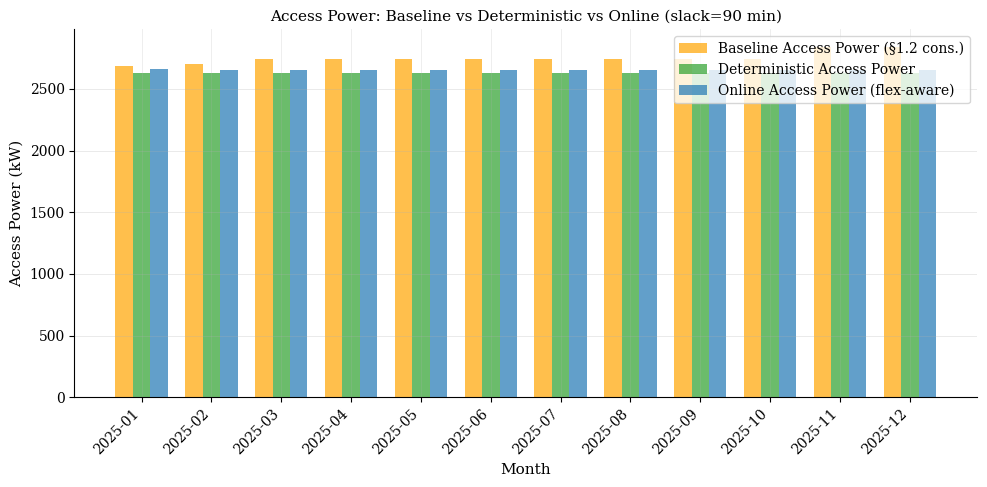

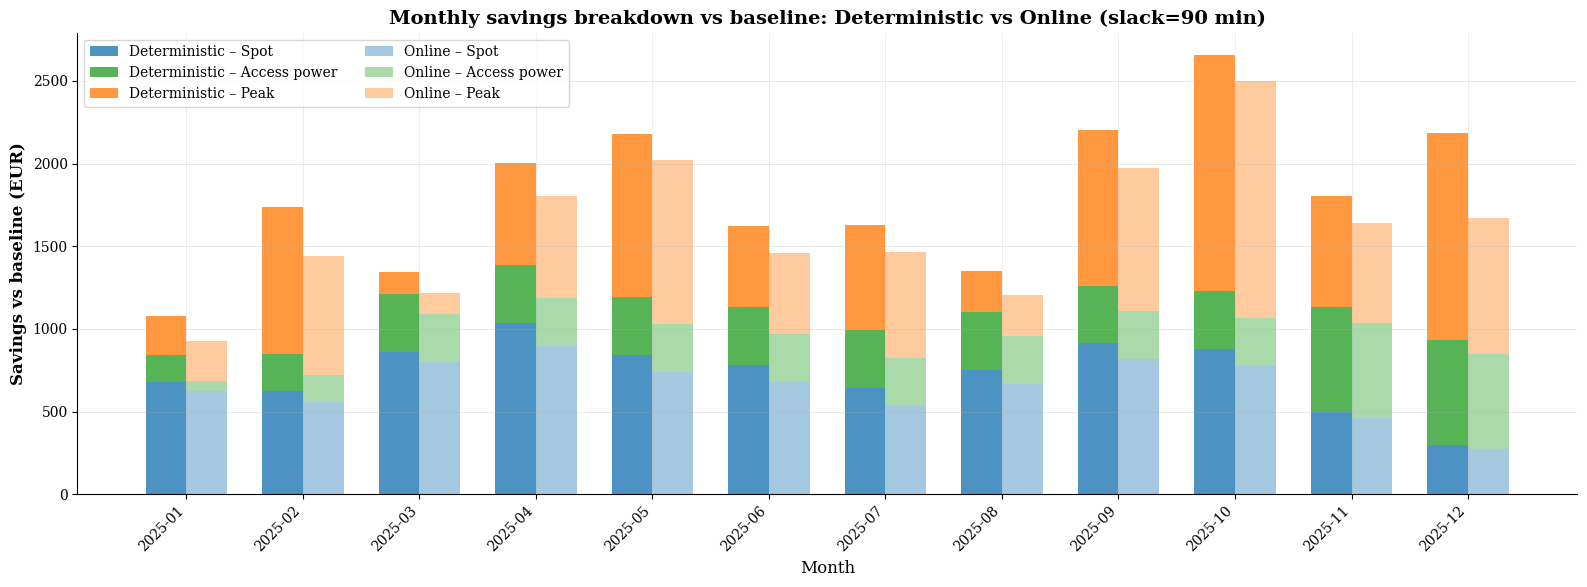


Savings breakdown (first rows):


,month,spot_savings_det,access_power_savings_det,peak_savings_det,total_savings_det,spot_savings_online,access_power_savings_online,peak_savings_online,total_savings_online
0,2025-01,681.098555,161.867473,236.978376,1079.944405,624.037901,62.948462,236.978376,923.964739
1,2025-02,624.348567,224.815935,889.358007,1738.522509,555.007042,164.865019,722.393620,1442.265682
2,2025-03,862.173457,350.712859,128.507637,1341.393953,797.540957,290.761943,128.507637,1216.810536
3,2025-04,1037.596388,350.712859,616.719958,2005.029205,896.556557,290.761943,616.719958,1804.038458
4,2025-05,840.888055,350.712859,988.691250,2180.292163,739.032858,290.761943,988.691250,2018.486050


In [11]:
# Part 4.3 — One-cell “all plots” for a selected slack (recreates 3.1 + 3.2 outputs)

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Settings (edit these)
# -----------------------
SLACK_SELECT_MIN = 90          # 0..90 step 15
WEEK_NUMBER = 3               # (1..52), weeks starting Monday
day_of_week = 1               # 1..7 (day inside the selected week)
MPC_HOUR = 12                  # for the MPC window plot
MPC_MINUTE = 30

# -----------------------
# Paths / imports
# -----------------------
PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
from billing import load_billing_config, calculate_monthly_bills, calculate_monthly_injection_bills
# Per-slack exports from slack sensitivity (recommended)
online_15min_path = (
    PROJECT_ROOT
    / "output"
    / "notebooks"
    / f"online_ev_15min_notebook_09_{int(SLACK_SELECT_MIN)}_min_slack.csv"
)
debug_csv_path = (
    PROJECT_ROOT
    / "output"
    / "notebooks"
    / f"online_ev_mpc_debug_notebook_09_{int(SLACK_SELECT_MIN)}_min_slack.csv"
)
# Deterministic exports (unchanged)
det_15min_path = PROJECT_ROOT / "output" / "notebooks" / "deterministic_ev_15min_notebook_02.csv"
det_monthly_path = PROJECT_ROOT / "output" / "notebooks" / "deterministic_ev_monthly_notebook_02.csv"
billing_cfg_path = PROJECT_ROOT / "config" / "billing.yaml"
for p in [online_15min_path, debug_csv_path, det_15min_path, det_monthly_path, billing_cfg_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

# -----------------------
# Load selected slack results (15-min)
# -----------------------
combined_path = PROJECT_ROOT / "output" / "notebooks" / "online_ev_15min_notebook_09_slack_sensitivity.csv"
_all = pd.read_csv(combined_path)
if "slack_min" not in _all.columns:
    raise KeyError(f"Combined CSV missing 'slack_min': {combined_path}")

results_df = _all[_all["slack_min"].astype(int) == int(SLACK_SELECT_MIN)].copy()
if results_df.empty:
    raise ValueError(
        f"No rows for slack_min={SLACK_SELECT_MIN}. Available: {sorted(_all['slack_min'].unique())}"
    )

results_df["timestamp"] = pd.to_datetime(results_df["timestamp"], errors="raise")
results_df = results_df.sort_values("timestamp").reset_index(drop=True)

_diag_cols = ["was_clipped", "ev_enforce_deferred", "ev_envelope_headroom_after_kwh"]
_missing_diag = [c for c in _diag_cols if c not in results_df.columns]
if _missing_diag:
    raise KeyError(
        f"Slack results missing columns {_missing_diag}. "
        "Re-run Part 4.1 (sensitivity) after updating src/online_MPC_1_EV.py."
    )

# -----------------------
# Load deterministic exports
# -----------------------
DET_EV_15MIN = pd.read_csv(det_15min_path)
DET_EV_15MIN["timestamp"] = pd.to_datetime(DET_EV_15MIN["timestamp"], errors="raise")
DET_EV_15MIN = DET_EV_15MIN.sort_values("timestamp").reset_index(drop=True)

DET_EV_MONTHLY = pd.read_csv(det_monthly_path)
if "month" in DET_EV_MONTHLY.columns:
    DET_EV_MONTHLY["month"] = pd.PeriodIndex(DET_EV_MONTHLY["month"], freq="M")

# -----------------------
# Derived columns for 3.1 plots
# -----------------------
_dt_hours = results_df["timestamp"].diff().dt.total_seconds().median() / 3600.0
if not np.isfinite(_dt_hours) or _dt_hours <= 0:
    raise ValueError("Failed to infer timestep from results_df timestamps.")

# Online EV power in kW (15-min kWh -> kW)
if "ev_online_mpc" not in results_df.columns:
    raise KeyError("Online results must contain 'ev_online_mpc' (kWh per 15-min).")
results_df["ev_power_kw_online"] = results_df["ev_online_mpc"] / float(_dt_hours)

# -----------------------
# 3.1 — Volumes plots (weekly, daily, MPC window, yearly)
# -----------------------
print(f"[Part 4.3] Using slack_min={SLACK_SELECT_MIN} | dt={_dt_hours:.3f} h")

# --- Top 5 highest grid_consumption peaks (online MPC, kW) ---
if "grid_consumption" in results_df.columns:
    _peaks = results_df[["timestamp", "grid_consumption"]].copy()
    _peaks["grid_consumption_kw"] = pd.to_numeric(_peaks["grid_consumption"], errors="coerce") * 4.0
    top5_peaks_online = (
        _peaks.dropna(subset=["grid_consumption_kw"])
        .sort_values("grid_consumption_kw", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )
    print("Top 5 highest grid_consumption peaks (online MPC, kW):")
    display(top5_peaks_online[["timestamp", "grid_consumption_kw"]])
else:
    print("Column 'grid_consumption' not found in online results; cannot compute peaks.")

# --- Week/day selection ---
year_start = pd.Timestamp("2025-01-01 00:00:00")
first_monday = year_start
while first_monday.weekday() != 0:
    first_monday += pd.Timedelta(days=1)

start_week = first_monday + pd.Timedelta(days=(WEEK_NUMBER - 1) * 7)
end_week = start_week + pd.Timedelta(days=7)

selected_day_start = start_week + pd.Timedelta(days=int(day_of_week) - 1)
selected_day_end = selected_day_start + pd.Timedelta(days=1)

print(f"Visualizing week {WEEK_NUMBER}: {start_week:%Y-%m-%d} to {end_week:%Y-%m-%d}")
print(f"Selected day {day_of_week}: {selected_day_start:%Y-%m-%d}")

week_data = results_df[(results_df["timestamp"] >= start_week) & (results_df["timestamp"] < end_week)].copy()
week_det = DET_EV_15MIN[(DET_EV_15MIN["timestamp"] >= start_week) & (DET_EV_15MIN["timestamp"] < end_week)].copy()

# Deterministic remaining energy per time step (kWh)
week_det["date"] = week_det["timestamp"].dt.date
daily_det_demand = week_det.groupby("date")["ev_demand_actual"].transform("sum")
week_det["det_charged_cum_kwh"] = week_det.groupby("date")["ev_charge"].cumsum()
week_det["det_remaining_kwh"] = daily_det_demand - week_det["det_charged_cum_kwh"]

_week_merge = week_data.merge(
    week_det[
        ["timestamp", "ev_demand_actual", "ev_charge_power", "ev_power_envelope", "det_remaining_kwh"]
    ],
    on="timestamp",
    how="left",
)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

ax1.step(_week_merge["timestamp"], _week_merge["ev_demand_actual"] * 4.0, label="Uncontrolled EV demand",
         color="tab:gray", linewidth=1.5, where="post")
ax1.step(_week_merge["timestamp"], _week_merge["ev_charge_power"], label="Deterministic EV power",
         color="tab:green", linewidth=2, where="post")
ax1.step(_week_merge["timestamp"], _week_merge["ev_power_kw_online"], label="Online MPC EV power",
         color="tab:blue", linewidth=2, where="post")
ax1.step(_week_merge["timestamp"], _week_merge["ev_power_envelope"], label="Deterministic EV envelope",
         color="tab:orange", linewidth=1.5, linestyle="--", where="post")
ax1.set_ylabel("Power (kW)", fontweight="bold")
ax1.set_title(f"EV Charging Power - Week {WEEK_NUMBER} (slack={SLACK_SELECT_MIN} min)", fontweight="bold")

ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2.plot(_week_merge["timestamp"], _week_merge["price"], label="Spot price", color="purple", linewidth=1)
ax2.set_ylabel("Spot Price", fontweight="bold")
ax2.set_title("Electricity Spot Price", fontweight="bold")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

# Remaining EV energy, with EV window markers
first_label = True
for d in pd.date_range(start_week, end_week - pd.Timedelta(days=1), freq="D"):
    if d.weekday() < 5:
        start_block = d.replace(hour=7, minute=0, second=0)
        end_block = d.replace(hour=17, minute=0, second=0)
        label = "EV charging window (07:00–17:00, weekdays)" if first_label else None
        first_label = False
        ax3.axvline(start_block, color="red", linestyle="--", linewidth=1.5, alpha=0.9, label=label)
        ax3.axvline(end_block, color="red", linestyle="--", linewidth=1.5, alpha=0.9)

ax3.plot(_week_merge["timestamp"], _week_merge["det_remaining_kwh"], label="Deterministic remaining (kWh)",
         color="tab:green", linewidth=2)
ax3.plot(_week_merge["timestamp"], _week_merge["ev_to_deliver_kwh"], label="Online remaining (kWh)",
         color="tab:blue", linewidth=2, linestyle="--")
if "ev_envelope_remaining_kwh" in _week_merge.columns:
    ax3.plot(_week_merge["timestamp"], _week_merge["ev_envelope_remaining_kwh"],
             label="Envelope headroom to 17:00 (kWh)", color="tab:orange", linewidth=1.5, linestyle=":")
ax3.set_ylabel("Remaining energy (kWh)", fontweight="bold")
ax3.set_title("Remaining EV energy – deterministic vs online", fontweight="bold")
ax3.legend(loc="upper right")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Daily multi-plot (8 panels) ---
day_data = results_df[(results_df["timestamp"] >= selected_day_start) & (results_df["timestamp"] < selected_day_end)].copy()
day_det = DET_EV_15MIN[(DET_EV_15MIN["timestamp"] >= selected_day_start) & (DET_EV_15MIN["timestamp"] < selected_day_end)].copy()

day_det["date"] = day_det["timestamp"].dt.date
daily_det_demand = day_det.groupby("date")["ev_demand_actual"].transform("sum")
day_det["det_charged_cum_kwh"] = day_det.groupby("date")["ev_charge"].cumsum()
day_det["det_remaining_kwh"] = daily_det_demand - day_det["det_charged_cum_kwh"]

_day_merge = day_data.merge(
    day_det[
        [
            "timestamp",
            "ev_demand_actual",
            "ev_charge_power",
            "ev_power_envelope",
            "det_remaining_kwh",
            "grid_power",
            "grid_consumption",
        ]
    ],
    on="timestamp",
    how="left",
)


# --- Thesis-style standalone day figures (nb10 §4C pattern) ---

from notebook_visualisation import nb09_ev_part34_viewer as _ev_thesis
import importlib
importlib.reload(_ev_thesis)

_ev_thesis.plot_thesis_day_ev_power(_day_merge, selected_day_start, show_window=True)
_ev_thesis.plot_thesis_day_grid_power(_day_merge, selected_day_start)
_ev_thesis.plot_thesis_day_spot_price(_day_merge, selected_day_start)

fig, axes = plt.subplots(8, 1, figsize=(16, 26), sharex=True)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes

x_start = selected_day_start.replace(hour=5, minute=0, second=0)
x_end = selected_day_start.replace(hour=19, minute=0, second=0)

start_line = selected_day_start.replace(hour=7, minute=0, second=0, microsecond=0)
end_line = selected_day_start.replace(hour=17, minute=0, second=0, microsecond=0)

axes_daily = [ax1, ax2, ax3, ax4, ax5, ax6, ax7]
for ax in axes_daily:
    ax.axvline(start_line, color="red", linestyle="--", linewidth=1.5, alpha=0.9,
               label="EV window start (07:00)" if ax is axes_daily[0] else None)
    ax.axvline(end_line, color="red", linestyle="--", linewidth=1.5, alpha=0.9,
               label="EV window end (17:00)" if ax is axes_daily[0] else None)
axes_daily[0].legend(loc="upper right")

_ev_thesis.plot_thesis_day_ev_power(
    _day_merge,
    selected_day_start,
    ax=ax1,
    standalone=False,
    show_window=True,
    show_enforce_markers=True,
    title=f"[1] EV charging power (slack={SLACK_SELECT_MIN} min) — {selected_day_start:%Y-%m-%d}",
    xlim=(x_start, x_end),
)
if "was_clipped" in _day_merge.columns:
    _clip = _day_merge[_day_merge["was_clipped"] > 0.5]
    if len(_clip):
        ax1.scatter(
            _clip["timestamp"],
            _clip["ev_power_kw_online"],
            s=35,
            c="black",
            marker="x",
            zorder=6,
            label="Clipped",
        )
        ax1.legend(loc="upper left", fontsize=9)

# Remaining energy plot (with blended scalars)
this_date = selected_day_start.date()
daily_ev_actual_kwh = float(daily_det_demand.iloc[0]) if len(daily_det_demand) else np.nan
daily_ev_forecast_kwh = float(_day_merge["ev_daily_demand_kwh"].iloc[0]) if "ev_daily_demand_kwh" in _day_merge.columns else np.nan

tod_day = _day_merge["timestamp"].dt.hour + _day_merge["timestamp"].dt.minute / 60.0
w_actual_day = np.zeros(len(_day_merge), dtype=float)
w_actual_day[tod_day <= 7.0] = 0.0
w_actual_day[tod_day >= 12.0] = 1.0
mid_mask = (tod_day > 7.0) & (tod_day < 12.0)
w_actual_day[mid_mask] = (tod_day[mid_mask] - 7.0) / 5.0

daily_ev_blend_kwh = (1.0 - w_actual_day) * daily_ev_forecast_kwh + w_actual_day * daily_ev_actual_kwh
ev_energy_step_kwh = _day_merge["ev_power_kw_online"] * float(_dt_hours)
ev_charged_cum_kwh = ev_energy_step_kwh.cumsum()

ax2.plot(_day_merge["timestamp"], _day_merge["det_remaining_kwh"], label="Deterministic remaining (kWh)",
         color="tab:green", linewidth=2, marker="o", markersize=3)
ax2.plot(_day_merge["timestamp"], _day_merge["ev_to_deliver_kwh"], label="Online remaining (kWh)",
         color="tab:blue", linewidth=2, linestyle="--", marker="o", markersize=3)
ax2.plot(_day_merge["timestamp"], np.full(len(_day_merge), daily_ev_forecast_kwh), label="Daily EV forecast (kWh)",
         color="tab:blue", linewidth=1.5, linestyle=":")
ax2.plot(_day_merge["timestamp"], np.full(len(_day_merge), daily_ev_actual_kwh), label="Daily EV actual (kWh)",
         color="tab:red", linewidth=1.5, linestyle=":")
ax2.plot(_day_merge["timestamp"], daily_ev_blend_kwh, label="Daily EV blended (kWh)",
         color="tab:purple", linewidth=2, linestyle="-.")
ax2.plot(_day_merge["timestamp"], ev_charged_cum_kwh, label="Online charged (cum, kWh)",
         color="tab:orange", linewidth=1.8)

if "ev_envelope_remaining_kwh" in _day_merge.columns:
    ax2.plot(
        _day_merge["timestamp"],
        _day_merge["ev_envelope_remaining_kwh"],
        label="Envelope headroom to 17:00 (kWh)",
        color="tab:orange",
        linewidth=1.5,
        linestyle=":",
    )
if "ev_envelope_headroom_after_kwh" in _day_merge.columns:
    ax2.plot(
        _day_merge["timestamp"],
        _day_merge["ev_envelope_headroom_after_kwh"],
        label="Headroom after step (kWh)",
        color="tab:cyan",
        linewidth=1.2,
        linestyle="-.",
    )
ax2.set_ylabel("Remaining (kWh)", fontweight="bold")
ax2.set_title("[2] Remaining EV energy – deterministic vs online", fontweight="bold")
ax2.legend(loc="lower left")
ax2.grid(True, alpha=0.3)

_ev_thesis.plot_thesis_day_spot_price(
    _day_merge,
    selected_day_start,
    ax=ax3,
    standalone=False,
    title="[3] Electricity spot price — day profile",
    xlim=(x_start, x_end),
)

ax4.step(_day_merge["timestamp"], _day_merge["ev_plan_kwh"] / float(_dt_hours),
         label="Planner EV power (kW) – ev_plan_kwh / Δt", color="tab:cyan", linewidth=2, where="post")
ax4.step(_day_merge["timestamp"], _day_merge["ev_power_kw_online"],
         label="Applied EV power (kW) – online MPC", color="tab:blue", linewidth=2, linestyle="--", where="post")
ax4.set_ylabel("Power (kW)", fontweight="bold")
ax4.set_title("[4] EV planner vs applied power", fontweight="bold")
ax4.legend(loc="upper left")
ax4.grid(True, alpha=0.3)

_ev_thesis.plot_thesis_day_grid_power(
    _day_merge,
    selected_day_start,
    ax=ax5,
    standalone=False,
    title="[5] Grid power — baseline / online / offline / access",
    xlim=(x_start, x_end),
)
ax5.legend(loc="lower left", fontsize=9)

ax6.step(_day_merge["timestamp"], _day_merge["access_kw"], label="Access power (kW) – access_kw",
         color="tab:orange", linewidth=2, where="post")
ax6.step(_day_merge["timestamp"], _day_merge["current_peak_opt_kw"], label="Planner optimal monthly peak (kW)",
         color="tab:green", linewidth=2, linestyle="--", where="post")
ax6.step(_day_merge["timestamp"], _day_merge["monthly_peak_so_far"], label="Historical monthly peak so far (kW)",
         color="tab:gray", linewidth=1.5, where="post")
ax6.set_ylabel("Power (kW)", fontweight="bold")
ax6.set_title("[6] Access power and peak tracking", fontweight="bold")
ax6.legend(loc="lower left")
ax6.grid(True, alpha=0.3)

base_excl_kw = pd.to_numeric(_day_merge.get("grid_consumption_excl_ev"), errors="coerce") * 4.0
uncontrolled_total_kw = (
    pd.to_numeric(_day_merge.get("grid_consumption_excl_ev"), errors="coerce")
    + pd.to_numeric(_day_merge.get("ev_demand_actual"), errors="coerce")
) * 4.0
det_grid_kw = pd.to_numeric(_day_merge.get("grid_power"), errors="coerce")
online_grid_kw = pd.to_numeric(_day_merge.get("grid_power_online"), errors="coerce")

ax7.step(_day_merge["timestamp"], base_excl_kw, label="Baseline grid (excl. EV) – kW",
         color="tab:gray", linewidth=1.5, where="post")
ax7.step(_day_merge["timestamp"], uncontrolled_total_kw, label="Uncontrolled total grid – kW",
         color="red", linewidth=1.5, alpha=0.85, where="post")
ax7.step(_day_merge["timestamp"], det_grid_kw, label="Deterministic MPC grid power – kW",
         color="tab:green", linewidth=2, where="post")
ax7.step(_day_merge["timestamp"], online_grid_kw, label="Online MPC grid power – kW",
         color="tab:blue", linewidth=2, linestyle="--", where="post")
ax7.step(_day_merge["timestamp"], pd.to_numeric(_day_merge.get("p_grid_plan_kw"), errors="coerce"),
         label="Online planner grid (p_grid_plan_kw)", color="tab:cyan", linewidth=1.5, alpha=0.8, where="post")
ax7.step(_day_merge["timestamp"], pd.to_numeric(_day_merge.get("p_limit_kw"), errors="coerce"),
         label="Limit (p_limit_kw)", color="tab:purple", linewidth=1.2, alpha=0.8, where="post")
ax7.step(_day_merge["timestamp"], pd.to_numeric(_day_merge.get("access_kw"), errors="coerce"),
         label="Access power (access_kw)", color="tab:orange", linewidth=1.2, alpha=0.8, where="post")
ax7.set_ylabel("Grid (kW)", fontweight="bold")
ax7.set_title("[7] Grid consumption / power comparison (selected day)", fontweight="bold")
ax7.legend(loc="lower left", ncol=2, fontsize=9)
ax7.grid(True, alpha=0.3)

# Plot 8: MPC 24h window from debug CSV (if available)
t_k = selected_day_start.replace(hour=MPC_HOUR, minute=MPC_MINUTE, second=0, microsecond=0)

if not debug_csv_path.exists():
    ax8.text(0.5, 0.5, f"MPC debug CSV not found at\n{debug_csv_path}", ha="center", va="center", transform=ax8.transAxes)
    ax8.set_axis_off()
else:
    debug_df = pd.read_csv(debug_csv_path, parse_dates=["t_k", "timestamp_window"])
    window_df = debug_df.loc[debug_df["t_k"] == t_k].sort_values("timestamp_window").reset_index(drop=True)

    if window_df.empty:
        ax8.text(0.5, 0.5, f"No MPC window found for t_k = {t_k}", ha="center", va="center", transform=ax8.transAxes)
        ax8.set_axis_off()
    else:
        ts_win = window_df["timestamp_window"]

        idx0 = results_df.index[results_df["timestamp"] == t_k]
        if len(idx0) == 0:
            ax8.text(0.5, 0.5, f"t_k = {t_k} not found in results_df", ha="center", va="center", transform=ax8.transAxes)
            ax8.set_axis_off()
        else:
            idx0 = int(idx0[0])
            idx1 = idx0 + len(window_df)

            env_actual_kw = (
                results_df["ev_power_envelope_base_kw"].iloc[idx0:idx1].to_numpy()
                if "ev_power_envelope_base_kw" in results_df.columns
                else np.full(len(ts_win), np.nan)
            )
            env_blend_kw = (
                window_df["in_ev_power_envelope_fixed_kw"].astype(float).to_numpy()
                if "in_ev_power_envelope_fixed_kw" in window_df.columns
                else np.full(len(ts_win), np.nan)
            )
            env_forecast_kw = (
                window_df["in_ev_power_envelope_forecast_kw"].astype(float).to_numpy()
                if "in_ev_power_envelope_forecast_kw" in window_df.columns
                else np.full(len(ts_win), np.nan)
            )
            env_mpc_kw = (
                window_df["opt_ev_power_envelope_mpc"].astype(float).to_numpy()
                if "opt_ev_power_envelope_mpc" in window_df.columns
                else np.full(len(ts_win), np.nan)
            )
            p_ev_plan_kw = (
                window_df["opt_ev_charge"].astype(float).to_numpy() * 4.0
                if "opt_ev_charge" in window_df.columns
                else np.full(len(ts_win), np.nan)
            )

            ax8.step(ts_win, p_ev_plan_kw, label="Planned EV power (kW)", color="C0", linewidth=2, where="post")
            ax8.step(ts_win, env_actual_kw, label="Envelope – actual (kW)", color="C1", linestyle="--", where="post")
            ax8.step(ts_win, env_forecast_kw, label="Envelope – forecast (kW)", color="C4", linestyle="--", where="post")
            ax8.step(ts_win, env_blend_kw, label="Input blended envelope (kW)", color="C3", linestyle=":", where="post")
            ax8.step(ts_win, env_mpc_kw, label="MPC hard-constraint envelope (kW)", color="C2", linestyle="-.", where="post")
            ax8.axvline(t_k, color="k", linestyle=":", linewidth=1.5, label=f"t_k = {t_k:%H:%M}")

            ax8.set_ylabel("Power (kW)", fontweight="bold")
            ax8.set_title("[8] MPC 24h window at selected timestep", fontweight="bold")
            ax8.legend(loc="best", fontsize=9)
            ax8.grid(True, alpha=0.3)

for ax in axes:
    ax.set_xlim(x_start, x_end)

plt.tight_layout()
plt.show()

# --- Yearly EV difference plot + yearly grid consumption plot ---
year = 2025

det_year = DET_EV_15MIN.copy()
det_year = det_year[det_year["timestamp"].dt.year == year].set_index("timestamp")
daily_demand_kwh = det_year["ev_demand_actual"].resample("D").sum()

res_year = results_df.copy()
res_year = res_year[res_year["timestamp"].dt.year == year].set_index("timestamp")

daily_ev_online_kwh = res_year["ev_online_mpc"].resample("D").sum()
all_days = daily_demand_kwh.index.union(daily_ev_online_kwh.index)
daily_demand_kwh = daily_demand_kwh.reindex(all_days, fill_value=0.0)
daily_ev_online_kwh = daily_ev_online_kwh.reindex(all_days, fill_value=0.0)
daily_diff_kwh = daily_demand_kwh - daily_ev_online_kwh

fig, ax = plt.subplots(1, 1, figsize=(16, 5))
ax.bar(all_days, daily_diff_kwh.values, width=0.9, color="tab:blue", alpha=0.7,
       label="Deterministic demand - Online delivered (kWh/day)")
ax.axhline(0.0, color="black", linewidth=1.0)
ax.set_title(f"Yearly overview ({year}) — daily EV energy difference (deterministic - online), slack={SLACK_SELECT_MIN} min",
             fontweight="bold")
ax.set_ylabel("Difference (kWh/day)", fontweight="bold")
ax.set_xlabel("Date", fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

gc_year = res_year.copy().sort_index()
gc_year["grid_consumption_excl_ev_kw"] = pd.to_numeric(gc_year["grid_consumption_excl_ev"], errors="coerce") * 4.0
gc_year["grid_consumption_online_kw"] = np.maximum(pd.to_numeric(gc_year["grid_power_online"], errors="coerce"), 0.0)

max_gc_online_kw = gc_year["grid_consumption_online_kw"].max()
max_gc_excl_kw = gc_year["grid_consumption_excl_ev_kw"].max()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gc_year.index, gc_year["grid_consumption_online_kw"], label="grid_consumption with EV (online MPC)", alpha=0.7)
ax.plot(gc_year.index, gc_year["grid_consumption_excl_ev_kw"], label="grid_consumption_excl_ev (no EV)", alpha=0.7)
ax.axhline(max_gc_online_kw, color="tab:blue", linestyle="--", alpha=0.5,
           label=f"max with EV (online MPC) = {max_gc_online_kw:.1f} kW")
ax.axhline(max_gc_excl_kw, color="tab:red", linestyle="--", alpha=0.5,
           label=f"max excl EV = {max_gc_excl_kw:.1f} kW")
ax.set_title(f"Grid consumption – baseline vs online EV MPC ({year}), slack={SLACK_SELECT_MIN} min", fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("Grid power [kW]")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# -----------------------
# 3.2 — Bills plots (shadow billing + savings breakdown)
# -----------------------
billing_cfg = load_billing_config(str(billing_cfg_path))

# Recompute online bills/injection for this selected slack run.
# IMPORTANT: do NOT trust pre-exported grid_consumption/grid_injection in the combined
# slack-sensitivity CSV (it can be inconsistent). Reconstruct from plant1.csv +
# selected online EV profile (ev_online_mpc).
plant_path = PROJECT_ROOT / "data" / "plant1.csv"
plant = pd.read_csv(plant_path)
ts_utc = pd.to_datetime(plant["timestamp"], utc=True, errors="coerce")
plant["timestamp"] = ts_utc.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
plant = plant.sort_values("timestamp").reset_index(drop=True)
plant = plant[(plant["timestamp"] >= pd.Timestamp("2025-01-01")) & (plant["timestamp"] < pd.Timestamp("2026-01-01"))].copy()

required_cols_online = {"timestamp", "ev_online_mpc", "access_kw"}
missing_cols_online = sorted(list(required_cols_online - set(results_df.columns)))
if missing_cols_online:
    raise KeyError(f"Selected slack results missing required columns for billing reconstruction: {missing_cols_online}")

_m = plant[["timestamp", "inflex_load", "pv_production", "price"]].merge(
    results_df[["timestamp", "ev_online_mpc", "access_kw"]],
    on="timestamp",
    how="inner",
)

# Net grid energy per 15-min (kWh)
_net_kwh = (
    pd.to_numeric(_m["inflex_load"], errors="coerce").fillna(0.0)
    + pd.to_numeric(_m["ev_online_mpc"], errors="coerce").fillna(0.0)
    - pd.to_numeric(_m["pv_production"], errors="coerce").fillna(0.0)
)
_m["grid_consumption"] = _net_kwh.clip(lower=0.0)
_m["grid_injection"] = (-_net_kwh).clip(lower=0.0)

online_bills = calculate_monthly_bills(
    _m,
    billing_cfg,
    volume_col="grid_consumption",
    price_col="price",
    timestamp_col="timestamp",
    access_power_col="access_kw",
)
online_inj = calculate_monthly_injection_bills(
    _m,
    billing_cfg,
    injection_col="grid_injection",
    price_col="price",
    timestamp_col="timestamp",
)

summary_ev_online = {"bills": online_bills, "injection_bills": online_inj}

# Ensure §1.2 access table (Part 4.3 must not overwrite with online-bill access only)
if "table" not in globals() or "access_power_flex_aware" not in table.index:
    if "access_power_conservative_kw" not in globals() or "access_power_flex_aware_kw" not in globals():
        raise NameError(
            "Run §1.2 first to build `table`, `access_power_conservative_kw`, and `access_power_flex_aware_kw`."
        )
    table = pd.DataFrame(
        {
            "access_power_conservative": access_power_conservative_kw,
            "access_power_flex_aware": access_power_flex_aware_kw,
        }
    ).T  # rows = access rule, columns = months (same as §1.2)

monthly_det = DET_EV_MONTHLY.copy()
monthly_det["month_key"] = monthly_det["month"].astype(str)

online_bills_orig = summary_ev_online["bills"].copy()
online_injection_orig = summary_ev_online["injection_bills"].copy()
online_bills_orig["month_key"] = online_bills_orig["month"].astype(str)
online_injection_orig["month_key"] = online_injection_orig["month"].astype(str)

online_net_orig = online_bills_orig[["month_key", "total_cost_eur"]].merge(
    online_injection_orig[["month_key", "injection_net_revenue_eur"]],
    on="month_key",
    how="left",
)
online_net_orig["online_net_cost_eur"] = (
    online_net_orig["total_cost_eur"]
    - online_net_orig["injection_net_revenue_eur"].fillna(0.0)
)
online_net_orig = online_net_orig.set_index("month_key")

shadow = pd.DataFrame({"month_key": monthly_det["month_key"]}).set_index("month_key")
shadow["baseline_net_cost_eur"] = monthly_det["baseline_net_cost_eur"].values
shadow["deterministic_net_cost_eur"] = monthly_det["optimized_net_cost_eur"].values
shadow["baseline_peak_kw"] = monthly_det["baseline_monthly_peak_kw"].values
shadow["deterministic_peak_kw"] = monthly_det["optimized_monthly_peak_kw"].values
shadow["baseline_access_kw"] = (
    table.loc["access_power_conservative"]
    .rename(index=lambda m: str(m))
    .reindex(shadow.index)
    .astype(float)
    .values
)
shadow["deterministic_access_kw"] = monthly_det["optimized_access_power_kw"].values
shadow["baseline_volume_mwh"] = monthly_det["baseline_volume_mwh"].values
shadow["deterministic_volume_mwh"] = monthly_det["optimized_volume_mwh"].values
shadow["ev_cost_baseline_eur"] = monthly_det["ev_cost_baseline_eur"].values
shadow["ev_cost_deterministic_eur"] = monthly_det["ev_cost_optimized_eur"].values

shadow["online_net_cost_eur"] = online_net_orig.loc[shadow.index, "online_net_cost_eur"].values
shadow["online_peak_kw"] = online_bills_orig.set_index("month_key")["monthly_peak_kw"].reindex(shadow.index).values

_online_access_series = (
    ACCESS_POWER_ONLINE_MONTHLY.copy()
    if "ACCESS_POWER_ONLINE_MONTHLY" in globals()
    else table.loc["access_power_flex_aware"]
)
_online_access_series.index = _online_access_series.index.astype(str)
shadow["online_access_kw"] = _online_access_series.reindex(shadow.index).astype(float).values
shadow["online_volume_mwh"] = online_bills_orig.set_index("month_key")["volume_mwh"].reindex(shadow.index).values

shadow["deterministic_savings_eur"] = shadow["baseline_net_cost_eur"] - shadow["deterministic_net_cost_eur"]
shadow["online_savings_eur"] = shadow["baseline_net_cost_eur"] - shadow["online_net_cost_eur"]

shadow_billing_08 = shadow.reset_index().rename(columns={"month_key": "month"})
print("Shadow billing monthly comparison (first rows)")
display(
    shadow_billing_08[
        [
            "month",
            "baseline_net_cost_eur",
            "deterministic_net_cost_eur",
            "online_net_cost_eur",
            "deterministic_savings_eur",
            "online_savings_eur",
        ]
    ].head()
)

# Component-wise cost comparison (same as your 3.2)
baseline_total = monthly_det["baseline_net_cost_eur"].sum()

online_net = online_bills_orig[["month_key", "total_cost_eur"]].merge(
    online_injection_orig[["month_key", "injection_net_revenue_eur"]],
    on="month_key",
    how="left",
)
online_net["online_net_cost_eur"] = online_net["total_cost_eur"] - online_net["injection_net_revenue_eur"].fillna(0.0)
online_total = online_net["online_net_cost_eur"].sum()

baseline_energy = monthly_det["baseline_energy_cost_eur"].sum()
online_energy = online_bills_orig["energy_cost_eur"].sum()

baseline_spot = monthly_det["baseline_spot_cost_eur"].sum()
online_spot = online_bills_orig["spot_cost_eur"].sum()

baseline_access = monthly_det["baseline_access_cost_eur"].sum()
online_access = online_bills_orig["access_cost_eur"].sum()

baseline_peak = (
    monthly_det["baseline_monthly_peak_cost_eur"].sum()
    + monthly_det["baseline_over_usage_cost_eur"].sum()
)
online_peak = (
    online_bills_orig["monthly_peak_cost_eur"].sum()
    + online_bills_orig["over_usage_cost_eur"].sum()
)

baseline_injection = monthly_det["baseline_injection_net_revenue_eur"].sum()
online_injection = online_injection_orig["injection_net_revenue_eur"].sum()

print("=" * 80)
print(f"COST COMPARISON (slack={SLACK_SELECT_MIN} min): BASELINE vs DETERMINISTIC vs ONLINE (recomputed)")
print("=" * 80)
print(
    f"\n{'Cost Component':<30} "
    f"{'Baseline (EUR)':>20} {'Deterministic (EUR)':>20} {'Online (EUR)':>20} "
    f"{'Savings det (EUR)':>20} {'Savings online (EUR)':>22}"
)
print("-" * 122)

components = [
    ("Energy Cost", baseline_energy, monthly_det["optimized_energy_cost_eur"].sum(), online_energy),
    ("Spot Cost", baseline_spot, monthly_det["optimized_spot_cost_eur"].sum(), online_spot),
    ("Access Power Cost", baseline_access, monthly_det["optimized_access_cost_eur"].sum(), online_access),
    ("Monthly Peak Cost", monthly_det["baseline_monthly_peak_cost_eur"].sum(), monthly_det["optimized_monthly_peak_cost_eur"].sum(),
     online_bills_orig["monthly_peak_cost_eur"].sum()),
    ("Over-usage Cost", monthly_det["baseline_over_usage_cost_eur"].sum(), monthly_det["optimized_over_usage_cost_eur"].sum(),
     online_bills_orig["over_usage_cost_eur"].sum()),
    ("Injection Revenue", -baseline_injection, -monthly_det["optimized_injection_net_revenue_eur"].sum(), -online_injection),
]
for name, base_val, det_val, online_val in components:
    print(
        f"{name:<30} "
        f"{base_val:>20,.2f} {det_val:>20,.2f} {online_val:>20,.2f} "
        f"{(base_val-det_val):>20,.2f} {(base_val-online_val):>22,.2f}"
    )

print("-" * 122)
print(
    f"{'TOTAL COST':<30} "
    f"{baseline_total:>20,.2f} {monthly_det['optimized_net_cost_eur'].sum():>20,.2f} {online_total:>20,.2f} "
    f"{baseline_total - monthly_det['optimized_net_cost_eur'].sum():>20,.2f} "
    f"{baseline_total - online_total:>22,.2f}"
)
print("=" * 80)

# Monthly peak + access bar plots (thesis style — monthly peak matches notebook 10)
import matplotlib as mpl

months_plot = monthly_det["month"].astype(str).tolist()
x = np.arange(len(months_plot))
width = 0.25
_peak_base = monthly_det["baseline_monthly_peak_kw"].values
_peak_off = monthly_det["optimized_monthly_peak_kw"].values
_peak_on = shadow_billing_08["online_peak_kw"].values

THESIS_STYLE = {
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "lines.linewidth": 2.2,
    "savefig.dpi": 300,
}
mpl.rcParams.update(THESIS_STYLE)
C_BLACK = "#000000"
C_KUL_RED = "#b30000"
mpl.rcParams["hatch.color"] = C_BLACK

fig_peak, ax_peak = plt.subplots(figsize=(10, 5))
ax_peak.bar(
    x - width,
    _peak_base,
    width,
    label="Baseline monthly peak",
    color=C_KUL_RED,
    alpha=0.55,
    edgecolor=C_KUL_RED,
    linewidth=0.6,
)
ax_peak.bar(
    x,
    _peak_off,
    width,
    label="Offline monthly peak",
    facecolor="white",
    edgecolor=C_BLACK,
    hatch="///",
    linewidth=0.8,
)
ax_peak.bar(
    x + width,
    _peak_on,
    width,
    label="Online monthly peak",
    color=C_BLACK,
    alpha=0.5,
    edgecolor=C_BLACK,
    linewidth=0.6,
)
ax_peak.set_ylabel("kW")
ax_peak.set_ylim(2000, 3000)
ax_peak.set_title("Monthly peak power (2025)")
ax_peak.set_xticks(x)
ax_peak.set_xticklabels(months_plot, rotation=45, ha="right")
ax_peak.set_xlim(-0.5, len(months_plot) - 0.5)
ax_peak.margins(x=0)
ax_peak.tick_params(axis="x", pad=4)
ax_peak.set_xlabel("Month", labelpad=6)
_peak_handles, _peak_labels = ax_peak.get_legend_handles_labels()
ax_peak.legend(
    _peak_handles,
    _peak_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
)
fig_peak.subplots_adjust(bottom=0.28, top=0.90)
plt.show()

fig_acc, ax_acc = plt.subplots(figsize=(10, 5))

ax_acc.bar(x - width, shadow_billing_08["baseline_access_kw"], width, label="Baseline Access Power (§1.2 cons.)", color="orange", alpha=0.7)
ax_acc.bar(x, monthly_det["optimized_access_power_kw"], width, label="Deterministic Access Power", color="tab:green", alpha=0.7)
ax_acc.bar(x + width, shadow_billing_08["online_access_kw"], width, label="Online Access Power (flex-aware)", color="tab:blue", alpha=0.7)
ax_acc.set_xlabel("Month")
ax_acc.set_ylabel("Access Power (kW)")
ax_acc.set_title(f"Access Power: Baseline vs Deterministic vs Online (slack={SLACK_SELECT_MIN} min)")
ax_acc.set_xticks(x)
ax_acc.set_xticklabels(months_plot, rotation=45, ha="right")
ax_acc.legend()
ax_acc.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Savings breakdown stacked bar plot (from your 3.2)
base_spot = monthly_det["baseline_spot_cost_eur"]
opt_spot = monthly_det["optimized_spot_cost_eur"]
base_access = monthly_det["baseline_access_cost_eur"]
opt_access = monthly_det["optimized_access_cost_eur"]
base_peak = monthly_det["baseline_monthly_peak_cost_eur"] + monthly_det["baseline_over_usage_cost_eur"]
opt_peak = monthly_det["optimized_monthly_peak_cost_eur"] + monthly_det["optimized_over_usage_cost_eur"]

spot_savings_det = base_spot - opt_spot
access_savings_det = base_access - opt_access
peak_savings_det = base_peak - opt_peak

online_idx = online_bills_orig.set_index("month_key")
spot_online = online_idx.loc[monthly_det["month_key"], "spot_cost_eur"].values
access_online = online_idx.loc[monthly_det["month_key"], "access_cost_eur"].values
peak_online = (
    online_idx.loc[monthly_det["month_key"], "monthly_peak_cost_eur"].values
    + online_idx.loc[monthly_det["month_key"], "over_usage_cost_eur"].values
)

spot_savings_online = base_spot.values - spot_online
access_savings_online = base_access.values - access_online
peak_savings_online = base_peak.values - peak_online

savings_dual = pd.DataFrame({
    "month": monthly_det["month"],
    "month_key": monthly_det["month_key"],
    "spot_savings_det": spot_savings_det,
    "access_power_savings_det": access_savings_det,
    "peak_savings_det": peak_savings_det,
    "spot_savings_online": spot_savings_online,
    "access_power_savings_online": access_savings_online,
    "peak_savings_online": peak_savings_online,
})
savings_dual["total_savings_det"] = savings_dual["spot_savings_det"] + savings_dual["access_power_savings_det"] + savings_dual["peak_savings_det"]
savings_dual["total_savings_online"] = savings_dual["spot_savings_online"] + savings_dual["access_power_savings_online"] + savings_dual["peak_savings_online"]

x = np.arange(len(savings_dual))
width = 0.35
fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(x - width/2, savings_dual["spot_savings_det"], width, label="Deterministic – Spot", color="tab:blue", alpha=0.8)
ax.bar(x - width/2, savings_dual["access_power_savings_det"], width, bottom=savings_dual["spot_savings_det"],
       label="Deterministic – Access power", color="tab:green", alpha=0.8)
ax.bar(x - width/2, savings_dual["peak_savings_det"], width,
       bottom=(savings_dual["spot_savings_det"] + savings_dual["access_power_savings_det"]),
       label="Deterministic – Peak", color="tab:orange", alpha=0.8)

ax.bar(x + width/2, savings_dual["spot_savings_online"], width, label="Online – Spot", color="tab:blue", alpha=0.4)
ax.bar(x + width/2, savings_dual["access_power_savings_online"], width, bottom=savings_dual["spot_savings_online"],
       label="Online – Access power", color="tab:green", alpha=0.4)
ax.bar(x + width/2, savings_dual["peak_savings_online"], width,
       bottom=(savings_dual["spot_savings_online"] + savings_dual["access_power_savings_online"]),
       label="Online – Peak", color="tab:orange", alpha=0.4)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Savings vs baseline (EUR)", fontsize=12, fontweight="bold")
ax.set_title(f"Monthly savings breakdown vs baseline: Deterministic vs Online (slack={SLACK_SELECT_MIN} min)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(savings_dual["month"].astype(str), rotation=45, ha="right")
ax.legend(loc="upper left", ncol=2)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("\nSavings breakdown (first rows):")
cols_show = [
    "month",
    "spot_savings_det",
    "access_power_savings_det",
    "peak_savings_det",
    "total_savings_det",
    "spot_savings_online",
    "access_power_savings_online",
    "peak_savings_online",
    "total_savings_online",
]
display(savings_dual[cols_show].head())




,slack_min,access_cost_savings_online_eur,monthly_peak_cost_savings_online_eur,spot_cost_savings_online_eur,energy_cost_savings_online_eur,injection_revenue_savings_online_eur,total_savings_online_eur
0,0,3701.969063,2794.638498,8742.344870,168.647049,2.600882,4849.471816
1,15,3701.969063,3057.727094,8716.268745,164.769348,2.507558,6360.217158
2,30,3701.969063,3512.899626,8667.066706,159.479965,2.507558,8240.561814
3,45,3701.969063,3827.735848,8586.362976,154.144724,2.507558,8836.933118
4,60,3701.969063,4581.189062,8444.271333,150.894502,1.404183,16139.191720
5,75,3701.969063,4900.395554,8196.090904,145.693034,1.404183,9509.765687
6,90,3701.969063,5987.777541,7834.923607,138.027455,1.404183,19464.877488
7,105,3701.969063,6154.741928,7320.092635,128.568044,1.385894,19107.533203
8,120,3701.969063,6154.741928,6671.107500,117.344324,1.104868,18447.043322


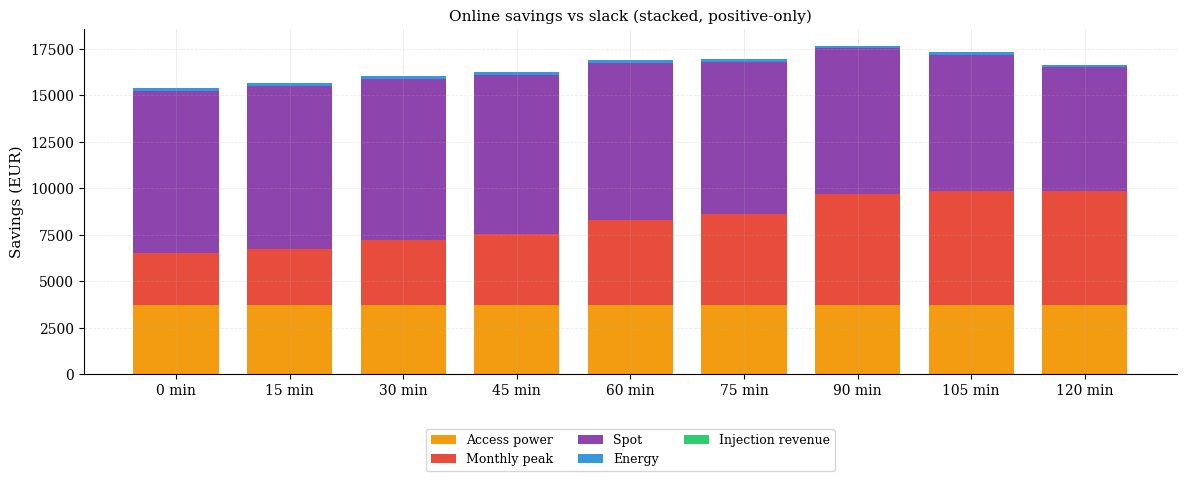

In [11]:
import numpy as np
import pandas as pd

from billing import load_billing_config, calculate_monthly_bills, calculate_monthly_injection_bills

# ---------- Paths / configs ----------
billing_cfg = load_billing_config(str(PROJECT_ROOT / "config" / "billing.yaml"))

# plant1.csv (2025, Brussels local)
plant = pd.read_csv(PROJECT_ROOT / "data" / "plant1.csv")
ts_utc = pd.to_datetime(plant["timestamp"], utc=True, errors="coerce")
plant["timestamp"] = ts_utc.dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
plant = plant.sort_values("timestamp").reset_index(drop=True)
plant = plant[(plant["timestamp"] >= pd.Timestamp("2025-01-01")) & (plant["timestamp"] < pd.Timestamp("2026-01-01"))].copy()

# combined slack results
if "_all" not in globals():
    combined_path = PROJECT_ROOT / "output" / "notebooks" / "online_ev_15min_notebook_09_slack_sensitivity.csv"
    _all = pd.read_csv(combined_path)

_all["timestamp"] = pd.to_datetime(_all["timestamp"], errors="coerce")
_all = _all.dropna(subset=["timestamp"]).sort_values(["slack_min", "timestamp"])

if "ev_online_mpc" not in _all.columns:
    raise KeyError("Combined slack CSV must contain 'ev_online_mpc'.")
if "access_kw" not in _all.columns:
    raise KeyError("Combined slack CSV must contain 'access_kw'.")

# §1.2 conservative access for baseline billing (not notebook 02 export)
if "ACCESS_POWER_BASELINE_MONTHLY" in globals():
    _baseline_ap = ACCESS_POWER_BASELINE_MONTHLY.copy()
elif "access_power_conservative_kw" in globals():
    _baseline_ap = access_power_conservative_kw.copy()
elif "table" in globals() and "access_power_conservative" in table.index:
    _baseline_ap = table.loc["access_power_conservative"]
else:
    raise NameError("Run §1.2 first to build ACCESS_POWER_BASELINE_MONTHLY or `table`.")
_baseline_ap.index = _baseline_ap.index.astype(str)
baseline_access_by_month = _baseline_ap.astype(float).to_dict()

# ---------- Helper: bill from net_kwh with an access_kw column ----------
def bill_from_net(df_ts_price_access: pd.DataFrame, net_kwh: pd.Series):
    df = df_ts_price_access.copy()
    net = pd.to_numeric(net_kwh, errors="coerce").fillna(0.0)

    df["grid_consumption"] = net.clip(lower=0.0)
    df["grid_injection"] = (-net).clip(lower=0.0)

    bills = calculate_monthly_bills(
        df, billing_cfg,
        volume_col="grid_consumption",
        price_col="price",
        timestamp_col="timestamp",
        access_power_col="access_kw",
    )
    inj = calculate_monthly_injection_bills(
        df, billing_cfg,
        injection_col="grid_injection",
        price_col="price",
        timestamp_col="timestamp",
    )

    # Make injection comparable to the Part 4 table: show it as a (negative) cost component
    inj_component_eur = -float(inj["injection_net_revenue_eur"].sum())

    out = {
        "energy_cost_eur": float(bills["energy_cost_eur"].sum()),
        "spot_cost_eur": float(bills["spot_cost_eur"].sum()),
        "access_cost_eur": float(bills["access_cost_eur"].sum()),
        "monthly_peak_cost_eur": float(bills["monthly_peak_cost_eur"].sum()),
        "over_usage_cost_eur": float(bills["over_usage_cost_eur"].sum()),
        "injection_component_eur": inj_component_eur,
    }
    out["total_cost_eur"] = float(bills["total_cost_eur"].sum()) + inj_component_eur
    return out

# ---------- Build baseline dataframe (uses BASELINE access power) ----------
base_df = plant[["timestamp", "inflex_load", "ev", "pv_production", "price"]].copy()
base_df["month"] = base_df["timestamp"].dt.to_period("M")
base_df["access_kw"] = base_df["month"].astype(str).map(baseline_access_by_month).astype(float)

if base_df["access_kw"].isna().any():
    missing_months = sorted(base_df.loc[base_df["access_kw"].isna(), "month"].astype(str).unique().tolist())
    raise KeyError(f"Missing baseline_access_power_kw for months: {missing_months}")

baseline_net = (
    pd.to_numeric(base_df["inflex_load"], errors="coerce").fillna(0.0)
    + pd.to_numeric(base_df["ev"], errors="coerce").fillna(0.0)
    - pd.to_numeric(base_df["pv_production"], errors="coerce").fillna(0.0)
)
base_tot = bill_from_net(base_df[["timestamp", "price", "access_kw"]], baseline_net)

# ---------- Online per slack (uses ONLINE access_kw from combined export) ----------
rows = []
slacks = sorted(pd.to_numeric(_all["slack_min"], errors="coerce").dropna().unique().astype(int))

for slack in slacks:
    sel = _all[pd.to_numeric(_all["slack_min"], errors="coerce").astype(int) == int(slack)][
        ["timestamp", "ev_online_mpc", "access_kw"]
    ].drop_duplicates("timestamp").sort_values("timestamp")

    m = plant[["timestamp", "inflex_load", "pv_production", "price"]].merge(sel, on="timestamp", how="inner")

    online_net = (
        pd.to_numeric(m["inflex_load"], errors="coerce").fillna(0.0)
        + pd.to_numeric(m["ev_online_mpc"], errors="coerce").fillna(0.0)
        - pd.to_numeric(m["pv_production"], errors="coerce").fillna(0.0)
    )
    on_tot = bill_from_net(m[["timestamp", "price", "access_kw"]], online_net)

    # Savings = baseline - online (positive means online is cheaper)
    rows.append({
        "slack_min": int(slack),
        "access_cost_savings_online_eur": base_tot["access_cost_eur"] - on_tot["access_cost_eur"],
        "monthly_peak_cost_savings_online_eur": base_tot["monthly_peak_cost_eur"] - on_tot["monthly_peak_cost_eur"],
        "spot_cost_savings_online_eur": base_tot["spot_cost_eur"] - on_tot["spot_cost_eur"],
        "energy_cost_savings_online_eur": base_tot["energy_cost_eur"] - on_tot["energy_cost_eur"],
        "injection_revenue_savings_online_eur": base_tot["injection_component_eur"] - on_tot["injection_component_eur"],
        "total_savings_online_eur": base_tot["total_cost_eur"] - on_tot["total_cost_eur"],
    })

sens = pd.DataFrame(rows).sort_values("slack_min").reset_index(drop=True)
display(sens)

# Stacked bars with SPACE between bars (categorical x-axis)

import numpy as np
import matplotlib.pyplot as plt

_plot = sens.copy()
_plot["slack_min"] = _plot["slack_min"].astype(int)
_plot = _plot.sort_values("slack_min").reset_index(drop=True)

labels = [f"{m} min" for m in _plot["slack_min"].tolist()]
x = np.arange(len(labels))

components = [
    ("Access power", _plot["access_cost_savings_online_eur"].to_numpy(float), "#f39c12"),
    ("Monthly peak", _plot["monthly_peak_cost_savings_online_eur"].to_numpy(float), "#e74c3c"),
    ("Spot", _plot["spot_cost_savings_online_eur"].to_numpy(float), "#8e44ad"),
    ("Energy", _plot["energy_cost_savings_online_eur"].to_numpy(float), "#3498db"),
    ("Injection revenue", _plot["injection_revenue_savings_online_eur"].to_numpy(float), "#2ecc71"),
]

# Positive-only stacks (savings shown as positive blocks)
stack = [(name, np.clip(np.nan_to_num(v, nan=0.0), 0.0, None), color) for name, v, color in components]

bottom = np.zeros(len(x), dtype=float)

fig, ax = plt.subplots(figsize=(12, 5))

BAR_WIDTH = 0.75  # < 1.0 => whitespace between bars
for name, v, color in stack:
    ax.bar(
        x,
        v,
        bottom=bottom,
        width=BAR_WIDTH,
        color=color,
        linewidth=0.0,
        label=name,
        align="center",
    )
    bottom += v

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("Online savings vs slack (stacked, positive-only)")
ax.set_ylabel("Savings (EUR)")
ax.grid(True, axis="y", linestyle="--", alpha=0.25)
ax.legend(ncol=3, fontsize=9, loc="upper center", bbox_to_anchor=(0.5, -0.14))

plt.tight_layout()
plt.show()

## Part 5 — Planner-only online MPC (thesis §3.7.2 steps 0, 1, 2, 6)

This section runs the **financial optimiser loop only** (no EMS actuator layer):

| Step | Thesis | Implemented |
|------|--------|-------------|
| 0 | Access-power selection | §1.2 **flex-aware** `ACCESS_POWER_ONLINE_MONTHLY` (same as Part 2) |
| 1 | State & forecast update | Blended daily EV demand, envelopes, peak / rolling-12 state |
| 2 | 24 h `mpc_ev_24h` | `ev_deadline_slack_minutes=0` |
| 3+6 | Evaluate & apply first step | `ev_applied = ev_plan[0]` with **actual** inflex & PV |
| 4–5 | Clip, catch-up, enforce | **Disabled** |

**Prerequisites:** §1.2 `table`, notebook 02 monthly export, forecasts 05–07.

**Runtime:** one full-year MPC loop (~similar order of magnitude as Part 2, without catch-up / enforce overhead).


In [13]:
# Part 5.2 — Run planner-only simulation (thesis steps 0, 1, 2, 6)

import importlib
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

# --- Adjustable settings (defaults match Part 2 config) ---
EV_FORECAST_STRATEGY = "c_p90"        # uses column like forecast_ev_a
INFLEX_FORECAST_STRATEGY = "c"        # uses column like forecast_inflex_a
PV_FORECAST_STRATEGY = "chronos2_elia_p50"  # "actual", "k1".."k10"
MARGIN_KW = 20.0                      # §1.2 grid-based margin

# Monthly flex-aware access (§1.2); reuse from §1.2 / Part 2 if already in kernel
if "ACCESS_POWER_ONLINE_MONTHLY" not in globals():
    det_path = PROJECT_ROOT / "output" / "notebooks" / "deterministic_ev_monthly_notebook_02.csv"
    if not det_path.exists():
        raise FileNotFoundError(f"Run notebook 02 export first: {det_path}")
    det_monthly = pd.read_csv(det_path)
    if "month" in det_monthly.columns:
        det_monthly["month"] = pd.PeriodIndex(det_monthly["month"], freq="M")
    _det_ap_col = (
        "optimized_access_power_kw"
        if "optimized_access_power_kw" in det_monthly.columns
        else "optimized_access_kw"
    )
    months = det_monthly.set_index("month")[_det_ap_col].sort_index().index

    train_2024 = pd.read_csv(PROJECT_ROOT / "data" / "plant1_2024_training.csv")
    train_2024["month"] = pd.PeriodIndex(
        train_2024["timestamp"].astype(str).str.slice(0, 7), freq="M"
    )
    monthly_peak_2024_excl_ev_kw = (
        train_2024.groupby("month")["grid_consumption_excl_ev"].max() * 4.0
    )
    baseline_2024_peak_excl_ev_kw = float(monthly_peak_2024_excl_ev_kw.max())

    plant_ap = pd.read_csv(PROJECT_ROOT / "data" / "plant1.csv")
    plant_ap["timestamp"] = pd.to_datetime(plant_ap["timestamp"], utc=True, errors="coerce")
    plant_ap["timestamp"] = (
        plant_ap["timestamp"].dt.tz_convert("Europe/Brussels").dt.tz_localize(None)
    )
    tmp_2025 = plant_ap.loc[
        plant_ap["timestamp"].dt.year == 2025,
        ["timestamp", "grid_consumption_excl_ev"],
    ].copy()
    tmp_2025["month"] = tmp_2025["timestamp"].dt.to_period("M")
    monthly_peak_2025_excl_ev_kw = (
        tmp_2025.groupby("month")["grid_consumption_excl_ev"].max() * 4.0
    ).reindex(months).astype(float)

    cummax_excl_ev_Mm1_kw = monthly_peak_2025_excl_ev_kw.cummax().shift(1)
    cummax_excl_ev_Mm1_kw.loc[months.min()] = baseline_2024_peak_excl_ev_kw
    cummax_excl_ev_Mm1_kw = cummax_excl_ev_Mm1_kw.fillna(baseline_2024_peak_excl_ev_kw)
    access_power_flex_aware_kw = cummax_excl_ev_Mm1_kw + MARGIN_KW

    ACCESS_POWER_ONLINE_MONTHLY = access_power_flex_aware_kw.copy()
    ACCESS_POWER_ONLINE_MONTHLY.index = ACCESS_POWER_ONLINE_MONTHLY.index.astype(str)
    print("Built ACCESS_POWER_ONLINE_MONTHLY from §1.2 flex-aware rule (standalone).")

import online_MPC_1_EV as ev_online_mod
importlib.reload(ev_online_mod)
from online_MPC_1_EV import run_ev_online_mpc_planner_only

_access = {
    str(k): float(v)
    for k, v in ACCESS_POWER_ONLINE_MONTHLY.items()
}

results_ev_planner_only, summary_ev_planner_only = run_ev_online_mpc_planner_only(
    forecast_strategy_ev=EV_FORECAST_STRATEGY,
    forecast_strategy_inflex=INFLEX_FORECAST_STRATEGY,
    forecast_strategy_pv=PV_FORECAST_STRATEGY,
    access_power_by_month=_access,
    verbose=True,
    log_prefix="[Part 5 planner-only]",
)

out_csv = PROJECT_ROOT / "output" / "notebooks" / "online_ev_15min_notebook_09_planner_only.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
results_ev_planner_only.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")
print("actuator_mode:", summary_ev_planner_only.get("actuator_mode"))
print("thesis_steps:", summary_ev_planner_only.get("thesis_steps"))


EV-only Online MPC 1 – Planner-only (thesis steps 0,1,2,6)
  EV forecast strategy:        c_p90
  Inflex forecast strategy:    c
  PV forecast strategy:        chronos2_elia_p50
  EV deadline slack (min): 0
  Enforce daily EV demand: False
  Plant data:             C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\data\plant1.csv
  EV forecast:            C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_ev_rolling_horizon.csv
  Inflex forecast:        C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_inflex_load_rolling_horizon.csv
  PV forecast:            C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\output\forecast\forecast_pv_rolling_horizon.csv
  Billing config:         C:\Users\VanAmmeT\Documents\Masterproef\Master-Thesis-MPC-Soudal\config\billing.yaml
--------------------------------------------------------------------------------
[Part 5 planner-only] Simulating da

In [14]:
# Part 5.3–5.4 — Shadow billing and comparison table (baseline vs offline vs planner-only online)

import pandas as pd
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

if "table" not in globals():
    raise NameError("Run §1.2 first to build `table`.")

det_monthly_path = PROJECT_ROOT / "output" / "notebooks" / "deterministic_ev_monthly_notebook_02.csv"
if not det_monthly_path.exists():
    raise FileNotFoundError(f"Run notebook 02 export first: {det_monthly_path}")
DET_EV_MONTHLY_P5 = pd.read_csv(det_monthly_path)
if "month" in DET_EV_MONTHLY_P5.columns:
    DET_EV_MONTHLY_P5["month"] = pd.PeriodIndex(DET_EV_MONTHLY_P5["month"], freq="M")

if "summary_ev_planner_only" not in globals():
    raise NameError("Run Part 5.2 first.")

online_bills_p5 = summary_ev_planner_only["bills"].copy()
online_inj_p5 = summary_ev_planner_only["injection_bills"].copy()
online_bills_p5["month_key"] = online_bills_p5["month"].astype(str)
online_inj_p5["month_key"] = online_inj_p5["month"].astype(str)

online_net_p5 = online_bills_p5[["month_key", "total_cost_eur"]].merge(
    online_inj_p5[["month_key", "injection_net_revenue_eur"]],
    on="month_key",
    how="left",
)
online_net_p5["online_planner_net_cost_eur"] = (
    online_net_p5["total_cost_eur"]
    - online_net_p5["injection_net_revenue_eur"].fillna(0.0)
)

monthly_det_p5 = DET_EV_MONTHLY_P5.copy()
monthly_det_p5["month_key"] = monthly_det_p5["month"].astype(str)

shadow_billing_09_part5 = pd.DataFrame({"month_key": monthly_det_p5["month_key"]}).set_index("month_key")
shadow_billing_09_part5["baseline_net_cost_eur"] = monthly_det_p5["baseline_net_cost_eur"].values
shadow_billing_09_part5["deterministic_net_cost_eur"] = monthly_det_p5["optimized_net_cost_eur"].values
shadow_billing_09_part5["baseline_peak_kw"] = monthly_det_p5["baseline_monthly_peak_kw"].values
shadow_billing_09_part5["deterministic_peak_kw"] = monthly_det_p5["optimized_monthly_peak_kw"].values
shadow_billing_09_part5["online_planner_net_cost_eur"] = online_net_p5.set_index("month_key").reindex(
    shadow_billing_09_part5.index
)["online_planner_net_cost_eur"].values
shadow_billing_09_part5["online_planner_peak_kw"] = (
    online_bills_p5.set_index("month_key")["monthly_peak_kw"].reindex(shadow_billing_09_part5.index).values
)
shadow_billing_09_part5["deterministic_savings_eur"] = (
    shadow_billing_09_part5["baseline_net_cost_eur"] - shadow_billing_09_part5["deterministic_net_cost_eur"]
)
shadow_billing_09_part5["online_planner_savings_eur"] = (
    shadow_billing_09_part5["baseline_net_cost_eur"] - shadow_billing_09_part5["online_planner_net_cost_eur"]
)
_offline_sav = float(shadow_billing_09_part5["deterministic_savings_eur"].sum())
_online_sav = float(shadow_billing_09_part5["online_planner_savings_eur"].sum())
shadow_billing_09_part5["capture_factor"] = (
    _online_sav / _offline_sav if abs(_offline_sav) > 1e-6 else float("nan")
)

shadow_billing_09_part5 = shadow_billing_09_part5.reset_index().rename(columns={"month_key": "month"})

print("Shadow billing — monthly (planner-only online)")
display(
    shadow_billing_09_part5[
        [
            "month",
            "baseline_net_cost_eur",
            "deterministic_net_cost_eur",
            "online_planner_net_cost_eur",
            "deterministic_savings_eur",
            "online_planner_savings_eur",
        ]
    ]
)

# Component-wise cost comparison (same layout as Part 3.2 / Part 4.3)
baseline_total_p5 = float(monthly_det_p5["baseline_net_cost_eur"].sum())
det_total_p5 = float(monthly_det_p5["optimized_net_cost_eur"].sum())
online_total_p5 = float(online_net_p5["online_planner_net_cost_eur"].sum())

baseline_energy_p5 = float(monthly_det_p5["baseline_energy_cost_eur"].sum())
det_energy_p5 = float(monthly_det_p5["optimized_energy_cost_eur"].sum())
online_energy_p5 = float(online_bills_p5["energy_cost_eur"].sum())

baseline_spot_p5 = float(monthly_det_p5["baseline_spot_cost_eur"].sum())
det_spot_p5 = float(monthly_det_p5["optimized_spot_cost_eur"].sum())
online_spot_p5 = float(online_bills_p5["spot_cost_eur"].sum())

baseline_access_p5 = float(monthly_det_p5["baseline_access_cost_eur"].sum())
det_access_p5 = float(monthly_det_p5["optimized_access_cost_eur"].sum())
online_access_p5 = float(online_bills_p5["access_cost_eur"].sum())

baseline_injection_p5 = float(monthly_det_p5["baseline_injection_net_revenue_eur"].sum())
det_injection_p5 = float(monthly_det_p5["optimized_injection_net_revenue_eur"].sum())
online_injection_p5 = float(online_inj_p5["injection_net_revenue_eur"].sum())

print("=" * 80)
print("COST COMPARISON (planner-only online): BASELINE vs DETERMINISTIC vs ONLINE")
print("=" * 80)
print(
    f"\n{'Cost Component':<30} "
    f"{'Baseline (EUR)':>20} {'Deterministic (EUR)':>20} {'Online (EUR)':>20} "
    f"{'Savings det (EUR)':>20} {'Savings online (EUR)':>22}"
)
print("-" * 122)

components_p5 = [
    ("Energy Cost", baseline_energy_p5, det_energy_p5, online_energy_p5),
    ("Spot Cost", baseline_spot_p5, det_spot_p5, online_spot_p5),
    ("Access Power Cost", baseline_access_p5, det_access_p5, online_access_p5),
    (
        "Monthly Peak Cost",
        float(monthly_det_p5["baseline_monthly_peak_cost_eur"].sum()),
        float(monthly_det_p5["optimized_monthly_peak_cost_eur"].sum()),
        float(online_bills_p5["monthly_peak_cost_eur"].sum()),
    ),
    (
        "Over-usage Cost",
        float(monthly_det_p5["baseline_over_usage_cost_eur"].sum()),
        float(monthly_det_p5["optimized_over_usage_cost_eur"].sum()),
        float(online_bills_p5["over_usage_cost_eur"].sum()),
    ),
    (
        "Injection Revenue",
        -baseline_injection_p5,
        -det_injection_p5,
        -online_injection_p5,
    ),
]

for name, base_val, det_val, online_val in components_p5:
    print(
        f"{name:<30} "
        f"{base_val:>20,.2f} {det_val:>20,.2f} {online_val:>20,.2f} "
        f"{(base_val - det_val):>20,.2f} {(base_val - online_val):>22,.2f}"
    )

print("-" * 122)
print(
    f"{'TOTAL COST':<30} "
    f"{baseline_total_p5:>20,.2f} {det_total_p5:>20,.2f} {online_total_p5:>20,.2f} "
    f"{baseline_total_p5 - det_total_p5:>20,.2f} "
    f"{baseline_total_p5 - online_total_p5:>22,.2f}"
)
print("=" * 80)

savings_det_pct_p5 = (baseline_total_p5 - det_total_p5) / baseline_total_p5 * 100
savings_online_pct_p5 = (baseline_total_p5 - online_total_p5) / baseline_total_p5 * 100
print(
    f"\nTotal Savings vs Baseline — Deterministic: "
    f"{baseline_total_p5 - det_total_p5:,.2f} EUR ({savings_det_pct_p5:.2f}%)"
)
print(
    f"Total Savings vs Baseline — Online (planner-only): "
    f"{baseline_total_p5 - online_total_p5:,.2f} EUR ({savings_online_pct_p5:.2f}%)"
)

_b0 = baseline_total_p5
_boff = det_total_p5
_bon = online_total_p5
print("\n" + "=" * 72)
print("ANNUAL TOTALS (EUR, net of injection)")
print(f"  Baseline:              {_b0:,.2f}")
print(f"  Offline (deterministic): {_boff:,.2f}  |  savings vs baseline: {_b0 - _boff:,.2f}")
print(f"  Online (planner-only):   {_bon:,.2f}  |  savings vs baseline: {_b0 - _bon:,.2f}")
if abs(_b0 - _boff) > 1e-6:
    print(f"  Capture factor (online/offline savings): {(_b0 - _bon) / (_b0 - _boff):.1%}")
print("=" * 72)


Shadow billing — monthly (planner-only online)


,month,baseline_net_cost_eur,deterministic_net_cost_eur,online_planner_net_cost_eur,deterministic_savings_eur,online_planner_savings_eur
0,2025-01,198817.187903,197725.324273,199282.917245,1091.863630,-465.729342
1,2025-02,193918.029264,192168.580655,194760.586916,1749.448609,-842.557652
2,2025-03,157138.204053,155781.722065,156931.001726,1356.481988,207.202327
3,2025-04,124865.912955,122842.725813,124682.455615,2023.187141,183.457339
4,2025-05,106408.259216,104213.251512,105340.792436,2195.007704,1067.466780
5,2025-06,107792.127867,106159.082762,107295.755542,1633.045105,496.372325
6,2025-07,125413.017235,123773.838346,125714.721265,1639.178889,-301.704030
7,2025-08,111094.823299,109732.921507,110868.387594,1361.901792,226.435706
8,2025-09,117868.857153,115651.953607,117549.980237,2216.903546,318.876916
9,2025-10,149981.914462,147307.554615,149685.477455,2674.359847,296.437007


COST COMPARISON (planner-only online): BASELINE vs DETERMINISTIC vs ONLINE

Cost Component                       Baseline (EUR)  Deterministic (EUR)         Online (EUR)    Savings det (EUR)   Savings online (EUR)
--------------------------------------------------------------------------------------------------------------------------
Energy Cost                              375,450.30           375,295.02           375,281.17               155.28                 169.13
Spot Cost                              1,075,304.89         1,066,502.39         1,066,534.53             8,802.50               8,770.35
Access Power Cost                         99,044.91            94,584.56            95,342.94             4,460.35               3,701.97
Monthly Peak Cost                        130,160.36           123,433.87           131,205.70             6,726.49              -1,045.33
Over-usage Cost                            1,800.78                 0.00            12,485.15             1,800

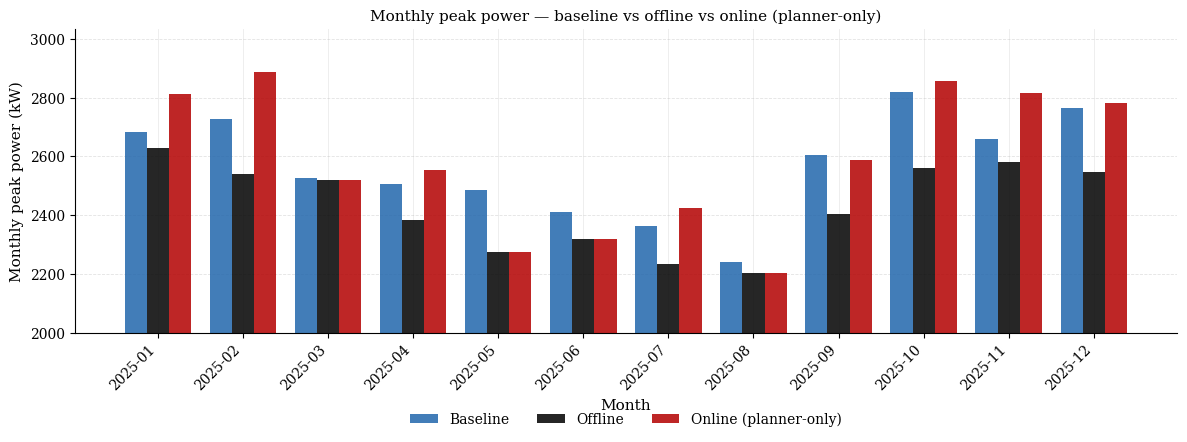

<Axes: title={'center': 'Monthly peak power — baseline vs offline vs online (planner-only)'}, xlabel='Month', ylabel='Monthly peak power (kW)'>

In [20]:
# Part 5.5 — Thesis-style monthly peak plot (planner-only online)

import importlib
import sys
from pathlib import Path

SRC_DIR = Path("..").resolve() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import notebook_visualisation.nb09_ev_part34_viewer as _nb09_ev_viewer
importlib.reload(_nb09_ev_viewer)
from notebook_visualisation.nb09_ev_part34_viewer import plot_thesis_monthly_peaks_ev

if "shadow_billing_09_part5" not in globals():
    raise NameError("Run Part 5.3–5.4 first.")

plot_thesis_monthly_peaks_ev(shadow_billing_09_part5, ylim_bottom=2000.0)
